# ✈️ NASA C-MAPSS FD002 — EDA + 전처리 + Feature Engineering + Validation Split 파이프라인

**[FD002 최적화]** 상수 센서 제거(전체 기준) → 운전 조건 클러스터링(KMeans k=6) → 클러스터별 정규화 / 클러스터 내 파생변수 생성

공통: 상수 센서 제거(전체 기준) → 운전 조건 클러스터링 → RUL cap → 클러스터별 Gaussian → Validation 분리(엔진 단위 random) → 클러스터별 정규화 + OHE  
ML 분기: lag·diff·rolling·std·EMA (엔진×클러스터 단위)  |  DL 분기: 슬라이딩 윈도우

> **FD002 vs FD001 핵심 차이**  
> - 운전 조건: 1가지 → **6가지**  
> - 훈련 엔진: 100대 → **260대**  
> - 정규화 전략: 전체 MinMax → **클러스터별 MinMax**  
> - 검증 분리: 단순 랜덤 (엔진 단위 8:2)  
> - 파생변수: 엔진 단위 → **엔진×클러스터 단위**  
> - 추가 검정: Kruskal-Wallis, Chi-square 클러스터 동질성 검정


## 0. 환경 설정

In [ ]:
# ── 라이브러리 체크 (이미 있으면 설치 스킵) ──
import importlib, subprocess, sys
_NEEDED = ['numpy','pandas','scikit-learn','scipy','matplotlib','seaborn','statsmodels']
_missing = []
for pkg in _NEEDED:
    mod = pkg.replace('-', '_')
    try:
        importlib.import_module('sklearn' if pkg == 'scikit-learn' else mod)
    except ImportError:
        _missing.append(pkg)
if _missing:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *_missing])
print(f'✅ 라이브러리 준비 완료 (설치: {_missing or "없음"})')


In [ ]:
import os, warnings, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
import platform
from scipy import stats
from scipy.ndimage import gaussian_filter1d
from scipy.stats import (ks_2samp, kendalltau, ttest_rel, shapiro,
                          wilcoxon, kruskal, chi2_contingency)
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')

# ── 한글 폰트 ─────────────────────────────────────────────────────────────
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# ── 다크 테마 ─────────────────────────────────────────────────────────────
BG, BG2, GRID = '#0f1117', '#1a1d2e', '#2d3148'
WHITE, GRAY   = '#ffffff', '#aaaaaa'
C = ['#00d4ff','#ff6b6b','#51cf66','#ffd43b','#a29bfe','#fd79a8','#00b894','#e17055']

plt.rcParams.update({
    'figure.facecolor': BG,  'axes.facecolor': BG2,
    'axes.edgecolor':  GRID, 'axes.labelcolor': GRAY,
    'xtick.color': GRAY,     'ytick.color': GRAY,
    'text.color': WHITE,     'grid.color': GRID,
    'grid.alpha': 0.4,       'axes.grid': True,
    'font.size': 10,         'axes.titlesize': 11,
    'legend.facecolor': BG2, 'legend.edgecolor': GRID,
})

# ── 전역 상수 ─────────────────────────────────────────────────────────────
RAW_COLS = ['unit','cycle','op1','op2','op3'] + [f's{i}' for i in range(1, 22)]

RENAME_MAP = {
    'unit': 'unit_nr', 'cycle': 'time_cycles',
    'op1': 'setting_1', 'op2': 'setting_2', 'op3': 'setting_3',
    **{f's{i}': f's_{i}' for i in range(1, 22)}
}

SENSOR_COLS  = [f's_{i}' for i in range(1, 22)]
OP_COLS      = ['setting_1', 'setting_2', 'setting_3']
ID_COLS      = ['unit_nr', 'time_cycles']
RUL_CAP      = 125       # 수명 분포 확인 후 섹션 4에서 조정
GAUSS_SIGMA  = 2
CONST_THR    = 0.01
N_CLUSTERS   = 6         # FD002 운전 조건 수

TEMPORAL_LAGS      = [1, 3, 5]
TEMPORAL_DIFFS     = [1]
TEMPORAL_ROLLS     = [3, 5]
TEMPORAL_ROLL_STDS = [3, 5]
TEMPORAL_EMAS      = [5]

WINDOW_SIZE = 30
STEP        = 1

SENSOR_DESC = {
    's_1': 'T2 팬 입구 온도(°R)',       's_2': 'T24 LPC 출구 온도(°R)',
    's_3': 'T30 HPC 출구 온도(°R)',     's_4': 'T50 LPT 출구 온도(°R)',
    's_5': 'P2 팬 입구 압력(psia)',      's_6': 'P15 바이패스 압력(psia)',
    's_7': 'P30 HPC 출구 압력(psia)',   's_8': 'Nf 팬 속도(rpm)',
    's_9': 'Nc 코어 속도(rpm)',          's_10': 'epr 엔진 압력비',
    's_11': 'Ps30 정적압력(psia)',       's_12': 'phi 연료/Ps30 비율',
    's_13': 'NRf 보정 팬 속도(rpm)',     's_14': 'NRc 보정 코어속도(rpm)',
    's_15': 'BPR 바이패스 비율',         's_16': 'farB 버너 연료공기비',
    's_17': 'htBleed 블리드 엔탈피',     's_18': 'Nf_dmd 요구 팬 속도',
    's_19': 'PCNfR 요구 보정 팬속도',    's_20': 'W31 HPT 냉각블리드',
    's_21': 'W32 LPT 냉각블리드',
}

CLUSTER_COLORS = ['#00d4ff','#ff6b6b','#51cf66','#ffd43b','#a29bfe','#fd79a8']

print('✅ 환경 설정 완료')
print(f'   RUL Cap={RUL_CAP}  |  σ={GAUSS_SIGMA}  |  상수 기준 std<{CONST_THR}  |  클러스터 수={N_CLUSTERS}')

## 1. 데이터 로딩 & 컬럼명 표준화

In [3]:
DATA_DIR = 'CMAPSSData'
for c in ['CMAPSSData', './CMAPSSData', '../CMAPSSData']:
    if os.path.exists(os.path.join(c, 'train_FD002.txt')):
        DATA_DIR = c; break
else:
    print(f'❌ 경로 없음. 현재: {os.getcwd()}')

kw = dict(sep=r'\s+', header=None, names=RAW_COLS, engine='python')
train_raw = pd.read_csv(f'{DATA_DIR}/train_FD002.txt', **kw)
test_raw  = pd.read_csv(f'{DATA_DIR}/test_FD002.txt',  **kw)
rul_df    = pd.read_csv(f'{DATA_DIR}/RUL_FD002.txt',
                        sep=r'\s+', header=None, names=['RUL'], engine='python')

train_raw.rename(columns=RENAME_MAP, inplace=True)
test_raw.rename( columns=RENAME_MAP, inplace=True)

print('✅ FD002 로딩 완료')
print(f'   Train : {train_raw.shape}  |  엔진 {train_raw["unit_nr"].nunique()}대')
print(f'   Test  : {test_raw.shape}   |  엔진 {test_raw["unit_nr"].nunique()}대')
print(f'   RUL   : {rul_df.shape}')
display(train_raw.head(3))

✅ FD002 로딩 완료
   Train : (53759, 26)  |  엔진 260대
   Test  : (33991, 26)   |  엔진 259대
   RUL   : (259, 1)


,unit_nr,time_cycles,setting_1,setting_2,setting_3,s_1,s_2,s_3,s_4,s_5,...,s_12,s_13,s_14,s_15,s_16,s_17,s_18,s_19,s_20,s_21
0,1,1,34.9983,0.8400,100.0,449.44,555.32,1358.61,1137.23,5.48,...,183.06,2387.72,8048.56,9.3461,0.02,334,2223,100.00,14.73,8.8071
1,1,2,41.9982,0.8408,100.0,445.00,549.90,1353.22,1125.78,3.91,...,130.42,2387.66,8072.30,9.3774,0.02,330,2212,100.00,10.41,6.2665
2,1,3,24.9988,0.6218,60.0,462.54,537.31,1256.76,1047.45,7.05,...,164.22,2028.03,7864.87,10.8941,0.02,309,1915,84.93,14.08,8.6723


---
## 2. 결정 1 — 상수 센서 제거 [전체 기준]

**전체 std 기준 단일 적용:** 어느 조건에서도 변동이 없는 센서만 제거.  
- 전체 std < 0.01 → 제거 대상
- 결과: 21개 → 20개 base 센서 (s_18 1개 제거 예상)


=== 결정 1 — 상수 센서 제거 (전체 기준) ===
기준 (전체 std<0.01): ['s_16']  (1개)
최종 제거:               ['s_16']  (1개)
최종 유지:               ['s_1', 's_2', 's_3', 's_4', 's_5', 's_6', 's_7', 's_8', 's_9', 's_10', 's_11', 's_12', 's_13', 's_14', 's_15', 's_17', 's_18', 's_19', 's_20', 's_21']  (20개)


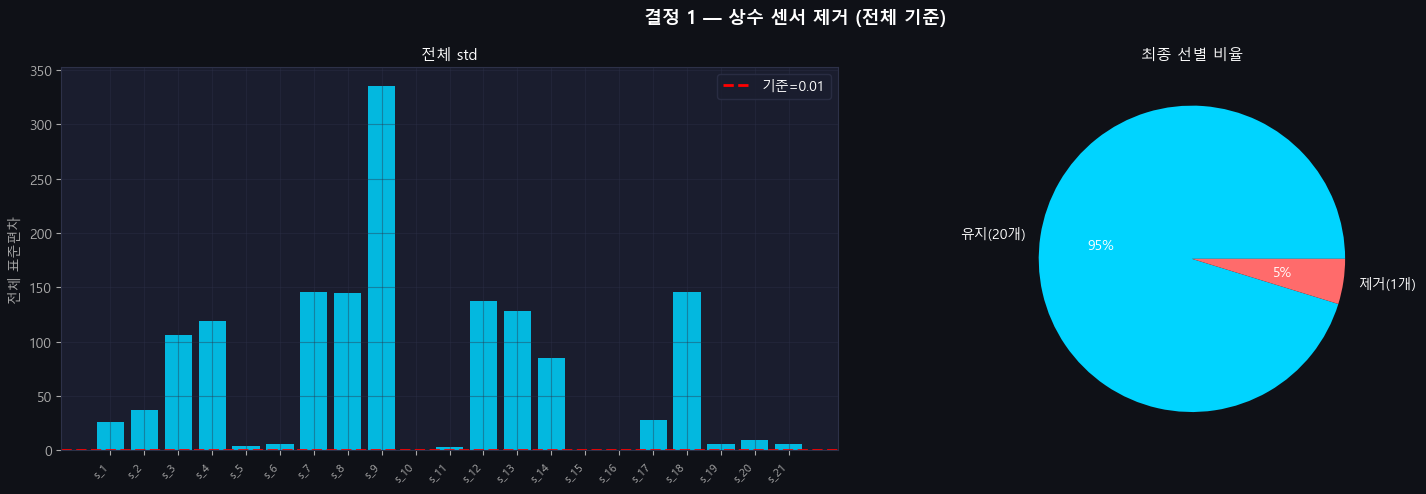


✅ 결정 1 완료: 26컬럼 → 유용 센서 20개 유지


In [4]:
# 기준: 전체 std (FD002 — 전체 기준만)
train_std    = train_raw[SENSOR_COLS].std()
const_global = train_std[train_std < CONST_THR].index.tolist()

# 최종 제거 = 전체 기준
REMOVE_SENSORS  = sorted(const_global, key=lambda x: int(x.split('_')[1]))
USEFUL_SENSORS  = sorted([s for s in SENSOR_COLS if s not in REMOVE_SENSORS],
                          key=lambda x: int(x.split('_')[1]))

print('=== 결정 1 — 상수 센서 제거 (전체 기준) ===')
print(f'기준 (전체 std<{CONST_THR}): {const_global}  ({len(const_global)}개)')
print(f'최종 제거:               {REMOVE_SENSORS}  ({len(REMOVE_SENSORS)}개)')
print(f'최종 유지:               {USEFUL_SENSORS}  ({len(USEFUL_SENSORS)}개)')

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('결정 1 — 상수 센서 제거 (전체 기준)', fontsize=13, fontweight='bold')

ax = axes[0]
colors = ['#ff6b6b' if s in const_global else '#00d4ff' for s in SENSOR_COLS]
ax.bar(range(len(SENSOR_COLS)), train_std.values, color=colors, alpha=0.85)
ax.axhline(CONST_THR, color='red', ls='--', lw=2, label=f'기준={CONST_THR}')
ax.set_xticks(range(len(SENSOR_COLS)))
ax.set_xticklabels(SENSOR_COLS, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('전체 표준편차'); ax.set_title('전체 std'); ax.legend()

ax = axes[1]
ax.pie([len(USEFUL_SENSORS), len(REMOVE_SENSORS)],
       labels=[f'유지({len(USEFUL_SENSORS)}개)', f'제거({len(REMOVE_SENSORS)}개)'],
       colors=[C[0], C[1]], autopct='%1.0f%%', textprops={'color': WHITE})
ax.set_title('최종 선별 비율')
plt.tight_layout(); plt.show()

# 클러스터링 전이므로 op_cluster 없이 KEEP 구성
KEEP = ID_COLS + OP_COLS + USEFUL_SENSORS
train_s1 = train_raw[KEEP].copy()
test_s1  = test_raw[KEEP].copy()
print(f'\n✅ 결정 1 완료: {train_raw.shape[1]}컬럼 → 유용 센서 {len(USEFUL_SENSORS)}개 유지')


## 3. [FD002 핵심] 운전 조건 클러스터링

> FD002는 6가지 운전 조건(Altitude, Mach, TRA 조합)이 섞여 있음.  
> setting_1/2/3 조합으로 KMeans 클러스터링하여 조건별 라벨을 부여한다.  
> **이 단계가 FD002 전처리의 핵심이며, 이후 정규화·스무딩·파생변수 모두 클러스터 단위로 수행된다.**


### 3-1. 최적 클러스터 수 탐색 (Elbow + Silhouette)


In [ ]:
# [수정] elbow/silhouette도 표준화 좌표에서 평가 (공정한 비교)
op_data = MinMaxScaler().fit_transform(train_s1[OP_COLS])

inertias, silhouettes = [], []
K_range = range(2, 12)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=20, max_iter=300)
    labels = km.fit_predict(op_data)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(op_data, labels))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('3-1. 최적 클러스터 수 탐색 (운전 조건 setting_1/2/3)', fontsize=13, fontweight='bold')

ax = axes[0]
ax.plot(list(K_range), inertias, color=C[0], lw=2.5, marker='o', markersize=7)
ax.axvline(N_CLUSTERS, color='red', ls='--', lw=2, label=f'선택: k={N_CLUSTERS}')
ax.set_xlabel('클러스터 수 k'); ax.set_ylabel('관성(Inertia)')
ax.set_title('Elbow Method'); ax.legend()

ax = axes[1]
ax.plot(list(K_range), silhouettes, color=C[2], lw=2.5, marker='s', markersize=7)
ax.axvline(N_CLUSTERS, color='red', ls='--', lw=2, label=f'선택: k={N_CLUSTERS}')
best_k = list(K_range)[np.argmax(silhouettes)]
ax.axvline(best_k, color='yellow', ls=':', lw=1.5, label=f'최고 실루엣: k={best_k}')
ax.set_xlabel('클러스터 수 k'); ax.set_ylabel('Silhouette Score')
ax.set_title('Silhouette Score'); ax.legend()

plt.tight_layout(); plt.show()

print(f'📌 선택된 k={N_CLUSTERS}  |  Silhouette={silhouettes[N_CLUSTERS-2]:.4f}')
print(f'   최고 실루엣 k={best_k}  |  score={max(silhouettes):.4f}')


### 3-2. KMeans 클러스터링 수행 & 조건 분포 확인


In [ ]:
# ── [수정] OP_COLS 표준화 후 클러스터링 (setting_1 altitude 스케일이 압도적이라 필수) ──
op_scaler = MinMaxScaler()  # MinMax (스케일 통일 목적)
op_train_z = op_scaler.fit_transform(train_s1[OP_COLS])
op_test_z  = op_scaler.transform(test_s1[OP_COLS])

kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=20, max_iter=300)
kmeans.fit(op_train_z)

train_s1['op_cluster'] = kmeans.labels_
test_s1['op_cluster']  = kmeans.predict(op_test_z)
# 표준화기도 함께 저장 (test 데이터 적용 시 필요)
import joblib as _joblib
_joblib.dump(op_scaler, 'FD002_op_scaler.pkl')
# EDA 호환을 위해 train_raw / test_raw 에도 동일하게 추가
train_raw['op_cluster'] = train_s1['op_cluster'].values
test_raw['op_cluster']  = test_s1['op_cluster'].values

# ── 클러스터별 운전 조건 평균 ─────────────────────────────────────────────
cluster_profile = train_raw.groupby('op_cluster')[OP_COLS + ['unit_nr']].agg(
    {'setting_1': 'mean', 'setting_2': 'mean', 'setting_3': 'mean', 'unit_nr': 'count'}
).rename(columns={'unit_nr': 'row_count'})
cluster_profile['비율(%)'] = (cluster_profile['row_count'] / len(train_raw) * 100).round(2)

print('=== 클러스터별 운전 조건 프로파일 ===')
display(cluster_profile.round(4))

# ── 시각화: 3D 클러스터 분포 ──────────────────────────────────────────────
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(18, 6))
fig.suptitle('3-2. 운전 조건 클러스터링 결과 (KMeans k=6)', fontsize=13, fontweight='bold')

# 3D scatter (샘플링)
ax3d = fig.add_subplot(131, projection='3d')
sample = train_raw.sample(min(3000, len(train_raw)), random_state=42)
for c in range(N_CLUSTERS):
    mask = sample['op_cluster'] == c
    ax3d.scatter(sample.loc[mask,'setting_1'], sample.loc[mask,'setting_2'],
                 sample.loc[mask,'setting_3'], c=CLUSTER_COLORS[c], s=10, alpha=0.6, label=f'C{c}')
ax3d.set_xlabel('setting_1'); ax3d.set_ylabel('setting_2'); ax3d.set_zlabel('setting_3')
ax3d.set_title('3D 클러스터 분포'); ax3d.legend(fontsize=7, loc='upper left')

# 클러스터별 비율
ax2 = fig.add_subplot(132)
counts = train_raw['op_cluster'].value_counts().sort_index()
bars = ax2.bar(counts.index, counts.values,
               color=[CLUSTER_COLORS[i] for i in counts.index], alpha=0.85)
ax2.set_xlabel('클러스터'); ax2.set_ylabel('샘플 수')
ax2.set_title('클러스터별 샘플 수')
for bar, v in zip(bars, counts.values):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+50,
             f'{v}\n({v/len(train_raw)*100:.1f}%)', ha='center', fontsize=8)

# setting_1 vs setting_2 산점도
ax3 = fig.add_subplot(133)
for c in range(N_CLUSTERS):
    mask = train_raw['op_cluster'] == c
    ax3.scatter(train_raw.loc[mask,'setting_1'], train_raw.loc[mask,'setting_2'],
                c=CLUSTER_COLORS[c], s=5, alpha=0.4, label=f'C{c}')
centers = kmeans.cluster_centers_
ax3.scatter(centers[:,0], centers[:,1], c='white', s=200, marker='*', zorder=5, label='중심')
ax3.set_xlabel('setting_1'); ax3.set_ylabel('setting_2')
ax3.set_title('setting_1 vs setting_2'); ax3.legend(fontsize=7)

plt.tight_layout(); plt.show()

### 3-3. 클러스터 일관성 검증 & Train/Test 비율 비교


=== 엔진별 운전 조건 다양성 ===
  엔진당 평균 조건 수: 6.00
  엔진당 최소 조건 수: 6
  엔진당 최대 조건 수: 6
  6가지 조건 모두 경험한 엔진: 260대


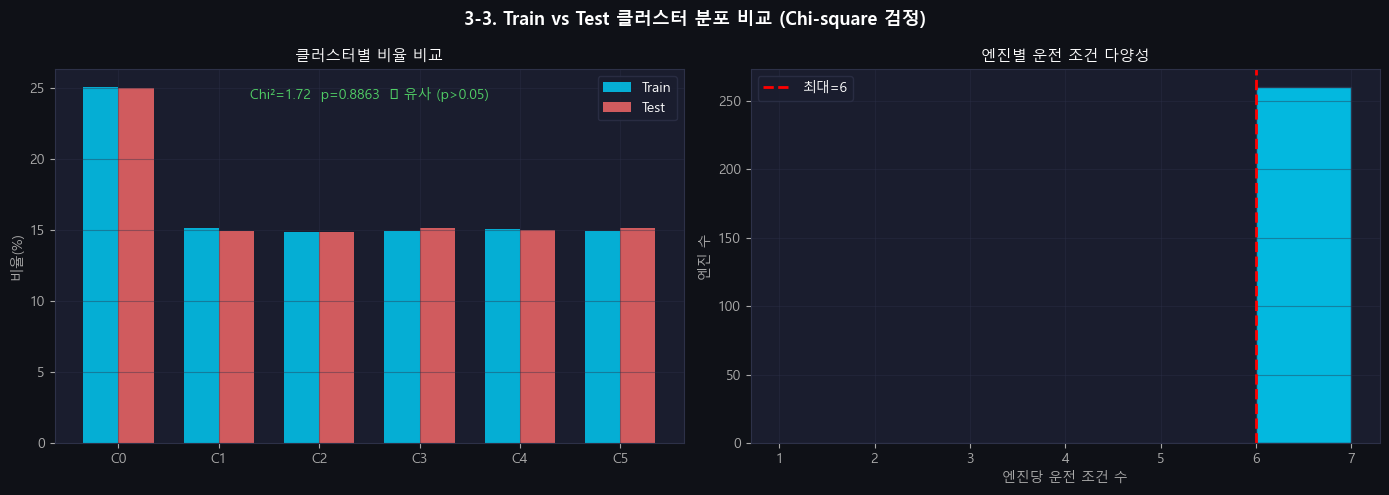


Chi-square 검정: χ²=1.720, p=0.8863
판정: ✅ 유사 (p>0.05)
📌 p>0.05: Train/Test 클러스터 비율 유사 → 정규화 누수 위험 낮음


In [7]:
# ── 엔진별 클러스터 다양성 확인 ─────────────────────────────────────────
cluster_per_unit = train_raw.groupby('unit_nr')['op_cluster'].nunique()

print('=== 엔진별 운전 조건 다양성 ===')
print(f'  엔진당 평균 조건 수: {cluster_per_unit.mean():.2f}')
print(f'  엔진당 최소 조건 수: {cluster_per_unit.min()}')
print(f'  엔진당 최대 조건 수: {cluster_per_unit.max()}')
print(f'  6가지 조건 모두 경험한 엔진: {(cluster_per_unit == N_CLUSTERS).sum()}대')

# ── Train vs Test 클러스터 비율 Chi-square 검정 ───────────────────────────
train_counts = train_raw['op_cluster'].value_counts().sort_index()
test_counts  = test_raw['op_cluster'].value_counts().sort_index()

contingency = np.array([train_counts.values, test_counts.values])
chi2_stat, chi2_p, dof, expected = chi2_contingency(contingency)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('3-3. Train vs Test 클러스터 분포 비교 (Chi-square 검정)', fontsize=13, fontweight='bold')

x = np.arange(N_CLUSTERS); width = 0.35
train_pct = train_counts.values / train_counts.sum() * 100
test_pct  = test_counts.values  / test_counts.sum()  * 100

axes[0].bar(x - width/2, train_pct, width, color=C[0], alpha=0.8, label='Train')
axes[0].bar(x + width/2, test_pct,  width, color=C[1], alpha=0.8, label='Test')
axes[0].set_xticks(x); axes[0].set_xticklabels([f'C{i}' for i in range(N_CLUSTERS)])
axes[0].set_ylabel('비율(%)'); axes[0].set_title('클러스터별 비율 비교'); axes[0].legend()
verdict = '✅ 유사 (p>0.05)' if chi2_p > 0.05 else '⚠️ 차이 있음 (p≤0.05)'
axes[0].text(0.5, 0.92, f'Chi²={chi2_stat:.2f}  p={chi2_p:.4f}  {verdict}',
             transform=axes[0].transAxes, ha='center', fontsize=10,
             color=C[2] if chi2_p > 0.05 else C[1])

# 엔진당 클러스터 수 히스토그램
axes[1].hist(cluster_per_unit, bins=range(1, N_CLUSTERS+2), color=C[0], alpha=0.85, edgecolor=GRID)
axes[1].axvline(N_CLUSTERS, color='red', ls='--', lw=2, label=f'최대={N_CLUSTERS}')
axes[1].set_xlabel('엔진당 운전 조건 수'); axes[1].set_ylabel('엔진 수')
axes[1].set_title('엔진별 운전 조건 다양성'); axes[1].legend()

plt.tight_layout(); plt.show()

print(f'\nChi-square 검정: χ²={chi2_stat:.3f}, p={chi2_p:.4f}')
print(f'판정: {verdict}')
print('📌 p>0.05: Train/Test 클러스터 비율 유사 → 정규화 누수 위험 낮음')

### 4-EXTRA-A. 클러스터 전이 행렬 & 거주 시간 [추가 EDA]
- 엔진별로 어느 운전 모드에서 어느 모드로 자주 전환되는지 (6×6 행렬)
- 한 cluster에 연속 머무는 cycle 수 분포 → lag 의미 해석에 직결


In [ ]:
# 4-EXTRA-A. Cluster transition matrix + dwell time
print('=== 4-EXTRA-A. 클러스터 전이 / 거주 시간 ===')

trans = np.zeros((N_CLUSTERS, N_CLUSTERS), dtype=int)
dwell_times = []
for uid in train_raw['unit_nr'].unique():
    seq = train_raw[train_raw['unit_nr']==uid].sort_values('time_cycles')['op_cluster'].values
    # transition (자기→자기 포함)
    for a, b in zip(seq[:-1], seq[1:]):
        trans[a, b] += 1
    # dwell: run-length encoding
    rl = 1
    for k in range(1, len(seq)):
        if seq[k] == seq[k-1]:
            rl += 1
        else:
            dwell_times.append((seq[k-1], rl))
            rl = 1
    dwell_times.append((seq[-1], rl))

dwell_df = pd.DataFrame(dwell_times, columns=['cluster','cycles'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# 전이 행렬 (자기→자기 제외, 비율 정규화)
trans_off = trans.copy().astype(float)
np.fill_diagonal(trans_off, 0)
trans_norm = trans_off / np.maximum(trans_off.sum(axis=1, keepdims=True), 1)
sns.heatmap(trans_norm, ax=axes[0], cmap='YlOrRd', annot=True, fmt='.2f',
            xticklabels=[f'C{i}' for i in range(N_CLUSTERS)],
            yticklabels=[f'C{i}' for i in range(N_CLUSTERS)],
            linewidths=0.3, linecolor=GRID)
axes[0].set_title('전이 행렬 (자기→자기 제외, 행 정규화)')
axes[0].set_xlabel('to'); axes[0].set_ylabel('from')

# Dwell time boxplot per cluster
dwell_df.boxplot(column='cycles', by='cluster', ax=axes[1], grid=False,
                 patch_artist=True, showmeans=True)
axes[1].set_title('클러스터별 거주 시간(cycle)')
axes[1].set_xlabel('cluster'); axes[1].set_ylabel('연속 cycle 수')
plt.suptitle('')
plt.tight_layout(); plt.show()

print('\n클러스터별 평균 거주 시간:')
print(dwell_df.groupby('cluster')['cycles'].agg(['mean','median','max']).round(1))


### 4-EXTRA-B. 엔진별 cluster 프로파일 vs 수명 상관 [추가 EDA]
- 특정 cluster에 더 많이 머문 엔진이 더 빨리 죽는지?
- 엔진의 cluster 비중 (6개) ↔ 총 lifecycle Spearman 상관


In [ ]:
# 4-EXTRA-B. Engine cluster mix vs lifecycle
from scipy.stats import spearmanr
print('=== 4-EXTRA-B. 엔진별 cluster 비중 vs 수명 ===')

mc = train_raw.groupby('unit_nr')['time_cycles'].max().rename('lifecycle')
mix = (train_raw.groupby(['unit_nr','op_cluster']).size()
       .unstack(fill_value=0))
mix = mix.div(mix.sum(axis=1), axis=0)
mix.columns = [f'C{c}_pct' for c in mix.columns]
mix = mix.join(mc)

rows = []
for c in range(N_CLUSTERS):
    col = f'C{c}_pct'
    if col not in mix.columns: continue
    r, p = spearmanr(mix[col], mix['lifecycle'])
    rows.append({'cluster': f'C{c}', 'spearman_r': round(r,3),
                 'p-value': round(p,4),
                 '판정': '유의 ✅' if p<0.05 else '비유의 ⚠️'})
print(pd.DataFrame(rows).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
for c in range(N_CLUSTERS):
    col = f'C{c}_pct'
    if col not in mix.columns: continue
    ax.scatter(mix[col], mix['lifecycle'], color=CLUSTER_COLORS[c], alpha=0.6,
               s=30, label=f'C{c}')
ax.set_xlabel('해당 cluster 비중'); ax.set_ylabel('총 lifecycle')
ax.set_title('엔진의 cluster 비중 ↔ 수명')
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


### 4-EXTRA-C. Sensor trajectory by RUL bin × Cluster [추가 EDA]
- RUL 구간별(0-25/25-50/50-75/75-100/>100) 각 cluster에서 센서 평균
- cluster별로 어떤 센서가 RUL에 따라 단조 변화하는지 시각 확인


In [ ]:
# 4-EXTRA-C. Sensor trajectory by RUL bin × Cluster
print('=== 4-EXTRA-C. Sensor trajectory by RUL bin × Cluster ===')

mc = train_raw.groupby('unit_nr')['time_cycles'].max().rename('max_c')
trj = train_raw.join(mc, on='unit_nr')
trj['RUL'] = trj['max_c'] - trj['time_cycles']
trj['rul_bin'] = pd.cut(trj['RUL'], bins=[-1, 25, 50, 75, 100, 1e6],
                        labels=['0-25','25-50','50-75','75-100','>100'])

# 6개 대표 센서 — 클러스터별 평균
top6 = USEFUL_SENSORS[:6] if 'USEFUL_SENSORS' in dir() else SENSOR_COLS[:6]
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, s in zip(axes.flat, top6):
    for c in range(N_CLUSTERS):
        sub = trj[trj['op_cluster']==c]
        means = sub.groupby('rul_bin', observed=True)[s].mean()
        ax.plot(means.index.astype(str), means.values,
                color=CLUSTER_COLORS[c], marker='o', lw=1.5, label=f'C{c}')
    ax.set_title(s); ax.set_xlabel('RUL bin'); ax.set_ylabel('센서 평균')
    ax.legend(fontsize=7)
plt.tight_layout(); plt.show()


### 4-EXTRA-D. 분산 분해 — Engine vs Cluster vs Cycle [추가 EDA]
- 센서 분산이 어디서 오는가? 엔진간 / 클러스터간 / cycle내
- 클러스터간 분산이 크면 클러스터별 정규화의 필요성 정량화


In [ ]:
# 4-EXTRA-D. Variance decomposition
print('=== 4-EXTRA-D. 분산 분해 ===')

def var_decomp(df, sensor):
    total_var = df[sensor].var()
    cluster_means_per_engine = df.groupby(['unit_nr','op_cluster'])[sensor].mean()
    engine_means = df.groupby('unit_nr')[sensor].mean()
    cluster_means = df.groupby('op_cluster')[sensor].mean()
    var_engine  = engine_means.var()
    var_cluster = cluster_means.var()
    var_within  = total_var - var_engine - var_cluster
    return {'total': total_var, 'engine': var_engine,
            'cluster': var_cluster, 'within': max(var_within, 0)}

rows = []
for s in SENSOR_COLS:
    if train_raw[s].std() < 1e-6: continue
    d = var_decomp(train_raw, s)
    if d['total'] < 1e-9: continue
    rows.append({
        '센서': s,
        'engine_pct': round(d['engine']/d['total']*100, 1),
        'cluster_pct': round(d['cluster']/d['total']*100, 1),
        'within_pct':  round(d['within']/d['total']*100, 1),
    })
vd_df = pd.DataFrame(rows).set_index('센서')
display(vd_df.style.background_gradient(subset=['cluster_pct'], cmap='YlOrRd'))

# stacked bar
fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(len(vd_df))
ax.bar(x, vd_df['engine_pct'],  color=C[0], label='engine')
ax.bar(x, vd_df['cluster_pct'], bottom=vd_df['engine_pct'], color=C[1], label='cluster')
ax.bar(x, vd_df['within_pct'],
       bottom=vd_df['engine_pct']+vd_df['cluster_pct'], color=C[2], label='within')
ax.set_xticks(x); ax.set_xticklabels(vd_df.index, rotation=45, ha='right')
ax.set_ylabel('분산 비율(%)'); ax.legend()
ax.set_title('센서 분산의 출처: cluster_pct가 클수록 → 클러스터별 정규화 효과 큼')
plt.tight_layout(); plt.show()


### 4-EXTRA-E. Signal-to-Noise Ratio (SNR) per sensor [추가 EDA]
- (말기평균 − 초기평균) / 클러스터 내 std → 열화신호 강도 정량화
- |SNR| 큰 센서 = 모델에 가장 유용한 신호


In [ ]:
# 4-EXTRA-E. SNR per sensor (cluster-aware)
print('=== 4-EXTRA-E. SNR per sensor ===')

mc = train_raw.groupby('unit_nr')['time_cycles'].max().rename('max_c')
snr_src = train_raw.join(mc, on='unit_nr')
snr_src['RUL'] = snr_src['max_c'] - snr_src['time_cycles']

snr_rows = []
for s in SENSOR_COLS:
    cluster_snrs = []
    for c in range(N_CLUSTERS):
        sub = snr_src[snr_src['op_cluster']==c]
        if len(sub) < 50: continue
        early = sub[sub['RUL'] > sub['RUL'].quantile(0.8)][s].mean()
        late  = sub[sub['RUL'] < sub['RUL'].quantile(0.2)][s].mean()
        std   = sub[s].std()
        if std > 1e-6:
            cluster_snrs.append((late - early) / std)
    if cluster_snrs:
        snr_rows.append({'센서': s, 'SNR_mean': round(np.mean(cluster_snrs), 3),
                         '|SNR|_mean': round(np.mean(np.abs(cluster_snrs)), 3),
                         'SNR_std': round(np.std(cluster_snrs), 3)})
snr_df = pd.DataFrame(snr_rows).set_index('센서').sort_values('|SNR|_mean', ascending=False)
display(snr_df.style.background_gradient(subset=['|SNR|_mean'], cmap='YlOrRd'))

fig, ax = plt.subplots(figsize=(12, 6))
top = snr_df.head(15)
bc = [C[2] if v>0 else C[1] for v in top['SNR_mean']]
ax.barh(top.index[::-1], top['SNR_mean'][::-1], color=bc[::-1], alpha=0.85)
ax.axvline(0, color='white', lw=1)
ax.set_xlabel('SNR (cluster 평균)')
ax.set_title('Top 15 |SNR| 센서 — 음수=열화시↓, 양수=열화시↑')
plt.tight_layout(); plt.show()


### 4-EXTRA-F. PCA on smoothed sensors colored by RUL [추가 EDA]
- 잠재 표현이 RUL과 잘 정렬되는지 시각 확인
- 클러스터별로 RUL 방향이 다르면 → 클러스터별 모델/feature engineering 필요


In [ ]:
# 4-EXTRA-F. PCA on smoothed sensors colored by RUL
from sklearn.decomposition import PCA
print('=== 4-EXTRA-F. PCA(2D) — colored by RUL ===')

mc = train_raw.groupby('unit_nr')['time_cycles'].max().rename('max_c')
src = train_raw.join(mc, on='unit_nr')
src['RUL'] = src['max_c'] - src['time_cycles']

# 클러스터별 정규화된 좌표에서 PCA (subtrain_s4 활용)
src_n = subtrain_s4.copy()
src_n['RUL'] = src_n.get('RUL', src['RUL'].reindex(src_n.index).values)

# 샘플 5000개로 다운샘플
sample = src_n.sample(min(5000, len(src_n)), random_state=42)
pca = PCA(n_components=2)
Z = pca.fit_transform(sample[USEFUL_SENSORS])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sc = axes[0].scatter(Z[:,0], Z[:,1], c=sample['RUL'], cmap='viridis', s=8, alpha=0.6)
plt.colorbar(sc, ax=axes[0], label='RUL')
axes[0].set_title(f'PCA (정규화 후) — RUL gradient 확인  (var={pca.explained_variance_ratio_.sum():.2f})')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')

for c in range(N_CLUSTERS):
    m = sample['op_cluster']==c
    axes[1].scatter(Z[m,0], Z[m,1], c=CLUSTER_COLORS[c], s=8, alpha=0.5, label=f'C{c}')
axes[1].set_title('PCA — colored by cluster')
axes[1].legend(fontsize=8)
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
plt.tight_layout(); plt.show()
print(f'PC1/PC2 explained: {pca.explained_variance_ratio_}')


---
## 4. 전처리 전 EDA

### 4-1. 기초 통계 & 데이터 품질

In [8]:
print('=== 기초 통계 & 데이터 품질 검사 ===')

quality = pd.DataFrame({
    '구분':     ['Train', 'Test'],
    '전체 행':  [len(train_raw), len(test_raw)],
    '결측치':   [train_raw.isnull().sum().sum(), test_raw.isnull().sum().sum()],
    '중복 행':  [train_raw.duplicated().sum(), test_raw.duplicated().sum()],
    '음수 센서': [(train_raw[SENSOR_COLS]<0).sum().sum(), (test_raw[SENSOR_COLS]<0).sum().sum()],
    '엔진 수':  [train_raw['unit_nr'].nunique(), test_raw['unit_nr'].nunique()],
    '운전 조건': [train_raw['op_cluster'].nunique(), test_raw['op_cluster'].nunique()],
    '판정':     ['✅ 정상', '✅ 정상'],
}).set_index('구분')
display(quality)

desc = train_raw[SENSOR_COLS].describe().T
desc['CV(변동계수)'] = (desc['std'] / desc['mean'].abs()).round(5)
print('\n--- 센서별 기술통계 (Train 전체) ---')
display(desc[['mean','std','min','max','CV(변동계수)']]        .style.background_gradient(subset=['CV(변동계수)'], cmap='YlOrRd').format('{:.4f}'))

print('\n📌 CV≈0 센서는 열화 정보 없음 → 제거 대상')
print('📌 FD002: 운전 조건 6가지 혼재로 인해 CV가 FD001보다 높게 나타날 수 있음')

=== 기초 통계 & 데이터 품질 검사 ===


,전체 행,결측치,중복 행,음수 센서,엔진 수,운전 조건,판정
구분,,,,,,,
Train,53759,0,0,0,260,6,✅ 정상
Test,33991,0,0,0,259,6,✅ 정상



--- 센서별 기술통계 (Train 전체) ---


,mean,std,min,max,CV(변동계수)
s_1,472.9102,26.3897,445.0000,518.6700,0.0558
s_2,579.6724,37.2894,535.5300,644.5200,0.0643
s_3,1419.9710,105.9463,1243.7300,1612.8800,0.0746
s_4,1205.4420,119.1234,1023.7700,1439.2300,0.0988
s_5,8.0320,3.6138,3.9100,14.6200,0.4499
s_6,11.6007,5.4318,5.7100,21.6100,0.4682
s_7,282.6068,146.0053,136.8000,555.8200,0.5166
s_8,2228.8792,145.2098,1914.7700,2388.3900,0.0651
s_9,8525.2008,335.8120,7985.5600,9215.6600,0.0394
s_10,1.0950,0.1275,0.9300,1.3000,0.1164



📌 CV≈0 센서는 열화 정보 없음 → 제거 대상
📌 FD002: 운전 조건 6가지 혼재로 인해 CV가 FD001보다 높게 나타날 수 있음


### 4-2. 엔진 수명 분포 & RUL Cap 탐색

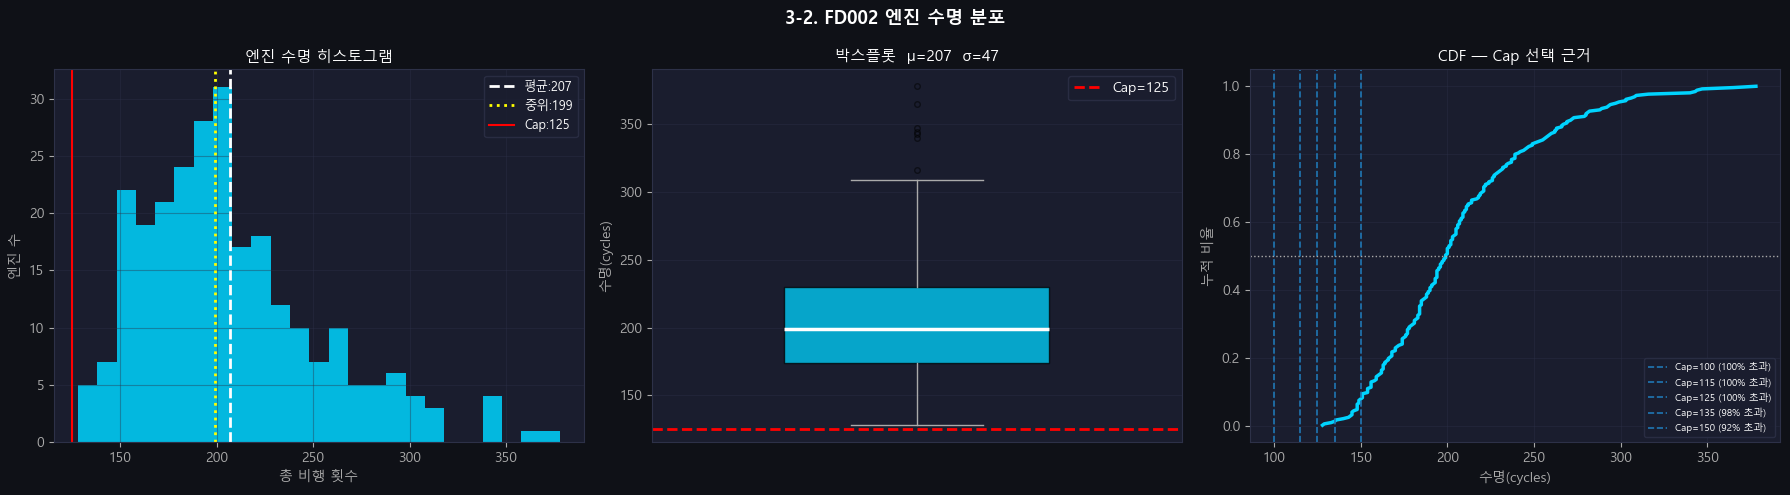


엔진 수명 통계:
  평균=206.8  중위=199.0  min=128  max=378
  Cap=100: 초과 엔진 100.0%
  Cap=115: 초과 엔진 100.0%
  Cap=125: 초과 엔진 100.0%
  Cap=135: 초과 엔진 98.5%
  Cap=150: 초과 엔진 91.9%


In [9]:
lifecycles = train_raw.groupby('unit_nr')['time_cycles'].max()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('3-2. FD002 엔진 수명 분포', fontsize=13, fontweight='bold')

ax = axes[0]
ax.hist(lifecycles, bins=25, color=C[0], alpha=0.85, edgecolor='none')
ax.axvline(lifecycles.mean(),   color='white',  ls='--', lw=2, label=f'평균:{lifecycles.mean():.0f}')
ax.axvline(lifecycles.median(), color='yellow', ls=':',  lw=2, label=f'중위:{lifecycles.median():.0f}')
ax.axvline(RUL_CAP, color='red', ls='-', lw=1.5, label=f'Cap:{RUL_CAP}')
ax.set_xlabel('총 비행 횟수'); ax.set_ylabel('엔진 수')
ax.set_title('엔진 수명 히스토그램'); ax.legend(fontsize=9)

ax = axes[1]
bp = ax.boxplot(lifecycles, patch_artist=True, vert=True, widths=0.5,
                medianprops=dict(color='white', lw=2.5),
                whiskerprops=dict(color=GRAY), capprops=dict(color=GRAY),
                flierprops=dict(marker='o', color=GRAY, markersize=4, alpha=0.5))
bp['boxes'][0].set_facecolor(C[0]); bp['boxes'][0].set_alpha(0.75)
ax.axhline(RUL_CAP, color='red', ls='--', lw=2, label=f'Cap={RUL_CAP}')
ax.set_ylabel('수명(cycles)')
ax.set_title(f'박스플롯  μ={lifecycles.mean():.0f}  σ={lifecycles.std():.0f}')
ax.set_xticks([]); ax.legend()

ax = axes[2]
lc_sorted = np.sort(lifecycles)
cdf = np.arange(1, len(lc_sorted)+1)/len(lc_sorted)
ax.plot(lc_sorted, cdf, color=C[0], lw=2.5)
for cap in [100, 115, 125, 135, 150]:
    pct = (lifecycles <= cap).mean()
    ax.axvline(cap, ls='--', lw=1.2, label=f'Cap={cap} ({(1-pct)*100:.0f}% 초과)')
ax.axhline(0.5, color=GRAY, ls=':', lw=1)
ax.set_xlabel('수명(cycles)'); ax.set_ylabel('누적 비율')
ax.set_title('CDF — Cap 선택 근거'); ax.legend(fontsize=7)

plt.tight_layout(); plt.show()

print('\n엔진 수명 통계:')
print(f'  평균={lifecycles.mean():.1f}  중위={lifecycles.median():.1f}  min={lifecycles.min()}  max={lifecycles.max()}')
for cap in [100, 115, 125, 135, 150]:
    pct = (lifecycles > cap).mean()*100
    print(f'  Cap={cap}: 초과 엔진 {pct:.1f}%')

### 4-3. 클러스터별 운전 조건 분포 시각화 [FD002 전용]

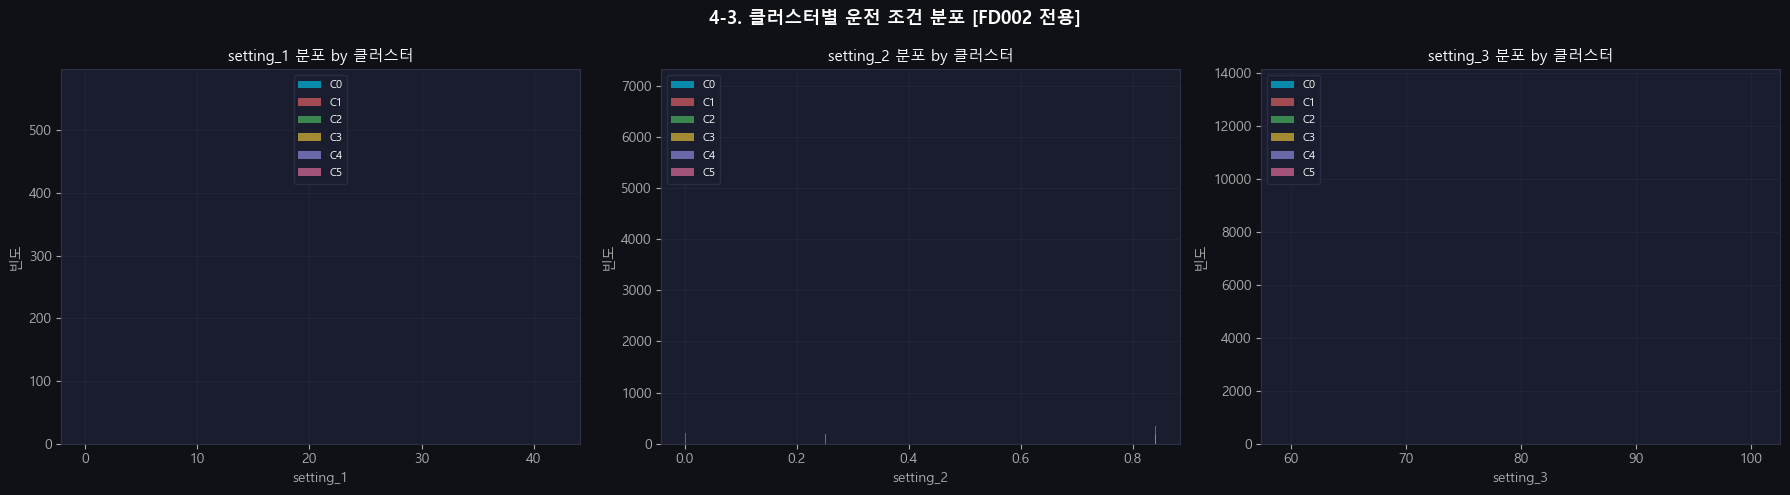


--- 클러스터 내 운전 조건 표준편차 ---


,setting_1,setting_2,setting_3
op_cluster,,,
0,0.00291,0.00064,0.0
1,0.00289,0.00066,0.0
2,0.00288,0.00065,0.0
3,0.00087,0.00065,0.0
4,0.00290,0.00064,0.0
5,0.00288,0.00065,0.0


📌 값이 작을수록 클러스터 내 운전 조건이 균일함 → 클러스터링 품질 양호


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('4-3. 클러스터별 운전 조건 분포 [FD002 전용]', fontsize=13, fontweight='bold')

for ax, op in zip(axes, OP_COLS):
    for c in range(N_CLUSTERS):
        mask = train_raw['op_cluster'] == c
        data = train_raw.loc[mask, op]
        ax.hist(data, bins=30, alpha=0.6, color=CLUSTER_COLORS[c], label=f'C{c}', edgecolor='none')
    ax.set_title(f'{op} 분포 by 클러스터')
    ax.set_xlabel(op); ax.set_ylabel('빈도')
    ax.legend(fontsize=8)

plt.tight_layout(); plt.show()

# 클러스터 내 운전 조건 표준편차 (작을수록 클러스터링 품질 좋음)
print('\n--- 클러스터 내 운전 조건 표준편차 ---')
intra_std = train_raw.groupby('op_cluster')[OP_COLS].std()
display(intra_std.round(5))
print('📌 값이 작을수록 클러스터 내 운전 조건이 균일함 → 클러스터링 품질 양호')

### 4-4. 센서 분포 & 이상치 (전처리 전)

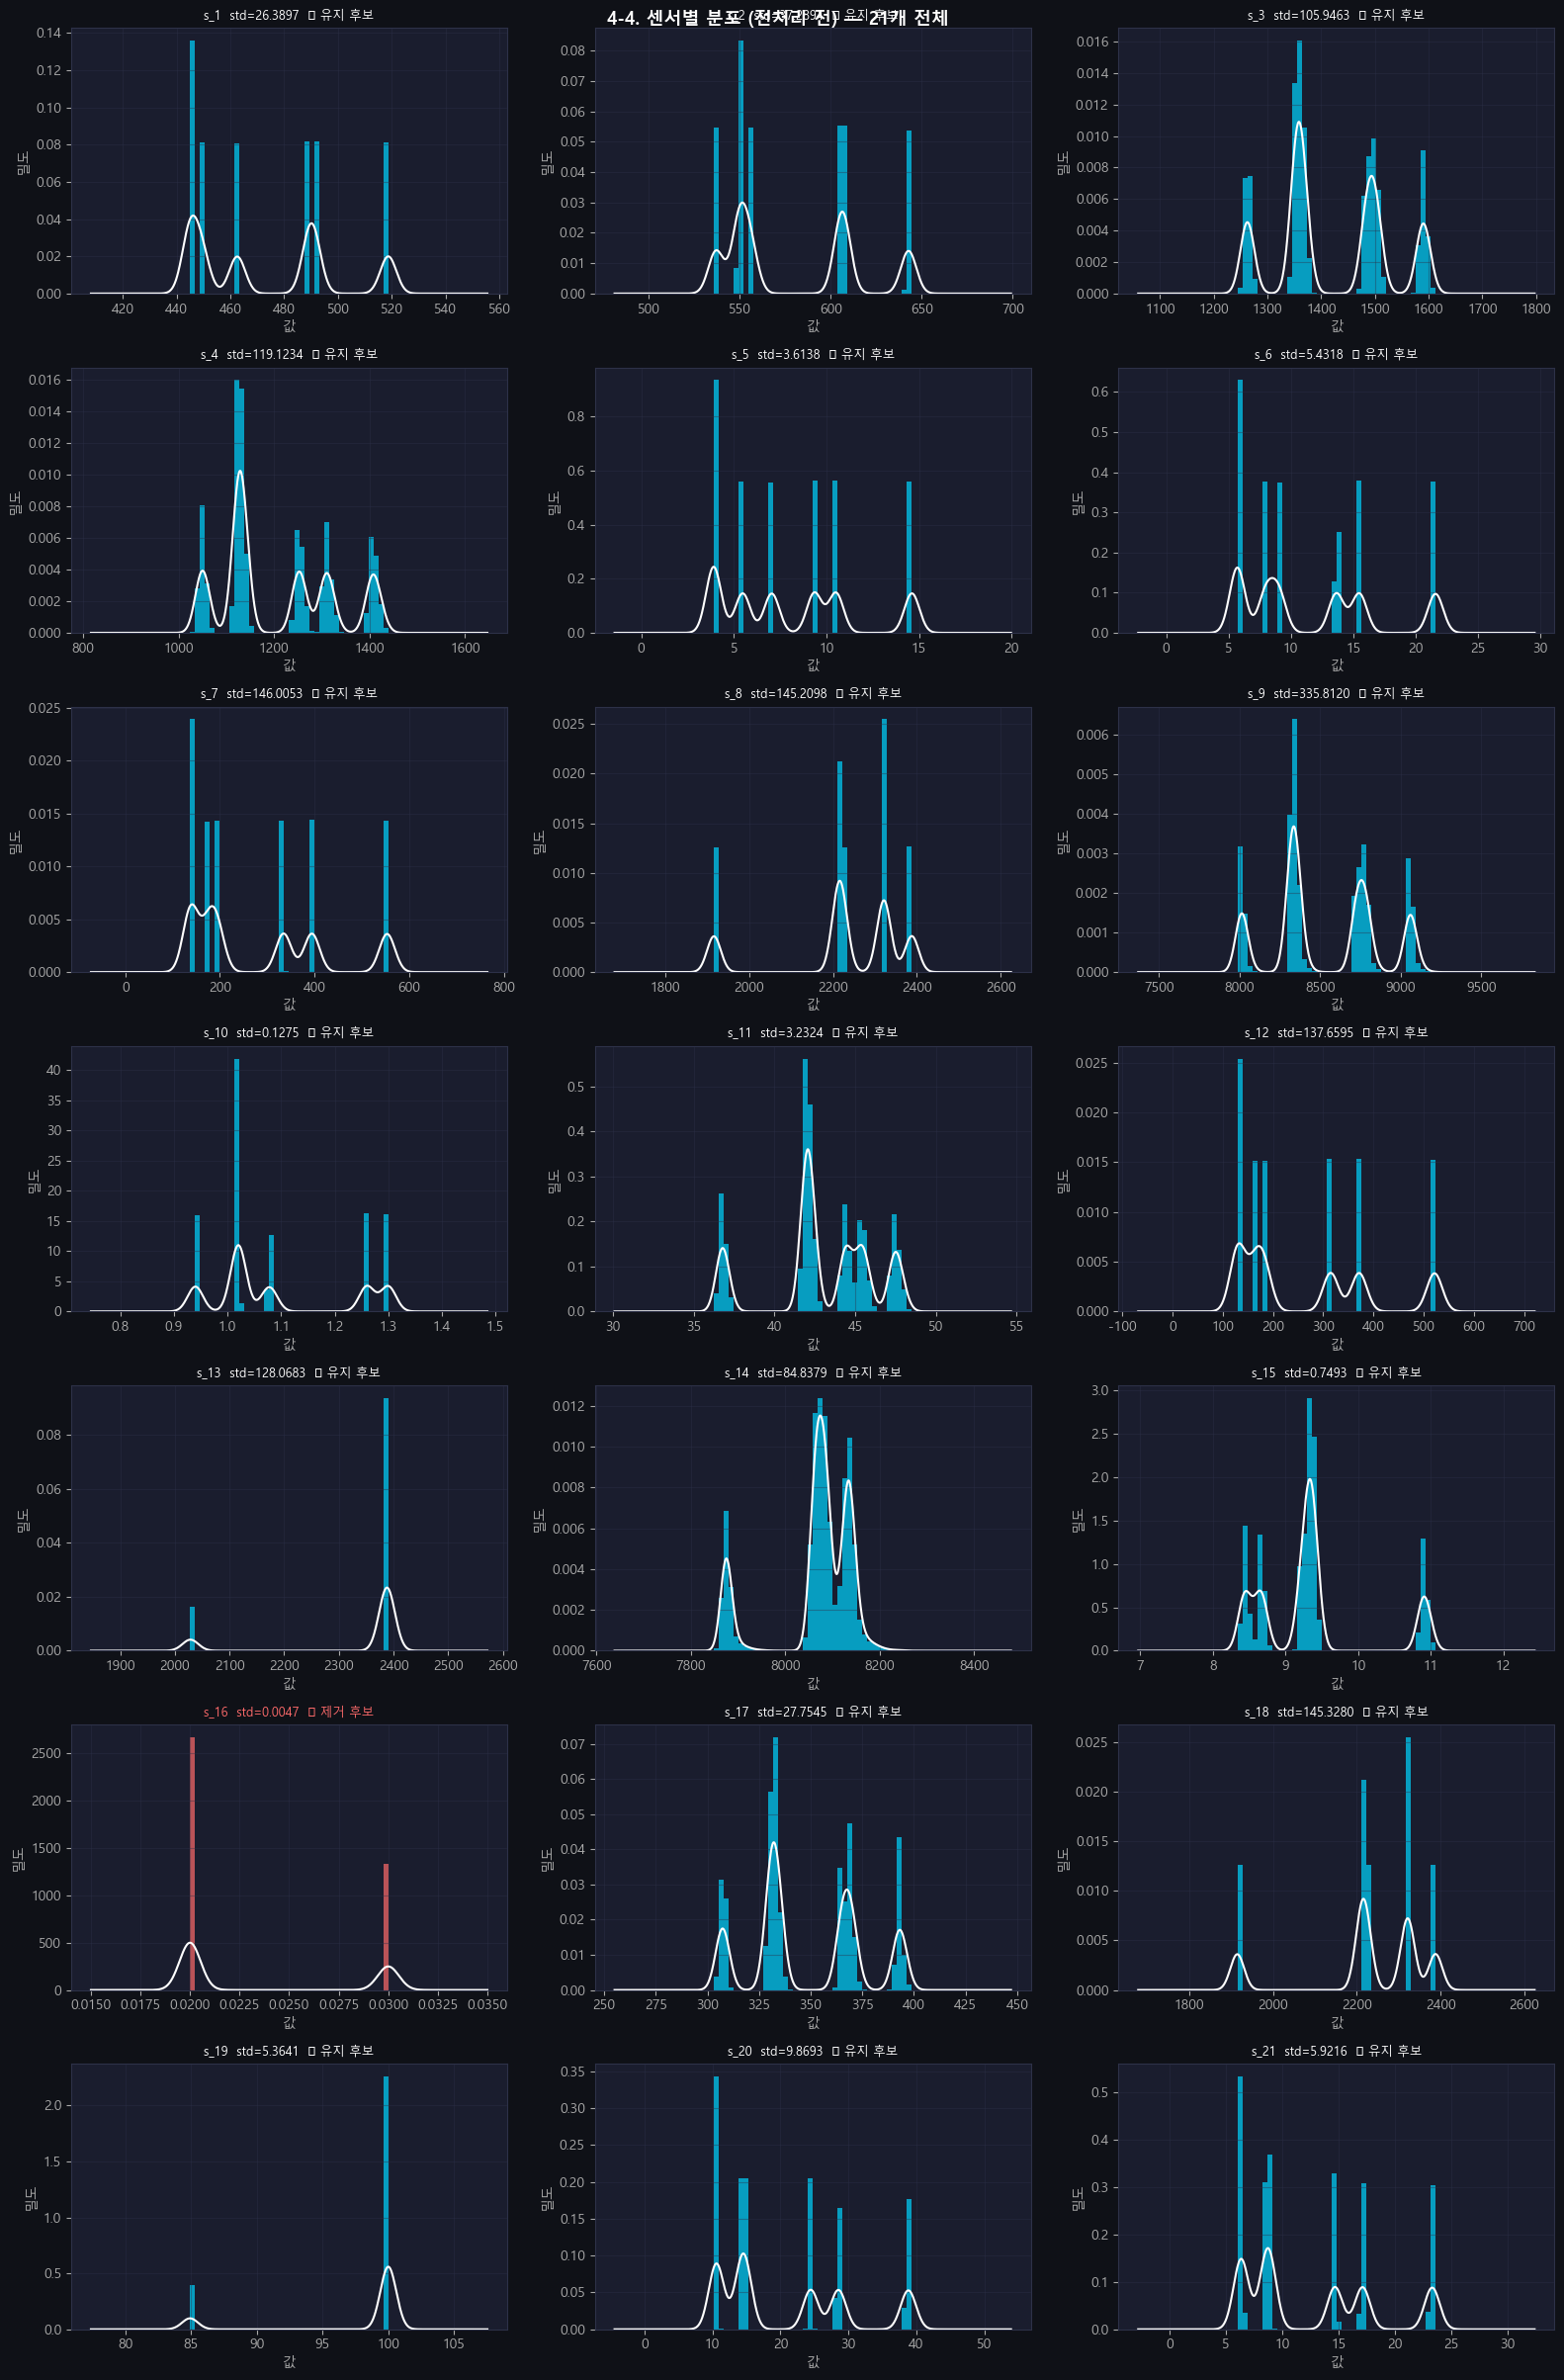

--- IQR 기준 이상치 탐지 ---


,센서,이상치 수,비율(%)
7,s_8,8002,14.885
10,s_11,3433,6.386
12,s_13,9640,17.932
13,s_14,8049,14.972
14,s_15,8002,14.885
17,s_18,8002,14.885
18,s_19,8002,14.885


In [11]:
n_cols, n_rows = 3, 7
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows*3.5))
fig.suptitle('4-4. 센서별 분포 (전처리 전) — 21개 전체', fontsize=13, fontweight='bold')

for ax, s in zip(axes.flat, SENSOR_COLS):
    data = train_raw[s].dropna()
    std_val = data.std()
    is_const = std_val < CONST_THR
    color = C[1] if is_const else C[0]
    ax.hist(data, bins=40, color=color, alpha=0.7, density=True, edgecolor='none')
    try: data.plot.kde(ax=ax, color='white', lw=1.5)
    except: pass
    label = '❌ 제거 후보' if is_const else '✅ 유지 후보'
    ax.set_title(f'{s}  std={std_val:.4f}  {label}', fontsize=9,
                 color=C[1] if is_const else WHITE)
    ax.set_xlabel('값'); ax.set_ylabel('밀도')

for ax in axes.flat[len(SENSOR_COLS):]: ax.set_visible(False)
plt.tight_layout(); plt.show()

print('--- IQR 기준 이상치 탐지 ---')
outlier_rows = []
for s in SENSOR_COLS:
    Q1, Q3 = train_raw[s].quantile(0.25), train_raw[s].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((train_raw[s] < Q1-1.5*IQR)|(train_raw[s] > Q3+1.5*IQR)).sum()
    outlier_rows.append({'센서': s, '이상치 수': n_out,
                         '비율(%)': round(n_out/len(train_raw)*100, 3)})
out_df = pd.DataFrame(outlier_rows)
nonzero = out_df[out_df['이상치 수']>0]
if len(nonzero): display(nonzero)
else: print('✅ IQR 기준 이상치 없음')

### 4-5. 클러스터별 센서 분포 비교 [FD002 전용]

In [ ]:
# 운전 조건에 따라 센서값이 크게 달라지는지 확인
# → 달라야 클러스터별 정규화가 의미 있음
from matplotlib.colors import LinearSegmentedColormap
cmap_rg = LinearSegmentedColormap.from_list('rg',['#ff6b6b','#1a1d2e','#00d4ff'], N=256)

show_sensors = SENSOR_COLS[:12]  # 대표 12개
n_cols = 4; n_rows = 3
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows*3.5))
fig.suptitle('4-5. 클러스터별 센서 분포 비교 (전처리 전) [FD002 전용]',
             fontsize=13, fontweight='bold')

for ax, s in zip(axes.flat, show_sensors):
    for c in range(N_CLUSTERS):
        mask = train_raw['op_cluster'] == c
        data = train_raw.loc[mask, s].dropna()
        if len(data) > 1:
            try: data.plot.kde(ax=ax, color=CLUSTER_COLORS[c], lw=1.5, label=f'C{c}')
            except: pass
    ax.set_title(f'{s}', fontsize=9)
    ax.set_xlabel('센서값'); ax.set_ylabel('밀도')
    ax.legend(fontsize=6)

for ax in axes.flat[len(show_sensors):]: ax.set_visible(False)
plt.tight_layout(); plt.show()

# Kruskal-Wallis 검정: 클러스터 간 분포 차이
print('--- Kruskal-Wallis 검정: 클러스터 간 센서 분포 차이 ---')
kw_rows = []
for s in SENSOR_COLS:
    groups = [train_raw[train_raw['op_cluster']==c][s].dropna().values for c in range(N_CLUSTERS)]
    groups = [g for g in groups if len(g) > 1]
    if len(groups) >= 2:
        h_stat, p_val = kruskal(*groups)
    else:
        h_stat, p_val = np.nan, np.nan
    kw_rows.append({'센서': s, 'H통계량': round(h_stat,2) if np.isfinite(h_stat) else np.nan,
                    'p-value': round(p_val,4) if np.isfinite(p_val) else np.nan,
                    '판정': '✅ 조건간 차이 유의' if (np.isfinite(p_val) and p_val<0.05) else '⚠️ 차이 없음',
                    '클러스터별 정규화 필요': '🔴 필수' if (np.isfinite(p_val) and p_val<0.05) else '🟢 불필요'})
kw_df = pd.DataFrame(kw_rows)

# [추가] BH-FDR 다중검정 보정
from statsmodels.stats.multitest import multipletests
_pvals = kw_df['p-value'].fillna(1.0).values
_rej, _padj, *_ = multipletests(_pvals, alpha=0.05, method='fdr_bh')
kw_df['p_adj_BH'] = np.round(_padj, 4)
kw_df['판정_BH']  = ['✅ 유의(FDR)' if r else '⚠️ 비유의(FDR)' for r in _rej]

display(kw_df)
print(f"\n클러스터간 유의 (raw p<0.05): {(kw_df['p-value']<0.05).sum()}/{len(kw_df)}개")
print(f"클러스터간 유의 (BH-FDR<0.05): {sum(_rej)}/{len(kw_df)}개")
print('📌 대부분 유의하면 클러스터별 정규화가 반드시 필요함을 의미')

### 4-6. 센서 간 상관관계 히트맵 (전처리 전)

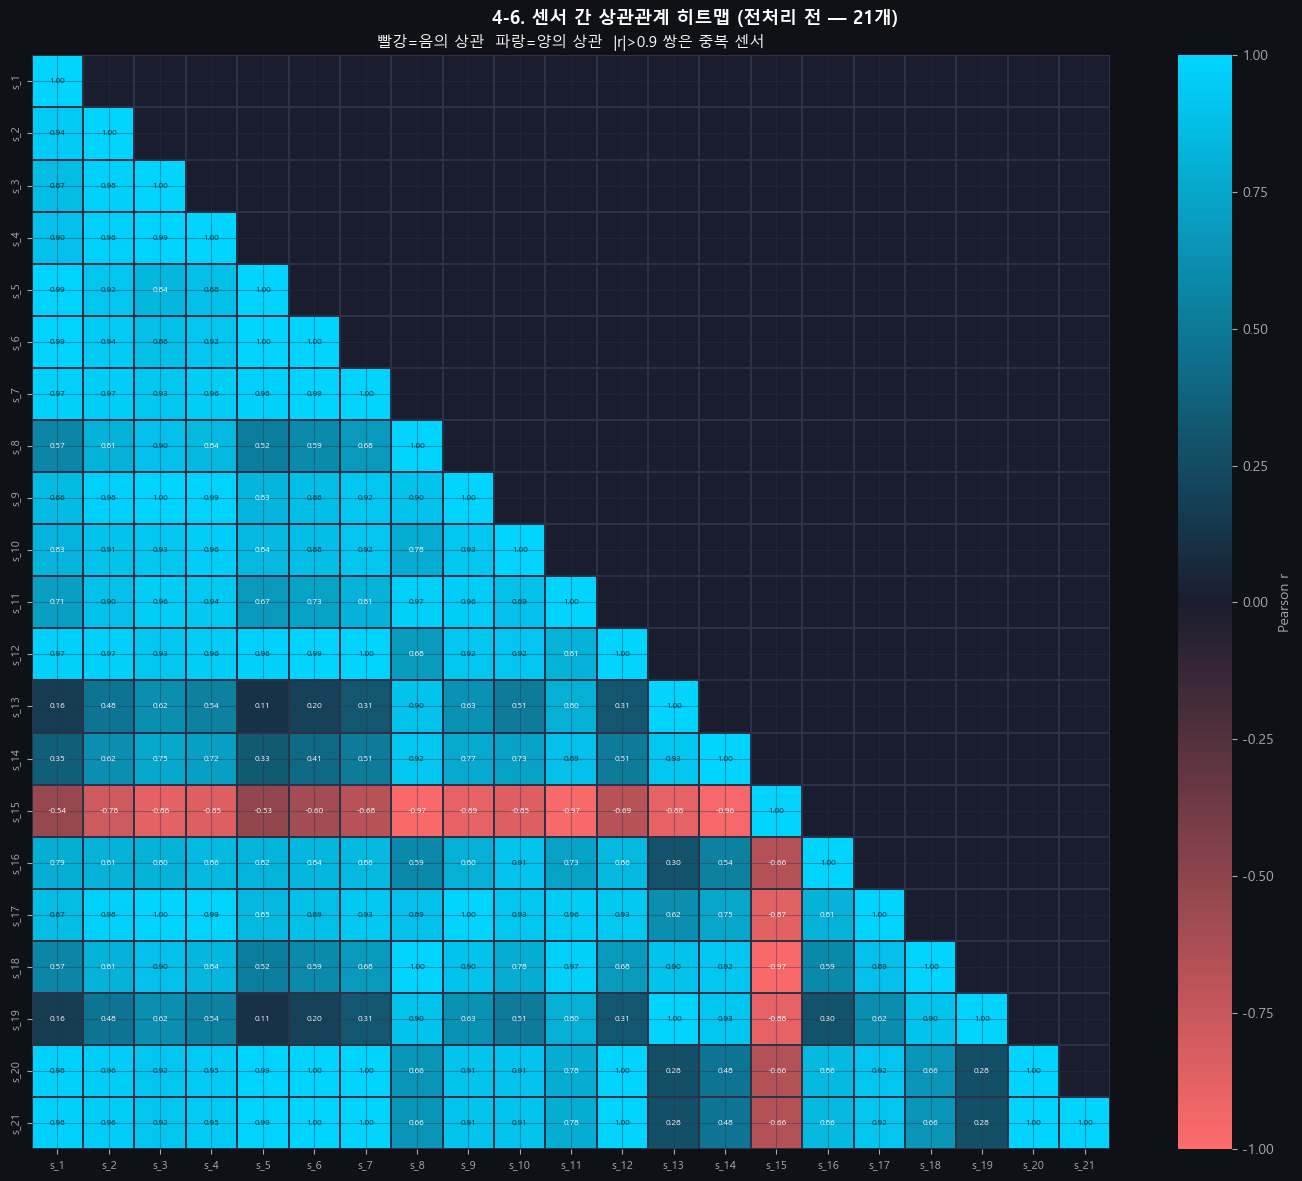

고상관 쌍 (|r|>0.9): 87개


,센서A,센서B,r
0,s_1,s_2,0.944
1,s_1,s_5,0.986
2,s_1,s_6,0.986
3,s_1,s_7,0.973
4,s_1,s_12,0.973
...,...,...,...
82,s_15,s_18,-0.971
83,s_17,s_20,0.919
84,s_17,s_21,0.919
85,s_18,s_19,0.903


In [13]:
cmap_rg = LinearSegmentedColormap.from_list('rg',['#ff6b6b','#1a1d2e','#00d4ff'], N=256)
corr_before = train_raw[SENSOR_COLS].corr()

fig, ax = plt.subplots(figsize=(14, 12))
fig.suptitle('4-6. 센서 간 상관관계 히트맵 (전처리 전 — 21개)', fontsize=13, fontweight='bold')

mask = np.triu(np.ones_like(corr_before, dtype=bool), k=1)
sns.heatmap(corr_before, ax=ax, mask=mask, cmap=cmap_rg, center=0,
            vmin=-1, vmax=1, annot=True, fmt='.2f',
            annot_kws={'size': 6}, linewidths=0.3, linecolor=GRID,
            cbar_kws={'label': 'Pearson r'})
ax.set_title('빨강=음의 상관  파랑=양의 상관  |r|>0.9 쌍은 중복 센서')
ax.tick_params(labelsize=8)
plt.tight_layout(); plt.show()

pairs = []
for i in range(len(SENSOR_COLS)):
    for j in range(i+1, len(SENSOR_COLS)):
        r = corr_before.iloc[i, j]
        if abs(r) > 0.9:
            pairs.append({'센서A': SENSOR_COLS[i], '센서B': SENSOR_COLS[j], 'r': round(r, 3)})
print(f'고상관 쌍 (|r|>0.9): {len(pairs)}개')
if pairs: display(pd.DataFrame(pairs))

### 4-7. 센서별 열화 트렌드 (전처리 전)

클러스터별 상관관계 계산 완료 (6개 클러스터 평균)
센서별 평균 |r| (상위 5개):
s_11    0.726
s_4     0.698
s_15    0.689
s_17    0.616
s_16    0.601
dtype: float64

📌 적용 임계값 |r|>0.1 → 16개 센서 확보


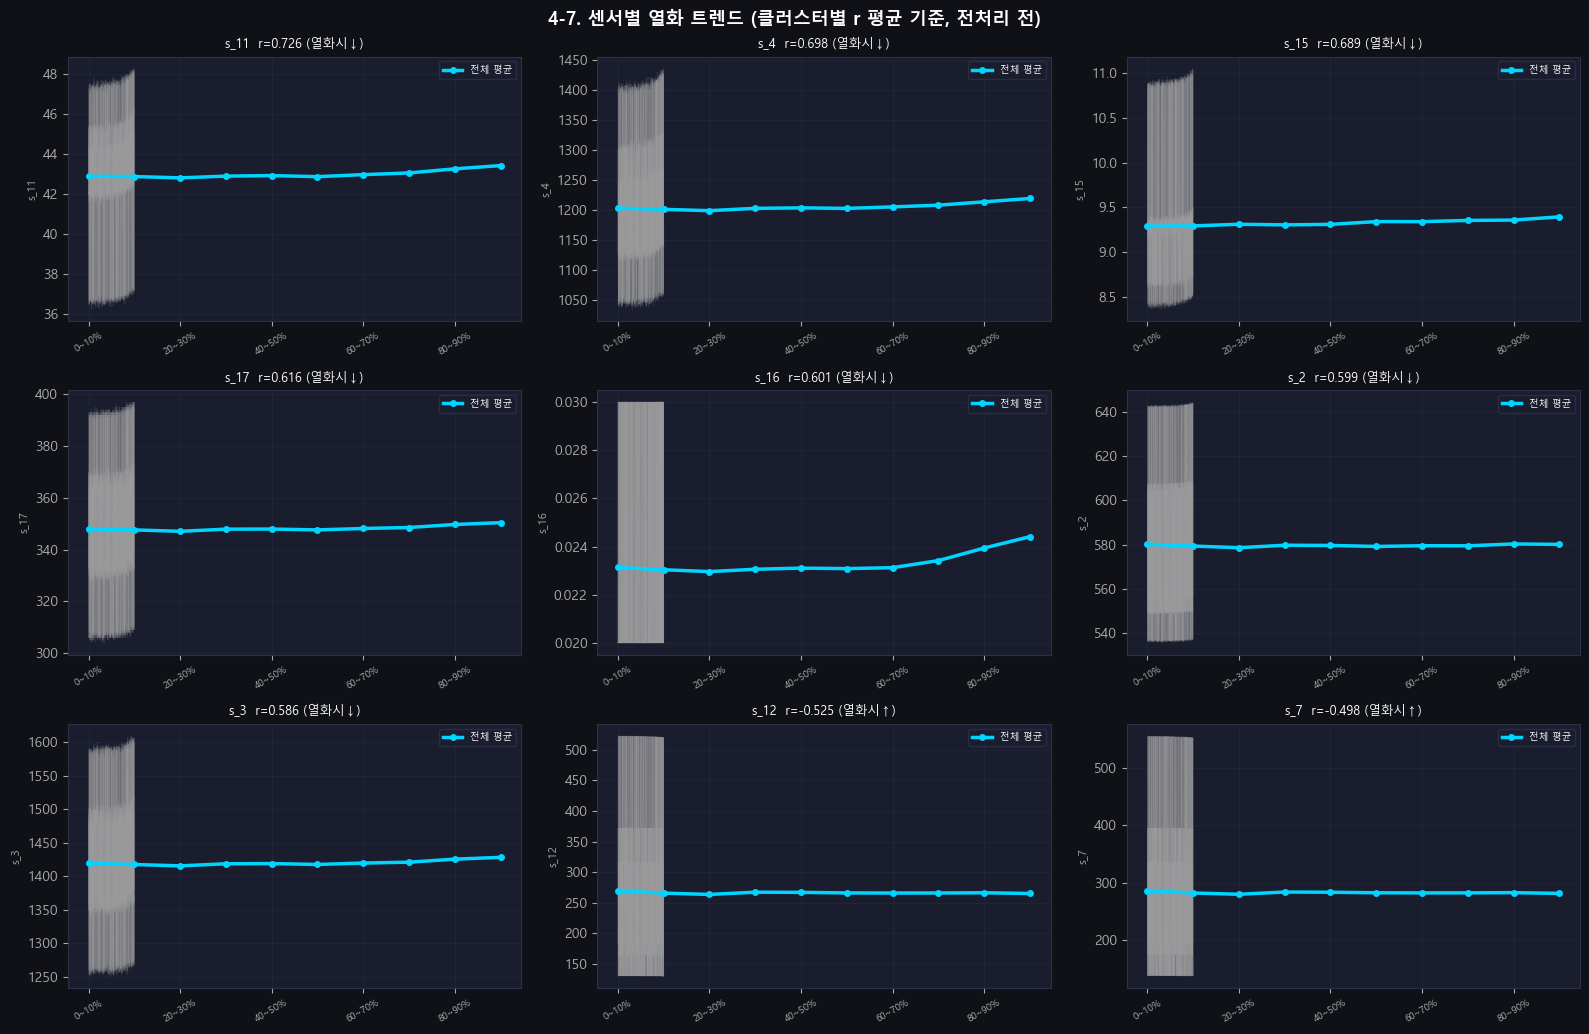


📌 r < 0: 열화될수록 센서값 증가 (온도↑)
📌 r > 0: 열화될수록 센서값 감소 (속도↓)
📌 FD002: 클러스터별 r 평균으로 계산하여 조건 혼재 효과를 제거함


In [14]:
tr_trend = train_raw.copy()
mc = tr_trend.groupby('unit_nr')['time_cycles'].max().rename('max_c')
tr_trend = tr_trend.join(mc, on='unit_nr')
tr_trend['norm_life'] = tr_trend['time_cycles'] / tr_trend['max_c']
tr_trend['RUL']       = tr_trend['max_c'] - tr_trend['time_cycles']

bins   = np.linspace(0, 1, 11)
labels = [f'{int(a*100)}~{int(b*100)}%' for a,b in zip(bins[:-1], bins[1:])]
tr_trend['life_bin'] = pd.cut(tr_trend['norm_life'], bins=bins, labels=labels)
trend_mean = tr_trend.groupby('life_bin', observed=True)[SENSOR_COLS].mean()

# ── [FD002 수정] 클러스터별 상관관계 계산 후 평균 ─────────────────────────
# 이유: 운전 조건 6개가 섞인 채 전체 상관관계를 계산하면
#       조건 간 센서 스케일 차이가 노이즈로 작용해 r 값이 희석됨
cluster_corrs = []
for c in range(N_CLUSTERS):
    mask = tr_trend['op_cluster'] == c
    sub  = tr_trend[mask]
    if len(sub) > 10:
        corr_c = sub[SENSOR_COLS + ['norm_life']].corr()['norm_life'][SENSOR_COLS]
        cluster_corrs.append(corr_c)

corr_with_life = pd.concat(cluster_corrs, axis=1).mean(axis=1)

print(f'클러스터별 상관관계 계산 완료 ({len(cluster_corrs)}개 클러스터 평균)')
print(f'센서별 평균 |r| (상위 5개):')
print(corr_with_life.abs().sort_values(ascending=False).head(5).round(3))

# ── 임계값 완화하며 센서 확보 + 안전장치 ─────────────────────────────────
trend_sensors = []
for thr in [0.1, 0.05, 0.01, 0.0]:
    trend_sensors = (corr_with_life[corr_with_life.abs() > thr]
                     .sort_values(key=abs, ascending=False)
                     .index.tolist())
    if trend_sensors:
        print(f'\n📌 적용 임계값 |r|>{thr} → {len(trend_sensors)}개 센서 확보')
        break

# 그래도 없으면 절대값 기준 상위 9개 강제 선택
if not trend_sensors:
    trend_sensors = corr_with_life.abs().sort_values(ascending=False).index.tolist()
    print('⚠️ 임계값 기준 센서 없음 → 상위 순서로 강제 선택')

trend_sensors = trend_sensors[:9]

n_cols = 3
n_rows = max(1, (len(trend_sensors) + n_cols - 1) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows*3.5))
fig.suptitle('4-7. 센서별 열화 트렌드 (클러스터별 r 평균 기준, 전처리 전)',
             fontsize=13, fontweight='bold')

# axes를 리스트로 변환 (제너레이터 소진 방지)
axes_list = list(np.array(axes).flat)
x_pos = range(len(labels))
sample_units = tr_trend['unit_nr'].unique()[:15]

for ax, s in zip(axes_list, trend_sensors):
    for u in sample_units:
        sub = tr_trend[tr_trend['unit_nr']==u].sort_values('norm_life')
        ax.plot(sub['norm_life'], sub[s], color=GRAY, alpha=0.15, lw=0.6)
    ax.plot(x_pos, trend_mean[s].values, color=C[0], lw=2.5,
            marker='o', markersize=4, label='전체 평균')
    r = corr_with_life[s]
    direction = '열화시↑' if r < 0 else '열화시↓'
    ax.set_title(f'{s}  r={r:.3f} ({direction})', fontsize=9)
    ax.set_xticks(x_pos[::2])
    ax.set_xticklabels(labels[::2], rotation=30, fontsize=7)
    ax.set_ylabel(s, fontsize=8)
    ax.legend(fontsize=7)

for ax in axes_list[len(trend_sensors):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

print('\n📌 r < 0: 열화될수록 센서값 증가 (온도↑)')
print('📌 r > 0: 열화될수록 센서값 감소 (속도↓)')
print('📌 FD002: 클러스터별 r 평균으로 계산하여 조건 혼재 효과를 제거함')

### 4-8. RUL 상관계수 (전처리 전)

클러스터 수: 6개  |  센서 수: 21개


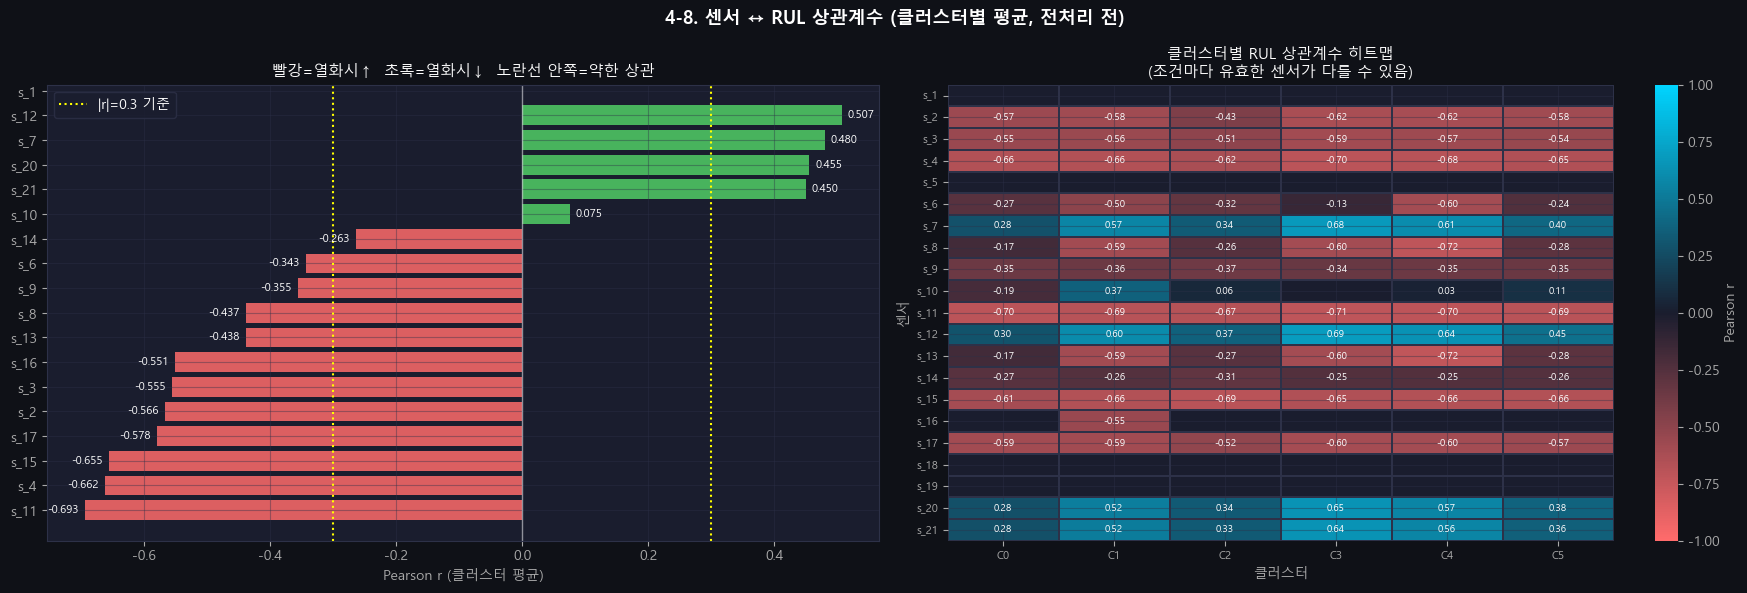


|r|>0.3 고상관 센서 (클러스터 평균 기준): 15개
  s_11: r=-0.693  Ps30 정적압력(psia)
  s_4: r=-0.662  T50 LPT 출구 온도(°R)
  s_15: r=-0.655  BPR 바이패스 비율
  s_17: r=-0.578  htBleed 블리드 엔탈피
  s_2: r=-0.566  T24 LPC 출구 온도(°R)
  s_3: r=-0.555  T30 HPC 출구 온도(°R)
  s_16: r=-0.551  farB 버너 연료공기비
  s_12: r=0.507  phi 연료/Ps30 비율
  s_7: r=0.480  P30 HPC 출구 압력(psia)
  s_20: r=0.455  W31 HPT 냉각블리드
  s_21: r=0.450  W32 LPT 냉각블리드
  s_13: r=-0.438  NRf 보정 팬 속도(rpm)
  s_8: r=-0.437  Nf 팬 속도(rpm)
  s_9: r=-0.355  Nc 코어 속도(rpm)
  s_6: r=-0.343  P15 바이패스 압력(psia)

📌 히트맵에서 클러스터마다 r 값이 다르면 → 클러스터별 정규화가 반드시 필요함을 의미


In [15]:
# ── [FD002 수정] 클러스터별 RUL 상관계수 계산 후 평균 ────────────────────────
# 이유: 조건 6개 혼재 시 RUL 상관관계가 희석됨
#       클러스터별로 따로 계산 후 평균을 내면 실제 열화 신호를 정확히 포착

cluster_rul_corrs = []
for c in range(N_CLUSTERS):
    mask = tr_trend['op_cluster'] == c
    sub  = tr_trend[mask]
    if len(sub) > 10:
        corr_c = sub[SENSOR_COLS + ['RUL']].corr()['RUL'][SENSOR_COLS]
        cluster_rul_corrs.append(corr_c)

# 클러스터별 상관계수 평균
rul_corr_before = pd.concat(cluster_rul_corrs, axis=1).mean(axis=1).sort_values()

print(f'클러스터 수: {len(cluster_rul_corrs)}개  |  센서 수: {len(rul_corr_before)}개')

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('4-8. 센서 ↔ RUL 상관계수 (클러스터별 평균, 전처리 전)',
             fontsize=13, fontweight='bold')

# 전체 평균 막대
bar_colors = [C[1] if v < 0 else C[2] for v in rul_corr_before]
bars = axes[0].barh(rul_corr_before.index, rul_corr_before.values,
                    color=bar_colors, alpha=0.85)
axes[0].axvline(0,    color='white',  lw=1, alpha=0.5)
axes[0].axvline( 0.3, color='yellow', lw=1.5, ls=':', label='|r|=0.3 기준')
axes[0].axvline(-0.3, color='yellow', lw=1.5, ls=':')
axes[0].set_xlabel('Pearson r (클러스터 평균)')
axes[0].set_title('빨강=열화시↑  초록=열화시↓  노란선 안쪽=약한 상관')
axes[0].legend()
for bar, val in zip(bars, rul_corr_before.values):
    axes[0].text(val + (0.01 if val >= 0 else -0.01),
                 bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center',
                 ha='left' if val >= 0 else 'right', fontsize=8)

# 클러스터별 히트맵 (센서 × 클러스터)
cluster_corr_matrix = pd.concat(cluster_rul_corrs, axis=1)
cluster_corr_matrix.columns = [f'C{i}' for i in range(len(cluster_rul_corrs))]

from matplotlib.colors import LinearSegmentedColormap
cmap_rg = LinearSegmentedColormap.from_list('rg',['#ff6b6b','#1a1d2e','#00d4ff'], N=256)
sns.heatmap(cluster_corr_matrix, ax=axes[1], cmap=cmap_rg, center=0,
            vmin=-1, vmax=1, annot=True, fmt='.2f',
            annot_kws={'size': 7}, linewidths=0.3, linecolor=GRID,
            cbar_kws={'label': 'Pearson r'})
axes[1].set_title('클러스터별 RUL 상관계수 히트맵\n(조건마다 유효한 센서가 다를 수 있음)')
axes[1].set_xlabel('클러스터'); axes[1].set_ylabel('센서')
axes[1].tick_params(labelsize=8)

plt.tight_layout()
plt.show()

high_corr = rul_corr_before[rul_corr_before.abs() > 0.3]
print(f'\n|r|>0.3 고상관 센서 (클러스터 평균 기준): {len(high_corr)}개')
for s, r in high_corr.sort_values(key=abs, ascending=False).items():
    print(f'  {s}: r={r:.3f}  {SENSOR_DESC.get(s,"")}')

print('\n📌 히트맵에서 클러스터마다 r 값이 다르면 → 클러스터별 정규화가 반드시 필요함을 의미')

### 4-9. 시차상관관계 (Sensor → RUL, lag 0~15)

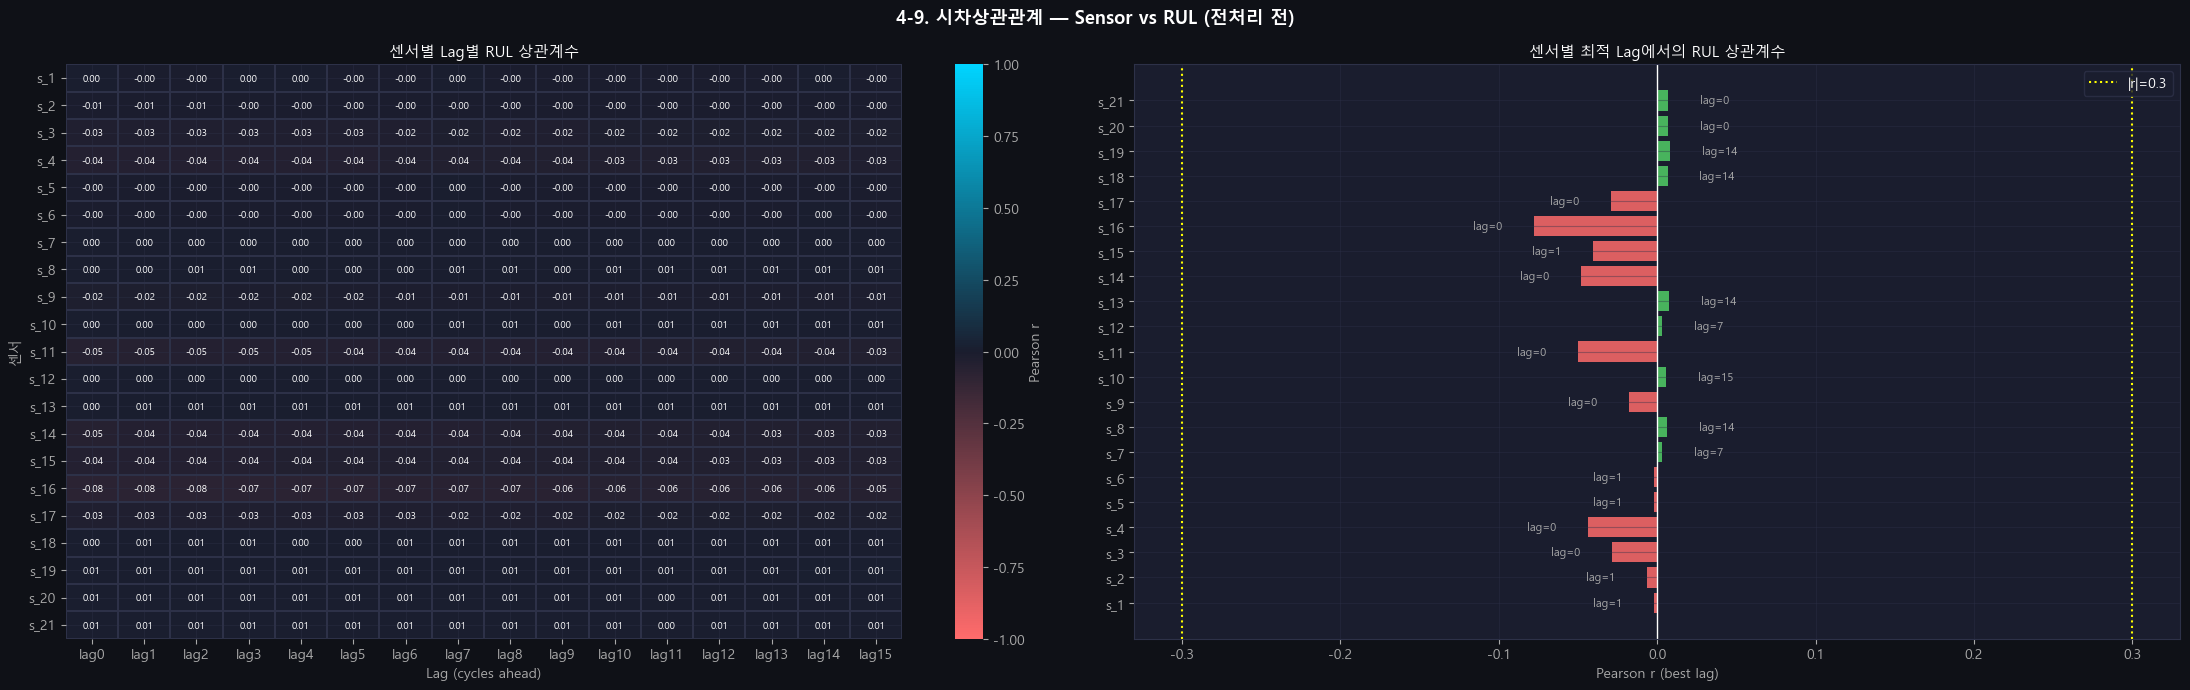

In [16]:
MAX_LAG = 15
LAGS    = list(range(0, MAX_LAG + 1))

lag_matrix = np.full((len(SENSOR_COLS), len(LAGS)), np.nan)

for si, s in enumerate(SENSOR_COLS):
    unit_lag_corrs = {lag: [] for lag in LAGS}
    for uid in tr_trend['unit_nr'].unique():
        udf    = tr_trend[tr_trend['unit_nr']==uid].sort_values('time_cycles')
        sensor = udf[s].values
        rul    = udf['RUL'].values
        for lag in LAGS:
            if len(sensor) > lag + 5:
                c_val = np.corrcoef(sensor[:len(sensor)-lag], rul[lag:])[0,1]
                if np.isfinite(c_val):
                    unit_lag_corrs[lag].append(c_val)
    lag_matrix[si] = [np.mean(unit_lag_corrs[l]) if unit_lag_corrs[l] else np.nan for l in LAGS]

lag_df = pd.DataFrame(lag_matrix, index=SENSOR_COLS, columns=[f'lag{l}' for l in LAGS])

best_lag_idx, best_lag_corr = [], []
for i in range(len(SENSOR_COLS)):
    row = lag_matrix[i]
    if np.all(np.isnan(row)):
        best_lag_idx.append(0); best_lag_corr.append(np.nan)
    else:
        idx = int(np.nanargmax(np.abs(row)))
        best_lag_idx.append(idx); best_lag_corr.append(float(row[idx]))

best_lag_corr_plot = [v if np.isfinite(v) else 0.0 for v in best_lag_corr]
cmap_lag = LinearSegmentedColormap.from_list('lag',['#ff6b6b','#1a1d2e','#00d4ff'], N=256)

fig, axes = plt.subplots(1, 2, figsize=(22, 7))
fig.suptitle('4-9. 시차상관관계 — Sensor vs RUL (전처리 전)', fontsize=13, fontweight='bold')

sns.heatmap(lag_df, ax=axes[0], cmap=cmap_lag, center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', annot_kws={'size': 7},
            linewidths=0.3, linecolor=GRID, cbar_kws={'label': 'Pearson r'})
axes[0].set_title('센서별 Lag별 RUL 상관계수')
axes[0].set_xlabel('Lag (cycles ahead)'); axes[0].set_ylabel('센서')

bar_colors = [GRAY if not np.isfinite(v) else (C[1] if v<0 else C[2]) for v in best_lag_corr]
bars = axes[1].barh(SENSOR_COLS, best_lag_corr_plot, color=bar_colors, alpha=0.85)
axes[1].axvline(0,    color='white',  lw=1)
axes[1].axvline( 0.3, color='yellow', lw=1.5, ls=':', label='|r|=0.3')
axes[1].axvline(-0.3, color='yellow', lw=1.5, ls=':')
for bar, li, v in zip(bars, best_lag_idx, best_lag_corr):
    if not np.isfinite(v): continue
    x = bar.get_width()
    axes[1].text(x+(0.02 if x>=0 else -0.02), bar.get_y()+bar.get_height()/2,
                 f'lag={LAGS[li]}', va='center', ha='left' if x>=0 else 'right',
                 fontsize=8, color=GRAY)
axes[1].set_title('센서별 최적 Lag에서의 RUL 상관계수')
axes[1].set_xlabel('Pearson r (best lag)'); axes[1].legend()
plt.tight_layout(); plt.show()

### 4-10. Mann-Kendall 트렌드 검정 (전처리 전)

=== 4-10. Mann-Kendall 트렌드 검정 (전처리 전) ===


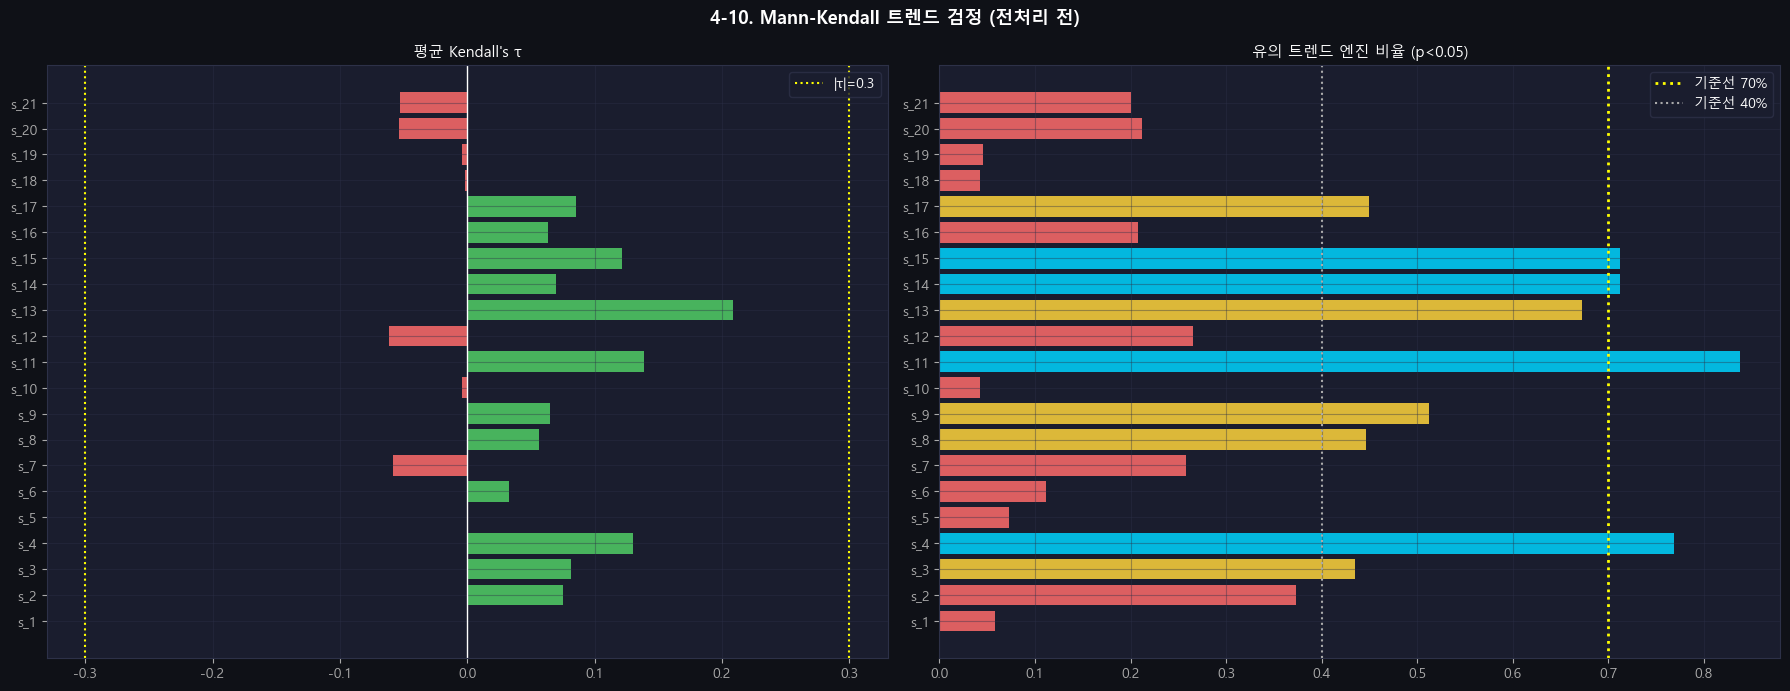

,평균 τ,트렌드 방향,유의 엔진 비율,열화 신호 판정,센서 설명
센서,,,,,
s_1,0.0008,상승 ↑,5.8%,❌ 약함,T2 팬 입구 온도(°R)
s_2,0.0750,상승 ↑,37.3%,❌ 약함,T24 LPC 출구 온도(°R)
s_3,0.0813,상승 ↑,43.5%,🔶 보통,T30 HPC 출구 온도(°R)
s_4,0.1303,상승 ↑,76.9%,✅ 강함,T50 LPT 출구 온도(°R)
s_5,0.0007,상승 ↑,7.3%,❌ 약함,P2 팬 입구 압력(psia)
s_6,0.0329,상승 ↑,11.2%,❌ 약함,P15 바이패스 압력(psia)
s_7,-0.0583,하강 ↓,25.8%,❌ 약함,P30 HPC 출구 압력(psia)
s_8,0.0564,상승 ↑,44.6%,🔶 보통,Nf 팬 속도(rpm)
s_9,0.0653,상승 ↑,51.2%,🔶 보통,Nc 코어 속도(rpm)


In [17]:
print('=== 4-10. Mann-Kendall 트렌드 검정 (전처리 전) ===')

mk_rows = []
for s in SENSOR_COLS:
    taus, ps = [], []
    for uid in tr_trend['unit_nr'].unique():
        arr = (tr_trend[tr_trend['unit_nr']==uid]
               .sort_values('time_cycles')[s].values)
        if len(arr) >= 8:
            tau, p = kendalltau(np.arange(len(arr)), arr)
            if np.isfinite(tau):
                taus.append(tau); ps.append(p)
    mean_tau  = np.mean(taus)  if taus else np.nan
    sig_ratio = np.mean([p < 0.05 for p in ps]) if ps else np.nan
    mk_rows.append({'센서': s, '평균 τ': round(mean_tau,4) if np.isfinite(mean_tau) else np.nan,
                    '트렌드 방향': ('상승 ↑' if mean_tau>0 else '하강 ↓') if np.isfinite(mean_tau) else 'N/A',
                    '유의 엔진 비율': f'{sig_ratio*100:.1f}%' if np.isfinite(sig_ratio) else 'N/A',
                    '열화 신호 판정': ('✅ 강함' if sig_ratio>=0.7 else '🔶 보통' if sig_ratio>=0.4 else '❌ 약함') if np.isfinite(sig_ratio) else '⬜ 상수',
                    '센서 설명': SENSOR_DESC.get(s, s)})

mk_df = pd.DataFrame(mk_rows).set_index('센서')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('4-10. Mann-Kendall 트렌드 검정 (전처리 전)', fontsize=13, fontweight='bold')

tau_vals = [v if np.isfinite(v) else 0 for v in mk_df['평균 τ'].values]
bc_tau   = [C[2] if v>0 else C[1] for v in tau_vals]
axes[0].barh(mk_df.index, tau_vals, color=bc_tau, alpha=0.85)
axes[0].axvline(0, color='white', lw=1)
axes[0].axvline( 0.3, color='yellow', lw=1.5, ls=':')
axes[0].axvline(-0.3, color='yellow', lw=1.5, ls=':', label='|τ|=0.3')
axes[0].set_title("평균 Kendall's τ"); axes[0].legend()

sig_vals = [float(v.replace('%',''))/100 if v!='N/A' else 0 for v in mk_df['유의 엔진 비율'].values]
bc_sig   = [C[0] if v>=0.7 else C[3] if v>=0.4 else C[1] for v in sig_vals]
axes[1].barh(mk_df.index, sig_vals, color=bc_sig, alpha=0.85)
axes[1].axvline(0.7, color='yellow', lw=2, ls=':', label='기준선 70%')
axes[1].axvline(0.4, color=GRAY,     lw=1.5, ls=':', label='기준선 40%')
axes[1].set_title('유의 트렌드 엔진 비율 (p<0.05)'); axes[1].legend()
plt.tight_layout(); plt.show()
display(mk_df)

### 4-11. 대응 표본 검정 — 초기(RUL 상위 80%) vs 말기(RUL 하위 20%)

In [ ]:
print('=== 4-11. 대응 표본 검정 (전처리 전) ===')

paired_rows = []
for s in SENSOR_COLS:
    early_means, late_means = [], []
    for uid in tr_trend['unit_nr'].unique():
        udf    = tr_trend[tr_trend['unit_nr']==uid].sort_values('time_cycles')
        thresh = udf['RUL'].quantile(0.20)
        early  = udf[udf['RUL'] >  thresh][s].mean()
        late   = udf[udf['RUL'] <= thresh][s].mean()
        if np.isfinite(early) and np.isfinite(late):
            early_means.append(early); late_means.append(late)
    diffs = np.array(early_means) - np.array(late_means)
    _, p_sw = shapiro(diffs) if len(diffs) >= 3 else (np.nan, 0.0)
    if p_sw > 0.05:
        stat, p_val = ttest_rel(early_means, late_means); test_name = 'Paired t-test'
    else:
        stat, p_val = wilcoxon(diffs); test_name = 'Wilcoxon'
    paired_rows.append({'센서': s, '초기 평균': round(np.mean(early_means),4),
                        '말기 평균': round(np.mean(late_means),4),
                        '평균 차이(Δ)': round(float(np.mean(diffs)),4),
                        '검정 방법': test_name, 'p-value': round(p_val,4),
                        '판정': '유의 ✅' if p_val<0.05 else '비유의 ⚠️'})

paired_df = pd.DataFrame(paired_rows).set_index('센서')
# [추가] BH-FDR 보정
from statsmodels.stats.multitest import multipletests
_pvals = paired_df['p-value'].fillna(1.0).values
_rej, _padj, *_ = multipletests(_pvals, alpha=0.05, method='fdr_bh')
paired_df['p_adj_BH'] = np.round(_padj, 4)
paired_df['판정_BH']  = ['유의(FDR) ✅' if r else '비유의(FDR) ⚠️' for r in _rej]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('4-11. 대응 표본 검정 — 초기 vs 말기 (전처리 전)', fontsize=13, fontweight='bold')

p_vals = paired_df['p-value'].values
log_p  = -np.log10(np.clip(p_vals, 1e-10, 1))
bc_p   = [C[2] if p<0.05 else C[1] for p in p_vals]
axes[0].barh(paired_df.index, log_p, color=bc_p, alpha=0.85)
axes[0].axvline(-np.log10(0.05), color='yellow', lw=2, ls=':', label='p=0.05')
axes[0].set_title('-log₁₀(p-value)'); axes[0].legend()

diff_vals = paired_df['평균 차이(Δ)'].values
bc_d = [C[2] if v>0 else C[1] for v in diff_vals]
axes[1].barh(paired_df.index, diff_vals, color=bc_d, alpha=0.85)
axes[1].axvline(0, color='white', lw=1)
axes[1].set_title('초기 − 말기 평균 차이 (Δ)')
plt.tight_layout(); plt.show()

display(paired_df.drop(columns=[]))
print(f"\n유의한 센서: {(paired_df['판정']=='유의 ✅').sum()}/{len(paired_df)}개")

## 5. 결정 2 — Piecewise RUL 생성 & Cap 설정

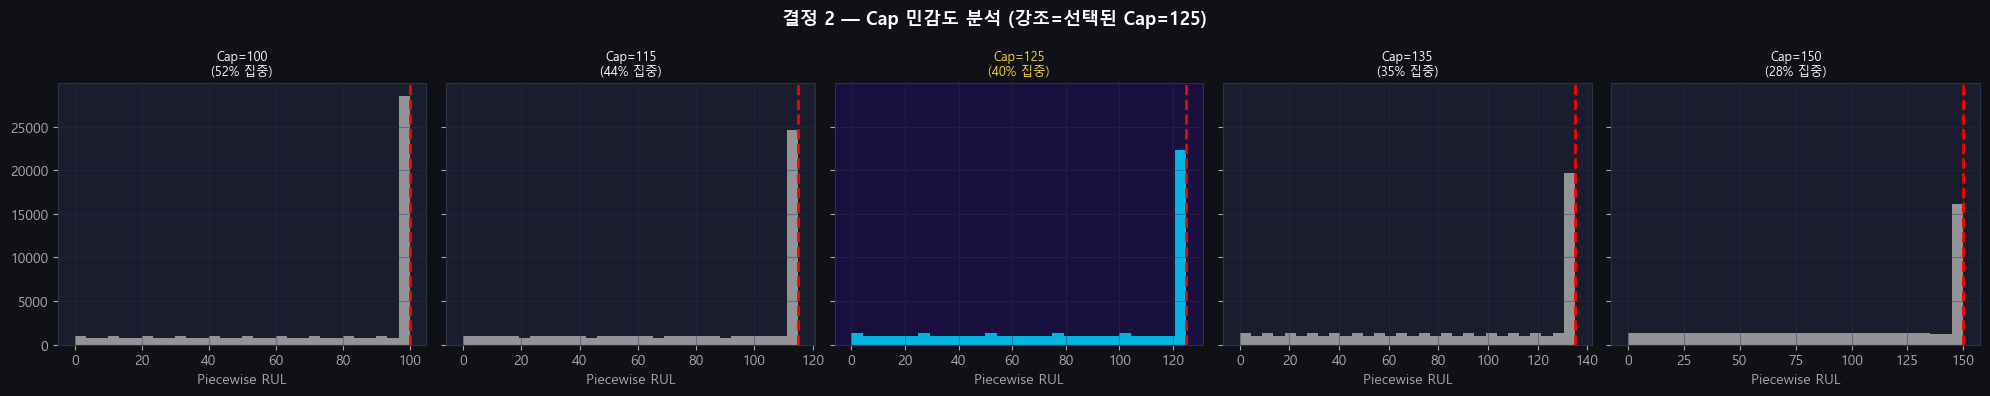

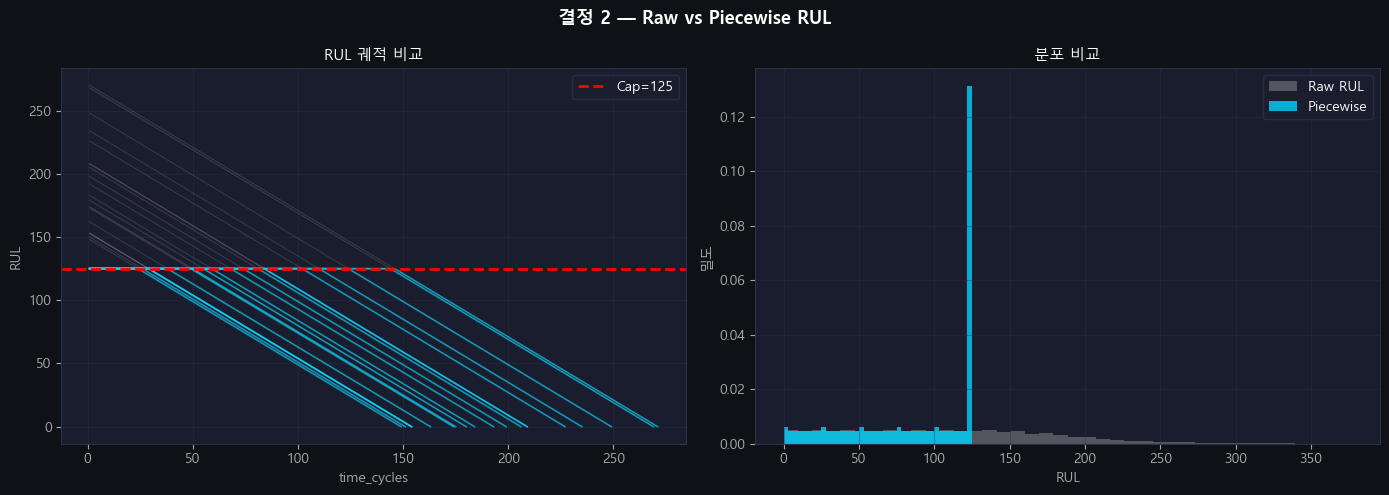

✅ 결정 2 완료  RUL Cap=125
   Raw RUL std=69.2 → Piecewise std=41.7


In [19]:
def add_piecewise_rul(df, cap=RUL_CAP):
    df = df.copy()
    mc = df.groupby('unit_nr')['time_cycles'].max().rename('max_c')
    df = df.join(mc, on='unit_nr')
    df['RUL_raw'] = df['max_c'] - df['time_cycles']
    df['RUL']     = df['RUL_raw'].clip(upper=cap)
    return df.drop('max_c', axis=1)

train_s2 = add_piecewise_rul(train_s1)
test_s2  = test_s1.copy()

# Cap 민감도 분석
caps = [100, 115, 125, 135, 150]
fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)
fig.suptitle('결정 2 — Cap 민감도 분석 (강조=선택된 Cap=125)', fontsize=13, fontweight='bold')

for ax, cap in zip(axes, caps):
    tmp = train_s2['RUL_raw'].clip(upper=cap)
    pct = (train_s2['RUL_raw']>=cap).mean()*100
    ax.hist(tmp, bins=30, color=C[0] if cap==RUL_CAP else GRAY, alpha=0.85, edgecolor='none')
    ax.axvline(cap, color='red', ls='--', lw=2)
    ax.set_title(f'Cap={cap}\n({pct:.0f}% 집중)',
                 color='#ffd43b' if cap==RUL_CAP else WHITE, fontsize=9)
    ax.set_xlabel('Piecewise RUL')
    if cap==RUL_CAP: ax.patch.set_facecolor('#1a1040')
plt.tight_layout(); plt.show()

# 전후 비교 (20개 엔진 궤적)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('결정 2 — Raw vs Piecewise RUL', fontsize=13, fontweight='bold')

ax = axes[0]
for u in train_s2['unit_nr'].unique()[:20]:
    sub = train_s2[train_s2['unit_nr']==u].sort_values('time_cycles')
    ax.plot(sub['time_cycles'], sub['RUL_raw'], color=GRAY,  alpha=0.2, lw=0.8)
    ax.plot(sub['time_cycles'], sub['RUL'],     color=C[0], alpha=0.6, lw=1.2)
ax.axhline(RUL_CAP, color='red', ls='--', lw=2, label=f'Cap={RUL_CAP}')
ax.set_xlabel('time_cycles'); ax.set_ylabel('RUL'); ax.set_title('RUL 궤적 비교'); ax.legend()

ax = axes[1]
ax.hist(train_s2['RUL_raw'], bins=40, alpha=0.4, color=GRAY,  density=True, label='Raw RUL')
ax.hist(train_s2['RUL'],     bins=40, alpha=0.8, color=C[0], density=True, label='Piecewise')
ax.set_xlabel('RUL'); ax.set_ylabel('밀도'); ax.set_title('분포 비교'); ax.legend()
plt.tight_layout(); plt.show()

print(f'✅ 결정 2 완료  RUL Cap={RUL_CAP}')
print(f'   Raw RUL std={train_s2["RUL_raw"].std():.1f} → Piecewise std={train_s2["RUL"].std():.1f}')

## 6. 결정 3 — 클러스터별 Gaussian 스무딩 (σ = 2)

> **FD001과 차이:** 전체 스무딩 → **클러스터별 스무딩**  
> 운전 조건이 섞인 채 스무딩하면 조건 전환 지점에서 인위적 평탄화가 발생함.  
> 같은 엔진 내에서도 클러스터(운전 조건) 단위로 따로 스무딩 적용.  
> **순서 변경:** val split 이전에 train 전체와 test 전체에 적용한 뒤 split을 진행.


In [ ]:
def apply_gaussian_by_cluster(df, features, sigma=GAUSS_SIGMA):
    """[벡터화] 엔진 × 클러스터 그룹별 Gaussian — groupby.transform"""
    df = df.copy().sort_values(['unit_nr', 'op_cluster', 'time_cycles']).reset_index(drop=True)
    grp = df.groupby(['unit_nr', 'op_cluster'])
    def _smooth(s: pd.Series):
        arr = s.values.astype(np.float32)
        if len(arr) > 1:
            return pd.Series(gaussian_filter1d(arr, sigma=sigma, mode='nearest'),
                             index=s.index)
        return s
    for s in features:
        df[s] = grp[s].transform(_smooth)
    return df

# val split 전에 train/test 전체에 적용
train_s3 = apply_gaussian_by_cluster(train_s2, USEFUL_SENSORS)
test_s3  = apply_gaussian_by_cluster(test_s2,  USEFUL_SENSORS)

# σ 민감도 비교 (엔진 #1, 대표 클러스터)
uid_ex = train_s2['unit_nr'].iloc[0]
c_ex   = train_s2[train_s2['unit_nr']==uid_ex]['op_cluster'].mode()[0]

# 클러스터 내 변동 있는 센서 자동 선택
_cluster_data = train_s2[train_s2['op_cluster']==c_ex]
varying = [s for s in USEFUL_SENSORS if _cluster_data[s].std() > 0.01]
s_ex = varying[0] if varying else USEFUL_SENSORS[0]

unit_sub = train_s2[(train_s2['unit_nr']==uid_ex) &
                    (train_s2['op_cluster']==c_ex)].sort_values('time_cycles')

sigmas = [0, 1, 2, 3, 5]
fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)
fig.suptitle(f'결정 3 — σ 민감도 ({s_ex}, 엔진#{uid_ex}, Cluster{c_ex})  강조=σ=2',
             fontsize=13, fontweight='bold')
for ax, sig in zip(axes, sigmas):
    y_raw = unit_sub[s_ex].values
    y_f   = gaussian_filter1d(y_raw, sigma=sig, mode='nearest') if sig>0 else y_raw
    noise = np.std(np.diff(y_f)) if len(y_f) > 1 else 0
    ax.plot(unit_sub['time_cycles'], y_raw, color=GRAY, alpha=0.5, lw=0.8)
    ax.plot(unit_sub['time_cycles'], y_f, color=C[0] if sig==GAUSS_SIGMA else C[3], lw=2)
    ax.set_title(f'σ={sig}\n노이즈={noise:.4f}',
                 color='#ffd43b' if sig==GAUSS_SIGMA else WHITE, fontsize=9)
    if sig==GAUSS_SIGMA: ax.patch.set_facecolor('#1a1040')
    ax.set_xlabel('time_cycles')
plt.tight_layout(); plt.show()
print(f'✅ 결정 3 완료  (클러스터별 Gaussian σ={GAUSS_SIGMA})')


## 7. 결정 4 — Validation 분할 (엔진 단위 단순 random)

> 엔진 단위 random split  (`random_state=42`, 8:2)  
> 누수 방지: 동일 엔진의 행이 sub-train ↔ val 사이에 절대 섞이지 않도록 unit_nr 기준 분리.


=== 결정 4 — 엔진 단위 random Validation 분할 완료 ===
  전체 엔진   : 260대
  Sub-train  : 208대
  Validation : 52대
  겹치는 엔진: 0대  ✅


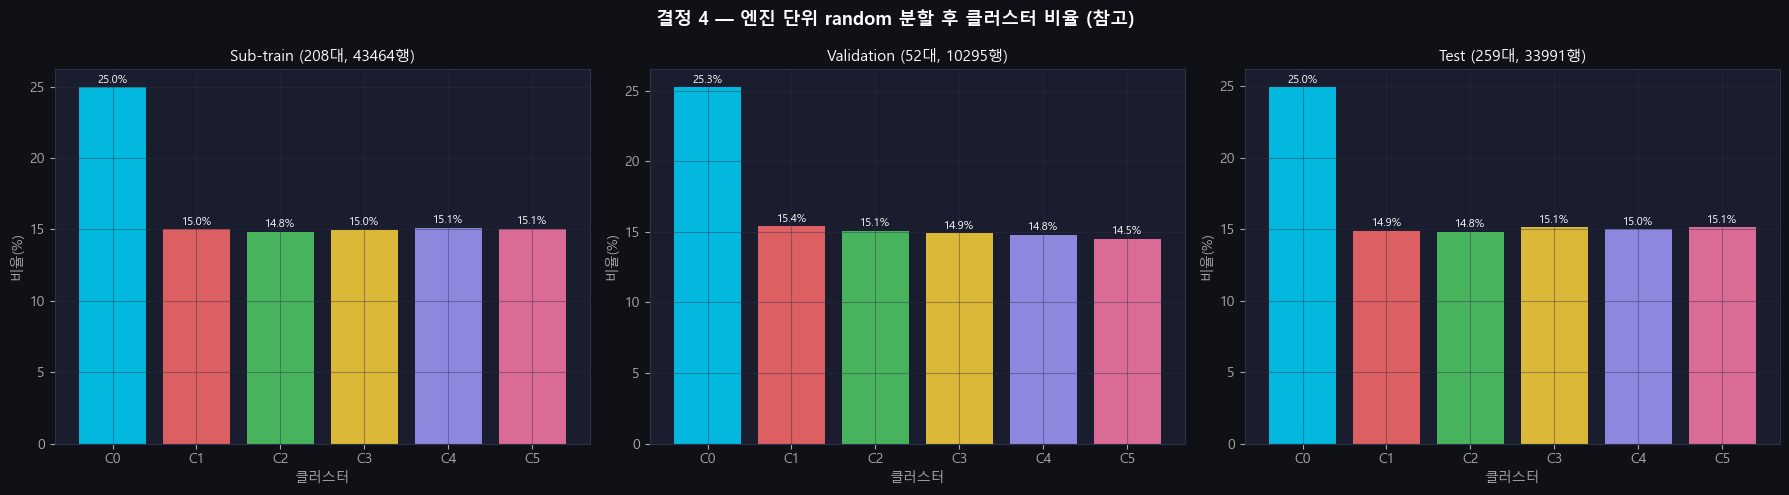

,구분,행 수,엔진 수,클러스터 수,RUL 포함
0,Sub-train,43464,208,6,예
1,Validation,10295,52,6,예
2,Test,33991,259,6,아니오


💾 분할 정보 저장: FD002_split_units_random42.json


In [22]:
VALID_RATIO  = 0.2
RANDOM_STATE = 42

# 엔진 단위 단순 random split (stratify 없음)
all_units = train_s3['unit_nr'].unique()
subtrain_units, valid_units = train_test_split(
    all_units,
    test_size=VALID_RATIO,
    random_state=RANDOM_STATE,
)

subtrain_common = train_s3[train_s3['unit_nr'].isin(subtrain_units)].copy().reset_index(drop=True)
valid_common    = train_s3[train_s3['unit_nr'].isin(valid_units)].copy().reset_index(drop=True)
test_common     = test_s3.copy()

# 누수 방지 검증
overlap = set(subtrain_units).intersection(set(valid_units))
assert len(overlap) == 0, f'❌ 엔진 겹침: {sorted(overlap)[:5]}'
assert len(subtrain_units) + len(valid_units) == len(all_units), '❌ 엔진 수 합 불일치'

print('=== 결정 4 — 엔진 단위 random Validation 분할 완료 ===')
print(f'  전체 엔진   : {len(all_units)}대')
print(f'  Sub-train  : {len(subtrain_units)}대')
print(f'  Validation : {len(valid_units)}대')
print(f'  겹치는 엔진: {len(overlap)}대  ✅')

# 분할 후 클러스터 비율 확인 (참고용)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('결정 4 — 엔진 단위 random 분할 후 클러스터 비율 (참고)', fontsize=13, fontweight='bold')

for ax, (df, title) in zip(axes, [
    (subtrain_common, 'Sub-train'),
    (valid_common,    'Validation'),
    (test_common,     'Test')
]):
    cnts = df['op_cluster'].value_counts().sort_index()
    pcts = cnts / cnts.sum() * 100
    ax.bar(pcts.index, pcts.values,
           color=[CLUSTER_COLORS[i] for i in pcts.index], alpha=0.85)
    ax.set_title(f'{title} ({df["unit_nr"].nunique()}대, {len(df)}행)')
    ax.set_xlabel('클러스터'); ax.set_ylabel('비율(%)')
    ax.set_xticks(range(N_CLUSTERS))
    ax.set_xticklabels([f'C{i}' for i in range(N_CLUSTERS)])
    for idx_c, v in pcts.items():
        ax.text(idx_c, v+0.3, f'{v:.1f}%', ha='center', fontsize=8)

plt.tight_layout(); plt.show()

# 분할 요약
split_summary = pd.DataFrame({
    '구분':      ['Sub-train', 'Validation', 'Test'],
    '행 수':     [len(subtrain_common), len(valid_common), len(test_common)],
    '엔진 수':   [subtrain_common['unit_nr'].nunique(),
                  valid_common['unit_nr'].nunique(),
                  test_common['unit_nr'].nunique()],
    '클러스터 수': [subtrain_common['op_cluster'].nunique(),
                    valid_common['op_cluster'].nunique(),
                    test_common['op_cluster'].nunique()],
    'RUL 포함':  ['예', '예', '아니오'],
})
display(split_summary)

split_info = {
    'random_state':   RANDOM_STATE,
    'valid_ratio':    VALID_RATIO,
    'split_method':   'engine-wise random (no stratify)',
    'subtrain_units': subtrain_units.tolist(),
    'valid_units':    valid_units.tolist(),
}
with open('FD002_split_units_random42.json', 'w', encoding='utf-8') as f:
    json.dump(split_info, f, ensure_ascii=False, indent=2)
print('💾 분할 정보 저장: FD002_split_units_random42.json')


## 8. 결정 5 — 클러스터별 MinMax 정규화

> **FD001과 가장 큰 차이:** 전체 MinMax → **클러스터별 MinMax**  
> 운전 조건별로 센서 스케일이 달라 동일 scaler 사용 시 정보 손실 발생.  
> fit은 **sub-train 클러스터별**로만, valid·test는 동일 scaler로 transform.

✅ 클러스터별 scaler 저장: FD002_scalers_by_cluster.pkl


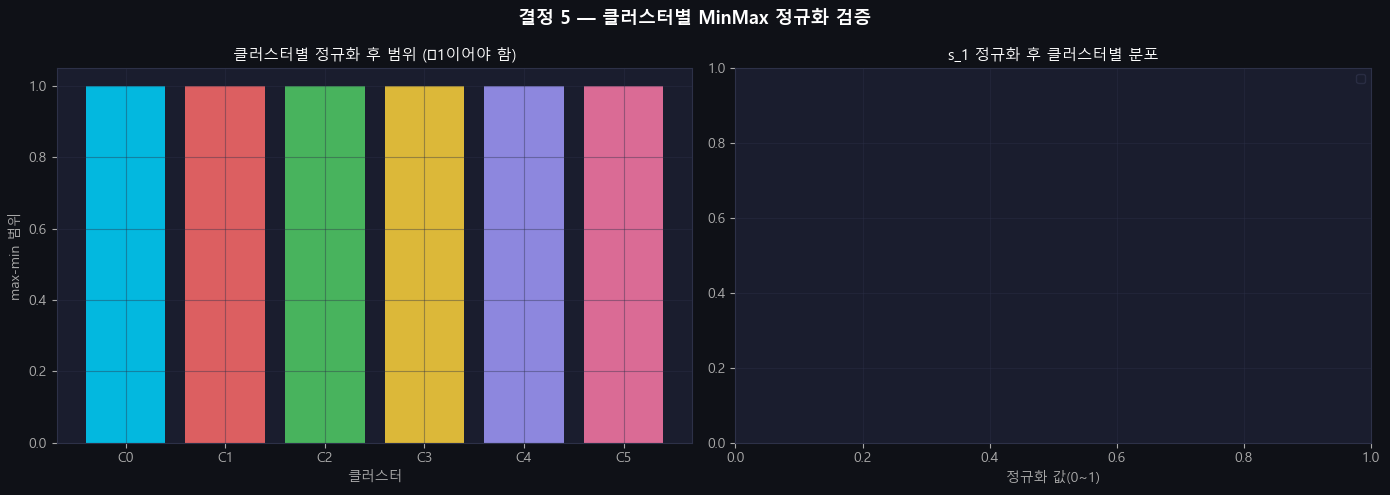

,클러스터,min,max,mean
0,C0,0.0,1.0,0.305289
1,C1,0.0,1.0,0.336114
2,C2,0.0,1.0,0.350074
3,C3,0.0,1.0,0.352207
4,C4,0.0,1.0,0.379756
5,C5,0.0,1.0,0.290791



✅ 결정 5 완료  클러스터별 MinMax 정규화 (6개 scaler 저장)


In [23]:
import joblib

scalers = {}  # {cluster_id: MinMaxScaler}

subtrain_s4 = subtrain_common.copy()
valid_s4    = valid_common.copy()
test_s4     = test_common.copy()

# fit: sub-train 클러스터별
for c in range(N_CLUSTERS):
    mask = subtrain_s4['op_cluster'] == c
    if mask.sum() == 0:
        print(f'⚠️ 클러스터 {c}: sub-train 샘플 없음 — 전체 sub-train scaler 사용')
        scaler_c = MinMaxScaler()
        scaler_c.fit(subtrain_s4[USEFUL_SENSORS])
    else:
        scaler_c = MinMaxScaler()
        subtrain_s4.loc[mask, USEFUL_SENSORS] = scaler_c.fit_transform(
            subtrain_s4.loc[mask, USEFUL_SENSORS])
    scalers[c] = scaler_c

# transform: valid, test
for df_name, df_target in [('valid', valid_s4), ('test', test_s4)]:
    for c in range(N_CLUSTERS):
        mask = df_target['op_cluster'] == c
        if mask.sum() > 0:
            df_target.loc[mask, USEFUL_SENSORS] = scalers[c].transform(
                df_target.loc[mask, USEFUL_SENSORS])

joblib.dump(scalers, 'FD002_scalers_by_cluster.pkl')
print('✅ 클러스터별 scaler 저장: FD002_scalers_by_cluster.pkl')

# 정규화 검증
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('결정 5 — 클러스터별 MinMax 정규화 검증', fontsize=13, fontweight='bold')

range_data = []
for c in range(N_CLUSTERS):
    mask = subtrain_s4['op_cluster'] == c
    sub  = subtrain_s4.loc[mask, USEFUL_SENSORS]
    range_data.append({'클러스터': f'C{c}', 'min': sub.min().min(), 'max': sub.max().max(),
                       'mean': sub.mean().mean()})
range_df = pd.DataFrame(range_data)

axes[0].bar(range_df['클러스터'], range_df['max'] - range_df['min'],
            color=[CLUSTER_COLORS[i] for i in range(N_CLUSTERS)], alpha=0.85)
axes[0].set_xlabel('클러스터'); axes[0].set_ylabel('max-min 범위')
axes[0].set_title('클러스터별 정규화 후 범위 (≈1이어야 함)')

# 전후 분포 비교 (대표 센서)
s_show = USEFUL_SENSORS[0]
for c in range(N_CLUSTERS):
    mask = subtrain_s4['op_cluster'] == c
    data = subtrain_s4.loc[mask, s_show]
    if len(data) > 1:
        try: data.plot.kde(ax=axes[1], color=CLUSTER_COLORS[c], lw=1.5, label=f'C{c}')
        except: pass
axes[1].set_title(f'{s_show} 정규화 후 클러스터별 분포')
axes[1].set_xlabel('정규화 값(0~1)'); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

display(range_df)
print(f'\n✅ 결정 5 완료  클러스터별 MinMax 정규화 (6개 scaler 저장)')

---
## 9. ML 분기 — 시계열 파생변수 생성 [엔진×클러스터 단위]

> **FD001과 차이:** lag/rolling을 엔진 단위 계산 → **엔진×클러스터 단위** 계산  
> 운전 조건이 혼재한 상태에서 lag를 계산하면 다른 조건의 값이 섞여 들어감.

In [ ]:
def add_temporal_features_by_cluster(df, sensor_cols,
                                      lags, diffs, rolls, roll_stds, emas):
    """엔진×클러스터 단위 시계열 파생변수 생성"""
    df = df.sort_values(['unit_nr', 'op_cluster', 'time_cycles']).copy()

    for s in sensor_cols:
        grp = df.groupby(['unit_nr', 'op_cluster'])[s]

        for lag in lags:
            df[f'{s}_lag{lag}'] = grp.shift(lag)

        for d in diffs:
            df[f'{s}_diff{d}'] = grp.diff(d)

        for r in rolls:
            df[f'{s}_roll{r}'] = grp.transform(
                lambda x: x.rolling(r, min_periods=1).mean())

        for r in roll_stds:
            df[f'{s}_rollstd{r}'] = grp.transform(
                lambda x: x.rolling(r, min_periods=1).std().fillna(0))

        for span in emas:
            df[f'{s}_ema{span}'] = grp.transform(
                lambda x: x.ewm(span=span, adjust=False).mean())

    # [수정] 시작 cycle은 lag/diff가 NaN — 0 대신 'is_warmup' 마스크 + ffill
    warmup_steps = max(max(lags) if lags else 0,
                       max(diffs) if diffs else 0,
                       max(rolls) if rolls else 0)
    df['is_warmup'] = (df.groupby(['unit_nr','op_cluster']).cumcount() < warmup_steps).astype(np.int8)
    # NaN이 남은 lag/diff 컬럼은 그룹 내 평균으로 채움 (정규화 후 mid값 ≈ 0.5)
    derived = [c for c in df.columns if any(c.endswith(t) for t in ['_lag','_diff','_roll','_ema','_rollstd'])
               or '_lag' in c or '_diff' in c or '_roll' in c or '_ema' in c]
    derived = [c for c in df.columns if c not in (sensor_cols + ['unit_nr','time_cycles',
               'setting_1','setting_2','setting_3','op_cluster','RUL','RUL_raw','is_warmup'])]
    df[derived] = df[derived].fillna(df.groupby(['unit_nr','op_cluster'])[derived].transform('mean'))
    df = df.fillna(0)  # 그룹 평균도 NaN인 극단 케이스만 0
    return df

# 파생변수 생성
subtrain_ml_raw = add_temporal_features_by_cluster(
    subtrain_s4, USEFUL_SENSORS,
    TEMPORAL_LAGS, TEMPORAL_DIFFS, TEMPORAL_ROLLS, TEMPORAL_ROLL_STDS, TEMPORAL_EMAS)
valid_ml_raw    = add_temporal_features_by_cluster(
    valid_s4, USEFUL_SENSORS,
    TEMPORAL_LAGS, TEMPORAL_DIFFS, TEMPORAL_ROLLS, TEMPORAL_ROLL_STDS, TEMPORAL_EMAS)
test_ml_raw     = add_temporal_features_by_cluster(
    test_s4, USEFUL_SENSORS,
    TEMPORAL_LAGS, TEMPORAL_DIFFS, TEMPORAL_ROLLS, TEMPORAL_ROLL_STDS, TEMPORAL_EMAS)

# ML 피처 목록 (ID·OP·클러스터·RUL 제외)
EXCLUDE = set(ID_COLS + OP_COLS + ['op_cluster', 'RUL', 'RUL_raw'])
ML_FEATURES = [c for c in subtrain_ml_raw.columns if c not in EXCLUDE]

subtrain_ml = subtrain_ml_raw[ID_COLS + ['op_cluster'] + ML_FEATURES + ['RUL']].copy()
valid_ml    = valid_ml_raw[   ID_COLS + ['op_cluster'] + ML_FEATURES + ['RUL']].copy()
test_ml     = test_ml_raw[    ID_COLS + ['op_cluster'] + ML_FEATURES].copy()

print(f'✅ ML 파생변수 생성 완료')
print(f'   원본 센서: {len(USEFUL_SENSORS)}개 → ML 피처: {len(ML_FEATURES)}개')
print(f'   Sub-train: {subtrain_ml.shape}  |  Valid: {valid_ml.shape}  |  Test: {test_ml.shape}')

# 파생변수 유형 요약
feat_types = {
    '원본 센서': USEFUL_SENSORS,
    f'Lag ({TEMPORAL_LAGS})': [f'{s}_lag{l}' for s in USEFUL_SENSORS for l in TEMPORAL_LAGS],
    f'Diff ({TEMPORAL_DIFFS})': [f'{s}_diff{d}' for s in USEFUL_SENSORS for d in TEMPORAL_DIFFS],
    f'Rolling Mean ({TEMPORAL_ROLLS})': [f'{s}_roll{r}' for s in USEFUL_SENSORS for r in TEMPORAL_ROLLS],
    f'Rolling Std ({TEMPORAL_ROLL_STDS})': [f'{s}_rollstd{r}' for s in USEFUL_SENSORS for r in TEMPORAL_ROLL_STDS],
    f'EMA ({TEMPORAL_EMAS})': [f'{s}_ema{e}' for s in USEFUL_SENSORS for e in TEMPORAL_EMAS],
}
print('\n파생변수 구성:')
for name, feats in feat_types.items():
    actual = [f for f in feats if f in ML_FEATURES]
    print(f'  {name}: {len(actual)}개')

### 9-2. op_cluster 원핫인코딩 [FD002 전용]

> **why:** `op_cluster`가 정수(0~5)로 그대로 모델에 들어가면  
> 모델이 "클러스터 4 > 클러스터 2" 처럼 **존재하지 않는 순서 관계**를 학습함.  
> 운전 조건 간에는 대소 관계가 없으므로 반드시 원핫인코딩 필요.
>
> **ML 분기:** `cluster_0` ~ `cluster_5` 6개 컬럼을 ML_FEATURES에 추가  
> **DL 분기:** 윈도우 피처 끝에 클러스터 채널을 직접 concat (방법 1, 단순·효과적)

=== 원핫인코딩 완료 ===
추가된 OHE 컬럼: ['cluster_0', 'cluster_1', 'cluster_2', 'cluster_3', 'cluster_4', 'cluster_5']
ML_FEATURES: 200개 → 206개
Sub-train shape: (43464, 210)



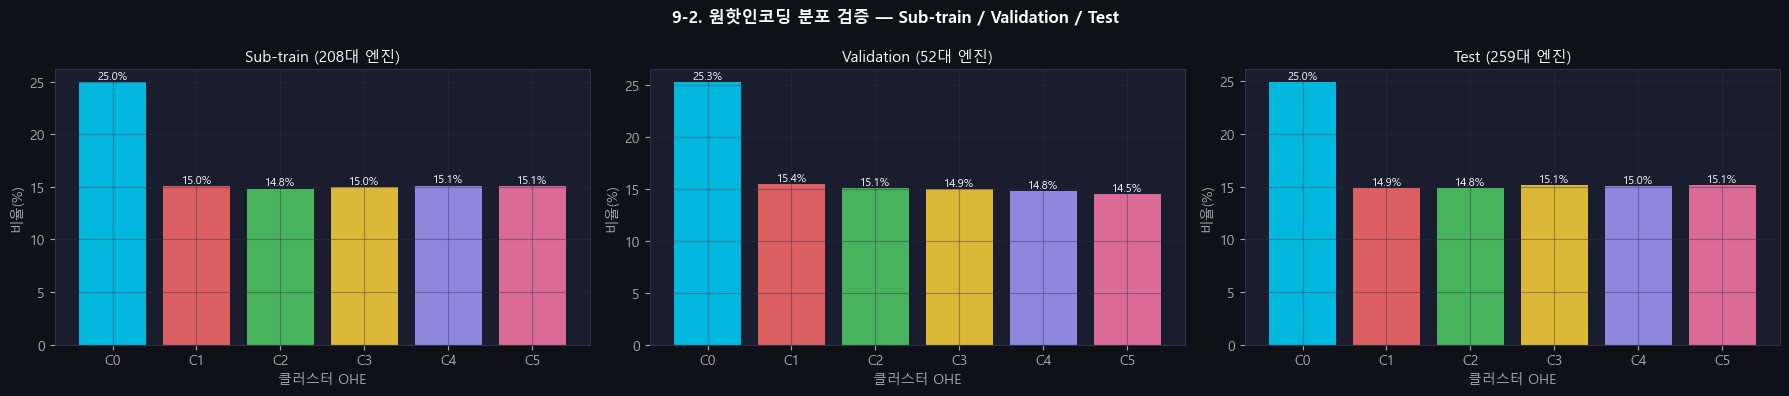

Sub-train OHE 정합성: ✅ 모든 행 합=1
Validation OHE 정합성: ✅ 모든 행 합=1
Test OHE 정합성: ✅ 모든 행 합=1



,unit_nr,time_cycles,op_cluster,cluster_0,cluster_1,cluster_2,cluster_3,cluster_4,cluster_5
0,1,2,0,1.0,0.0,0.0,0.0,0.0,0.0
1,1,4,0,1.0,0.0,0.0,0.0,0.0,0.0
2,1,7,0,1.0,0.0,0.0,0.0,0.0,0.0
3,1,9,0,1.0,0.0,0.0,0.0,0.0,0.0
4,1,10,0,1.0,0.0,0.0,0.0,0.0,0.0
5,1,11,0,1.0,0.0,0.0,0.0,0.0,0.0
6,1,14,0,1.0,0.0,0.0,0.0,0.0,0.0
7,1,19,0,1.0,0.0,0.0,0.0,0.0,0.0


📌 op_cluster 열은 참조용으로 남겨두고, 실제 모델 입력은 OHE 컬럼(cluster_0~5) 사용


In [25]:
# ── OHE 컬럼명 정의 ──────────────────────────────────────────────────────
OHE_COLS = [f'cluster_{i}' for i in range(N_CLUSTERS)]  # cluster_0 ~ cluster_5

def add_ohe_cluster(df, all_ohe_cols=OHE_COLS):
    """op_cluster → 원핫인코딩 후 기존 df에 concat"""
    ohe = pd.get_dummies(df['op_cluster'], prefix='cluster').astype(np.float32)
    # test 등에서 일부 클러스터가 없을 경우 0으로 보완
    for col in all_ohe_cols:
        if col not in ohe.columns:
            ohe[col] = np.float32(0.0)
    return pd.concat([df.reset_index(drop=True),
                      ohe[all_ohe_cols].reset_index(drop=True)], axis=1)

# ── ML 분기에 OHE 추가 ────────────────────────────────────────────────────
subtrain_ml = add_ohe_cluster(subtrain_ml)
valid_ml    = add_ohe_cluster(valid_ml)
test_ml     = add_ohe_cluster(test_ml)

# ML_FEATURES 업데이트
ML_FEATURES = ML_FEATURES + OHE_COLS

print('=== 원핫인코딩 완료 ===')
print(f'추가된 OHE 컬럼: {OHE_COLS}')
print(f'ML_FEATURES: {len(ML_FEATURES) - N_CLUSTERS}개 → {len(ML_FEATURES)}개')
print(f'Sub-train shape: {subtrain_ml.shape}')
print()

# ── OHE 분포 검증 ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle('9-2. 원핫인코딩 분포 검증 — Sub-train / Validation / Test',
             fontsize=12, fontweight='bold')

for ax, (df_name, df_chk) in zip(axes, [
    ('Sub-train', subtrain_ml),
    ('Validation', valid_ml),
    ('Test',       test_ml)
]):
    ohe_sums = df_chk[OHE_COLS].sum()
    pcts = ohe_sums / ohe_sums.sum() * 100
    bars = ax.bar(OHE_COLS, pcts.values,
                  color=[CLUSTER_COLORS[i] for i in range(N_CLUSTERS)], alpha=0.85)
    ax.set_title(f'{df_name} ({df_chk["unit_nr"].nunique()}대 엔진)')
    ax.set_xlabel('클러스터 OHE'); ax.set_ylabel('비율(%)')
    ax.set_xticks(range(N_CLUSTERS))
    ax.set_xticklabels([f'C{i}' for i in range(N_CLUSTERS)])
    for bar, v in zip(bars, pcts.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                f'{v:.1f}%', ha='center', fontsize=8)

plt.tight_layout(); plt.show()

# ── OHE 정합성 검증: 행마다 정확히 1개만 1이어야 함 ──────────────────────
for df_name, df_chk in [('Sub-train', subtrain_ml),
                         ('Validation', valid_ml),
                         ('Test', test_ml)]:
    row_sums = df_chk[OHE_COLS].sum(axis=1)
    ok = (row_sums == 1).all()
    print(f'{df_name} OHE 정합성: {"✅ 모든 행 합=1" if ok else "❌ 오류 발생"}')

print()
display(subtrain_ml[['unit_nr','time_cycles','op_cluster'] + OHE_COLS].head(8))
print('📌 op_cluster 열은 참조용으로 남겨두고, 실제 모델 입력은 OHE 컬럼(cluster_0~5) 사용')

## 10. DL 분기 — 슬라이딩 윈도우

In [ ]:
def create_sliding_windows(df, feature_cols, target_col=None,
                           window_size=WINDOW_SIZE, step=STEP):
    X_list, y_list = [], []
    for uid in np.sort(df['unit_nr'].unique()):
        udf  = df[df['unit_nr']==uid].sort_values('time_cycles')
        data = udf[feature_cols].values.astype(np.float32)
        tgt  = udf[target_col].values if target_col else None
        n    = len(data)
        for start in range(0, n - window_size + 1, step):
            end = start + window_size
            X_list.append(data[start:end])
            if tgt is not None:
                y_list.append(tgt[end-1])
    X = np.array(X_list, dtype=np.float32)
    y = np.array(y_list, dtype=np.float32) if y_list else None
    return X, y

def create_test_windows(df, feature_cols, rul_series, window_size=WINDOW_SIZE):
    X_list, y_list = [], []
    for i, uid in enumerate(np.sort(df['unit_nr'].unique())):
        udf  = df[df['unit_nr']==uid].sort_values('time_cycles')
        data = udf[feature_cols].values.astype(np.float32)
        if len(data) >= window_size:
            X_list.append(data[-window_size:])
        else:
            pad = np.zeros((window_size - len(data), len(feature_cols)), dtype=np.float32)
            X_list.append(np.vstack([pad, data]))
        y_list.append(float(rul_series.iloc[i]))
    return np.array(X_list, dtype=np.float32), np.array(y_list, dtype=np.float32)

def windows_to_long_df(X, y, feature_cols):
    """[벡터화] reshape 한 번으로 long format 생성 (수십 배 빠름)"""
    n_samples, win_size, n_feat = X.shape
    sample_id = np.repeat(np.arange(n_samples), win_size)
    timestep  = np.tile(np.arange(win_size), n_samples)
    flat = X.reshape(n_samples * win_size, n_feat)
    df = pd.DataFrame(flat, columns=list(feature_cols))
    df.insert(0, 'timestep', timestep)
    df.insert(0, 'sample_id', sample_id)
    df['RUL'] = np.repeat(np.asarray(y, dtype=np.float32), win_size)
    return df

print('✅ 슬라이딩 윈도우 함수 정의 완료')
print(f'   create_sliding_windows / create_test_windows / windows_to_long_df')

### 10-1. DL 피처에 OHE 추가 (클러스터 채널 concat)

> **방법 1 (단순·효과적):** 정규화된 센서 피처 끝에 `cluster_0~5` 채널을 직접 붙여  
> 윈도우 텐서를 `(N, window_size, n_sensors + 6)` 형태로 구성.  
> 모델이 타임스텝마다 운전 조건 정보를 함께 참조할 수 있음.

DL_FEATURES 구성:
  센서:    20개  → ['s_1', 's_2', 's_3', 's_4', 's_5', 's_6', 's_7', 's_8', 's_9', 's_10', 's_11', 's_12', 's_13', 's_14', 's_15', 's_17', 's_18', 's_19', 's_20', 's_21']
  OHE:     6개  → ['cluster_0', 'cluster_1', 'cluster_2', 'cluster_3', 'cluster_4', 'cluster_5']
  합계:    26개

=== [DL] 슬라이딩 윈도우 재생성 완료 (OHE 포함) ===
X_subtrain_dl : (37432, 30, 26)   ← (샘플, 30, 26채널)
X_valid_dl    : (8787, 30, 26)
X_test_dl     : (259, 30, 26)


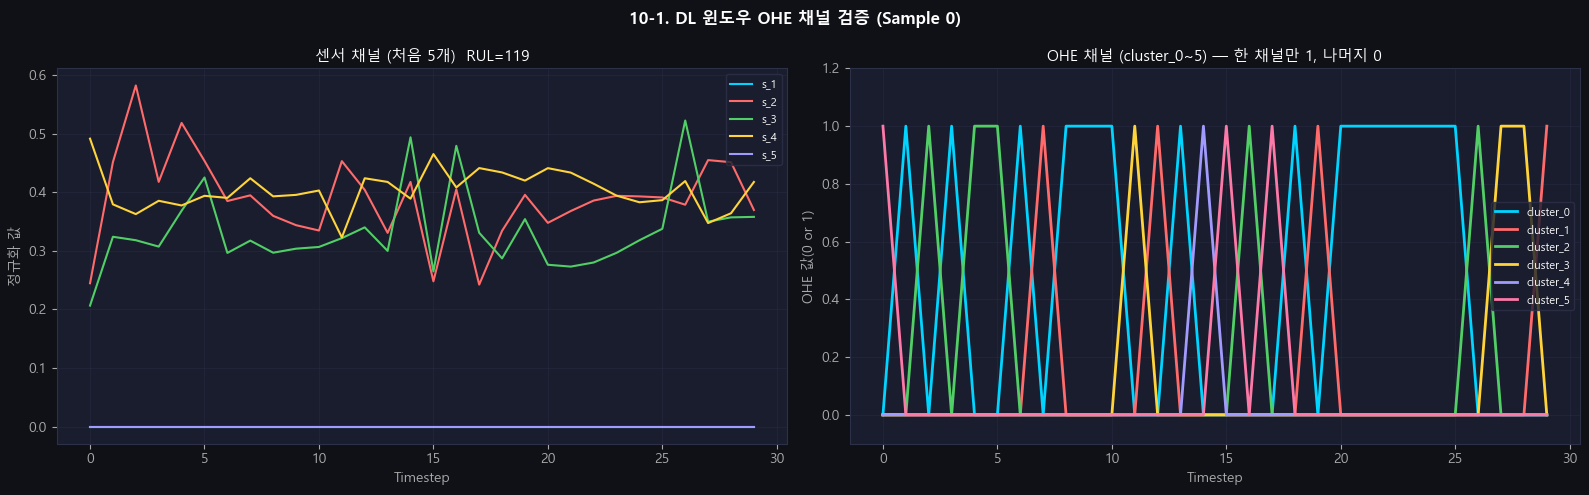


OHE 정합성 (모든 타임스텝 합=1): ✅
활성 클러스터: ['cluster_5']

Long Format shape:
  subtrain: (1122960, 29)
  valid   : (263610, 29)
  test    : (7770, 29)


In [28]:
# ── DL 피처: 센서 + OHE 클러스터 ────────────────────────────────────────
DL_FEATURES = USEFUL_SENSORS + OHE_COLS
# 예: 14개 센서 + 6개 OHE = 20개 채널

print(f'DL_FEATURES 구성:')
print(f'  센서:    {len(USEFUL_SENSORS)}개  → {USEFUL_SENSORS}')
print(f'  OHE:     {len(OHE_COLS)}개  → {OHE_COLS}')
print(f'  합계:    {len(DL_FEATURES)}개')
print()

# ── 슬라이딩 윈도우 재생성 (DL_FEATURES 업데이트 반영) ───────────────────
X_subtrain_dl, y_subtrain_dl = create_sliding_windows(subtrain_ml, DL_FEATURES, 'RUL')
X_valid_dl,    y_valid_dl    = create_sliding_windows(valid_ml,    DL_FEATURES, 'RUL')
X_test_dl,     y_test_dl     = create_test_windows(  test_ml,     DL_FEATURES, rul_df['RUL'])

print('=== [DL] 슬라이딩 윈도우 재생성 완료 (OHE 포함) ===')
print(f'X_subtrain_dl : {X_subtrain_dl.shape}   ← (샘플, {WINDOW_SIZE}, {len(DL_FEATURES)}채널)')
print(f'X_valid_dl    : {X_valid_dl.shape}')
print(f'X_test_dl     : {X_test_dl.shape}')

# ── OHE 채널 확인: 마지막 6채널이 0/1인지 검증 ───────────────────────────
sample_window = X_subtrain_dl[0]   # (window_size, n_features)
ohe_channels  = sample_window[:, len(USEFUL_SENSORS):]  # 마지막 6채널

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('10-1. DL 윈도우 OHE 채널 검증 (Sample 0)', fontsize=12, fontweight='bold')

# 센서 채널
ax = axes[0]
for fi in range(min(5, len(USEFUL_SENSORS))):
    ax.plot(sample_window[:, fi], color=C[fi], lw=1.5, label=USEFUL_SENSORS[fi])
ax.set_title(f'센서 채널 (처음 5개)  RUL={y_subtrain_dl[0]:.0f}')
ax.set_xlabel('Timestep'); ax.set_ylabel('정규화 값'); ax.legend(fontsize=8)

# OHE 채널
ax = axes[1]
for ci in range(N_CLUSTERS):
    ax.plot(ohe_channels[:, ci], color=CLUSTER_COLORS[ci],
            lw=2, label=f'cluster_{ci}')
ax.set_title('OHE 채널 (cluster_0~5) — 한 채널만 1, 나머지 0')
ax.set_xlabel('Timestep'); ax.set_ylabel('OHE 값(0 or 1)')
ax.set_ylim(-0.1, 1.2); ax.legend(fontsize=8)

plt.tight_layout(); plt.show()

# OHE 정합성: 각 타임스텝에서 OHE 합 = 1
ohe_rowsums = ohe_channels.sum(axis=1)
ok = np.all(ohe_rowsums == 1)
print(f'\nOHE 정합성 (모든 타임스텝 합=1): {"✅" if ok else "❌"}')
print(f'활성 클러스터: {[OHE_COLS[i] for i in np.where(ohe_channels[0] == 1)[0]]}')

# Long Format 재생성
dl_subtrain_long = windows_to_long_df(X_subtrain_dl, y_subtrain_dl, DL_FEATURES)
dl_valid_long    = windows_to_long_df(X_valid_dl,    y_valid_dl,    DL_FEATURES)
dl_test_long     = windows_to_long_df(X_test_dl,     y_test_dl,     DL_FEATURES)

print(f'\nLong Format shape:')
print(f'  subtrain: {dl_subtrain_long.shape}')
print(f'  valid   : {dl_valid_long.shape}')
print(f'  test    : {dl_test_long.shape}')

---
## 11. 전처리 후 검증

### 11-1. 센서 상관관계 전후 비교

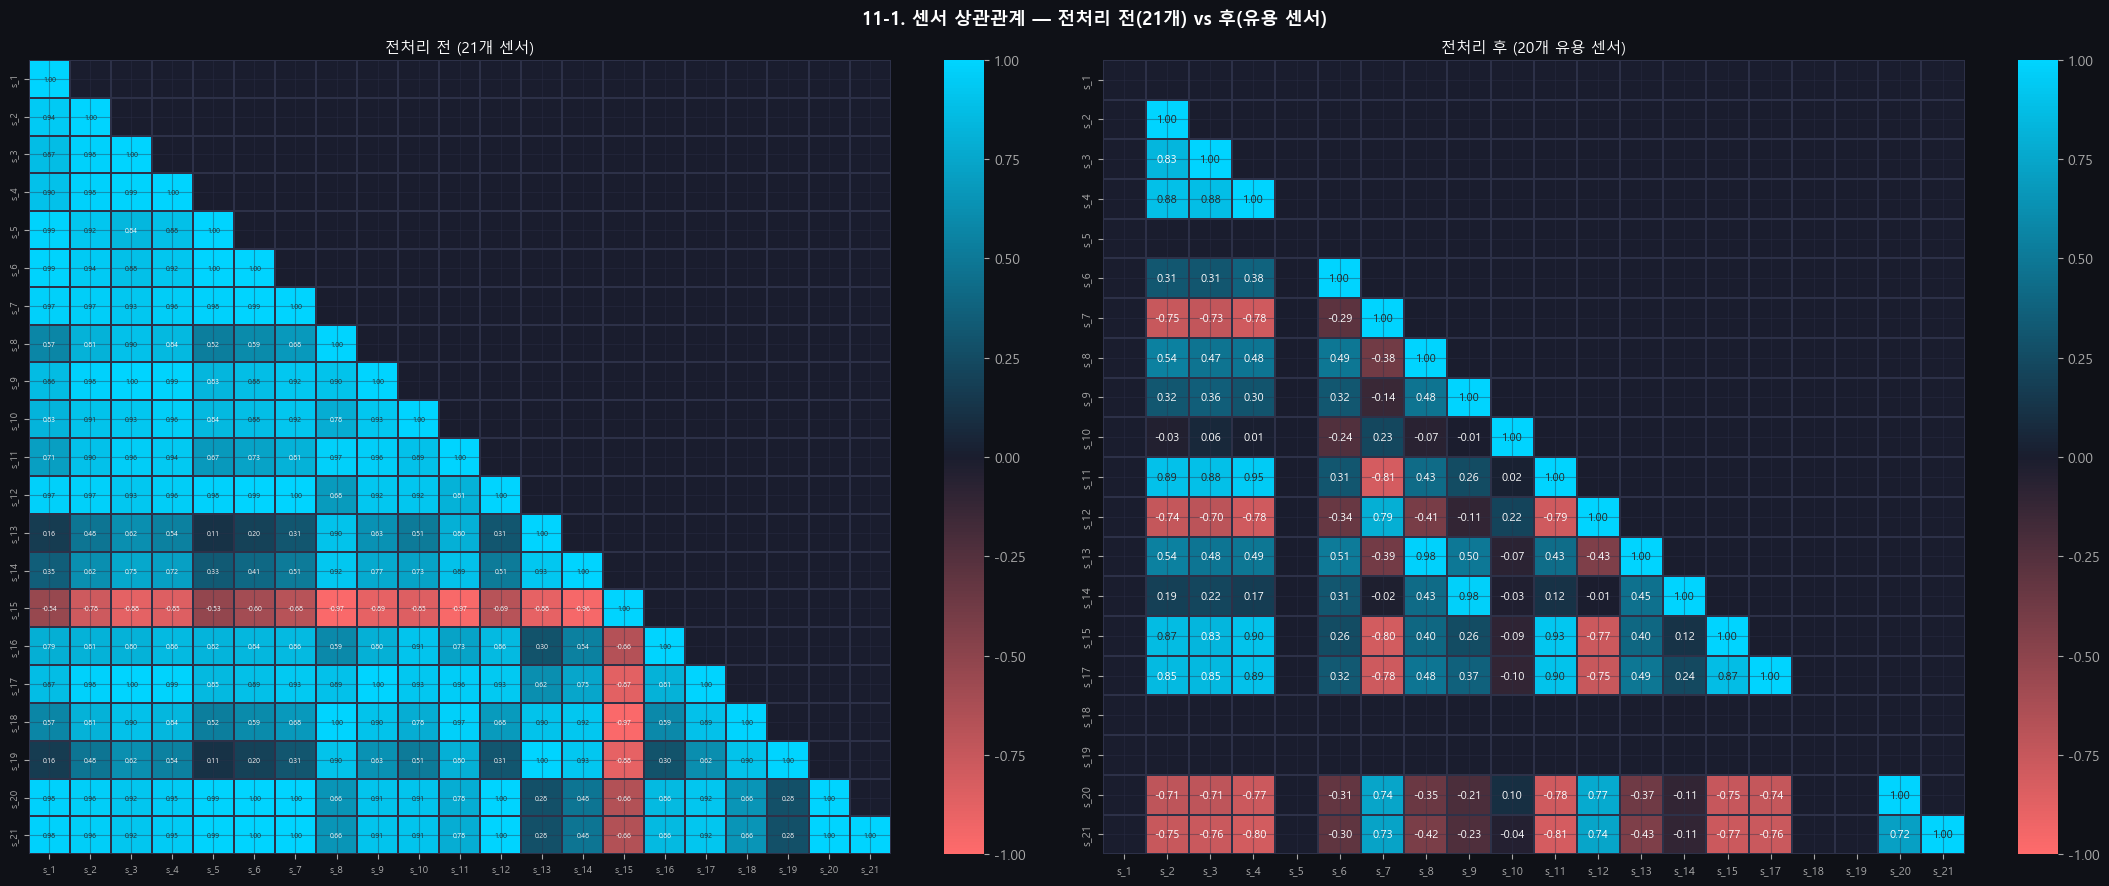

고상관 쌍(|r|>0.9): 전 87개 → 후 5개


In [29]:
corr_after = subtrain_s4[USEFUL_SENSORS].corr()

fig, axes = plt.subplots(1, 2, figsize=(22, 9))
fig.suptitle('11-1. 센서 상관관계 — 전처리 전(21개) vs 후(유용 센서)', fontsize=13, fontweight='bold')

mask_b = np.triu(np.ones_like(corr_before, dtype=bool), k=1)
sns.heatmap(corr_before, ax=axes[0], mask=mask_b, cmap=cmap_rg, center=0,
            vmin=-1, vmax=1, annot=True, fmt='.2f',
            annot_kws={'size': 5}, linewidths=0.3, linecolor=GRID)
axes[0].set_title(f'전처리 전 (21개 센서)', fontsize=11)
axes[0].tick_params(labelsize=7)

mask_a = np.triu(np.ones_like(corr_after, dtype=bool), k=1)
sns.heatmap(corr_after, ax=axes[1], mask=mask_a, cmap=cmap_rg, center=0,
            vmin=-1, vmax=1, annot=True, fmt='.2f',
            annot_kws={'size': 8}, linewidths=0.3, linecolor=GRID)
axes[1].set_title(f'전처리 후 ({len(USEFUL_SENSORS)}개 유용 센서)', fontsize=11)
axes[1].tick_params(labelsize=8)
plt.tight_layout(); plt.show()

pairs_after = [(USEFUL_SENSORS[i], USEFUL_SENSORS[j], round(corr_after.iloc[i,j],3))
               for i in range(len(USEFUL_SENSORS)) for j in range(i+1, len(USEFUL_SENSORS))
               if abs(corr_after.iloc[i,j]) > 0.9]
print(f'고상관 쌍(|r|>0.9): 전 {len(pairs)}개 → 후 {len(pairs_after)}개')

### 11-2. 센서 분포 전처리 전후 비교 (유용 센서 전체)

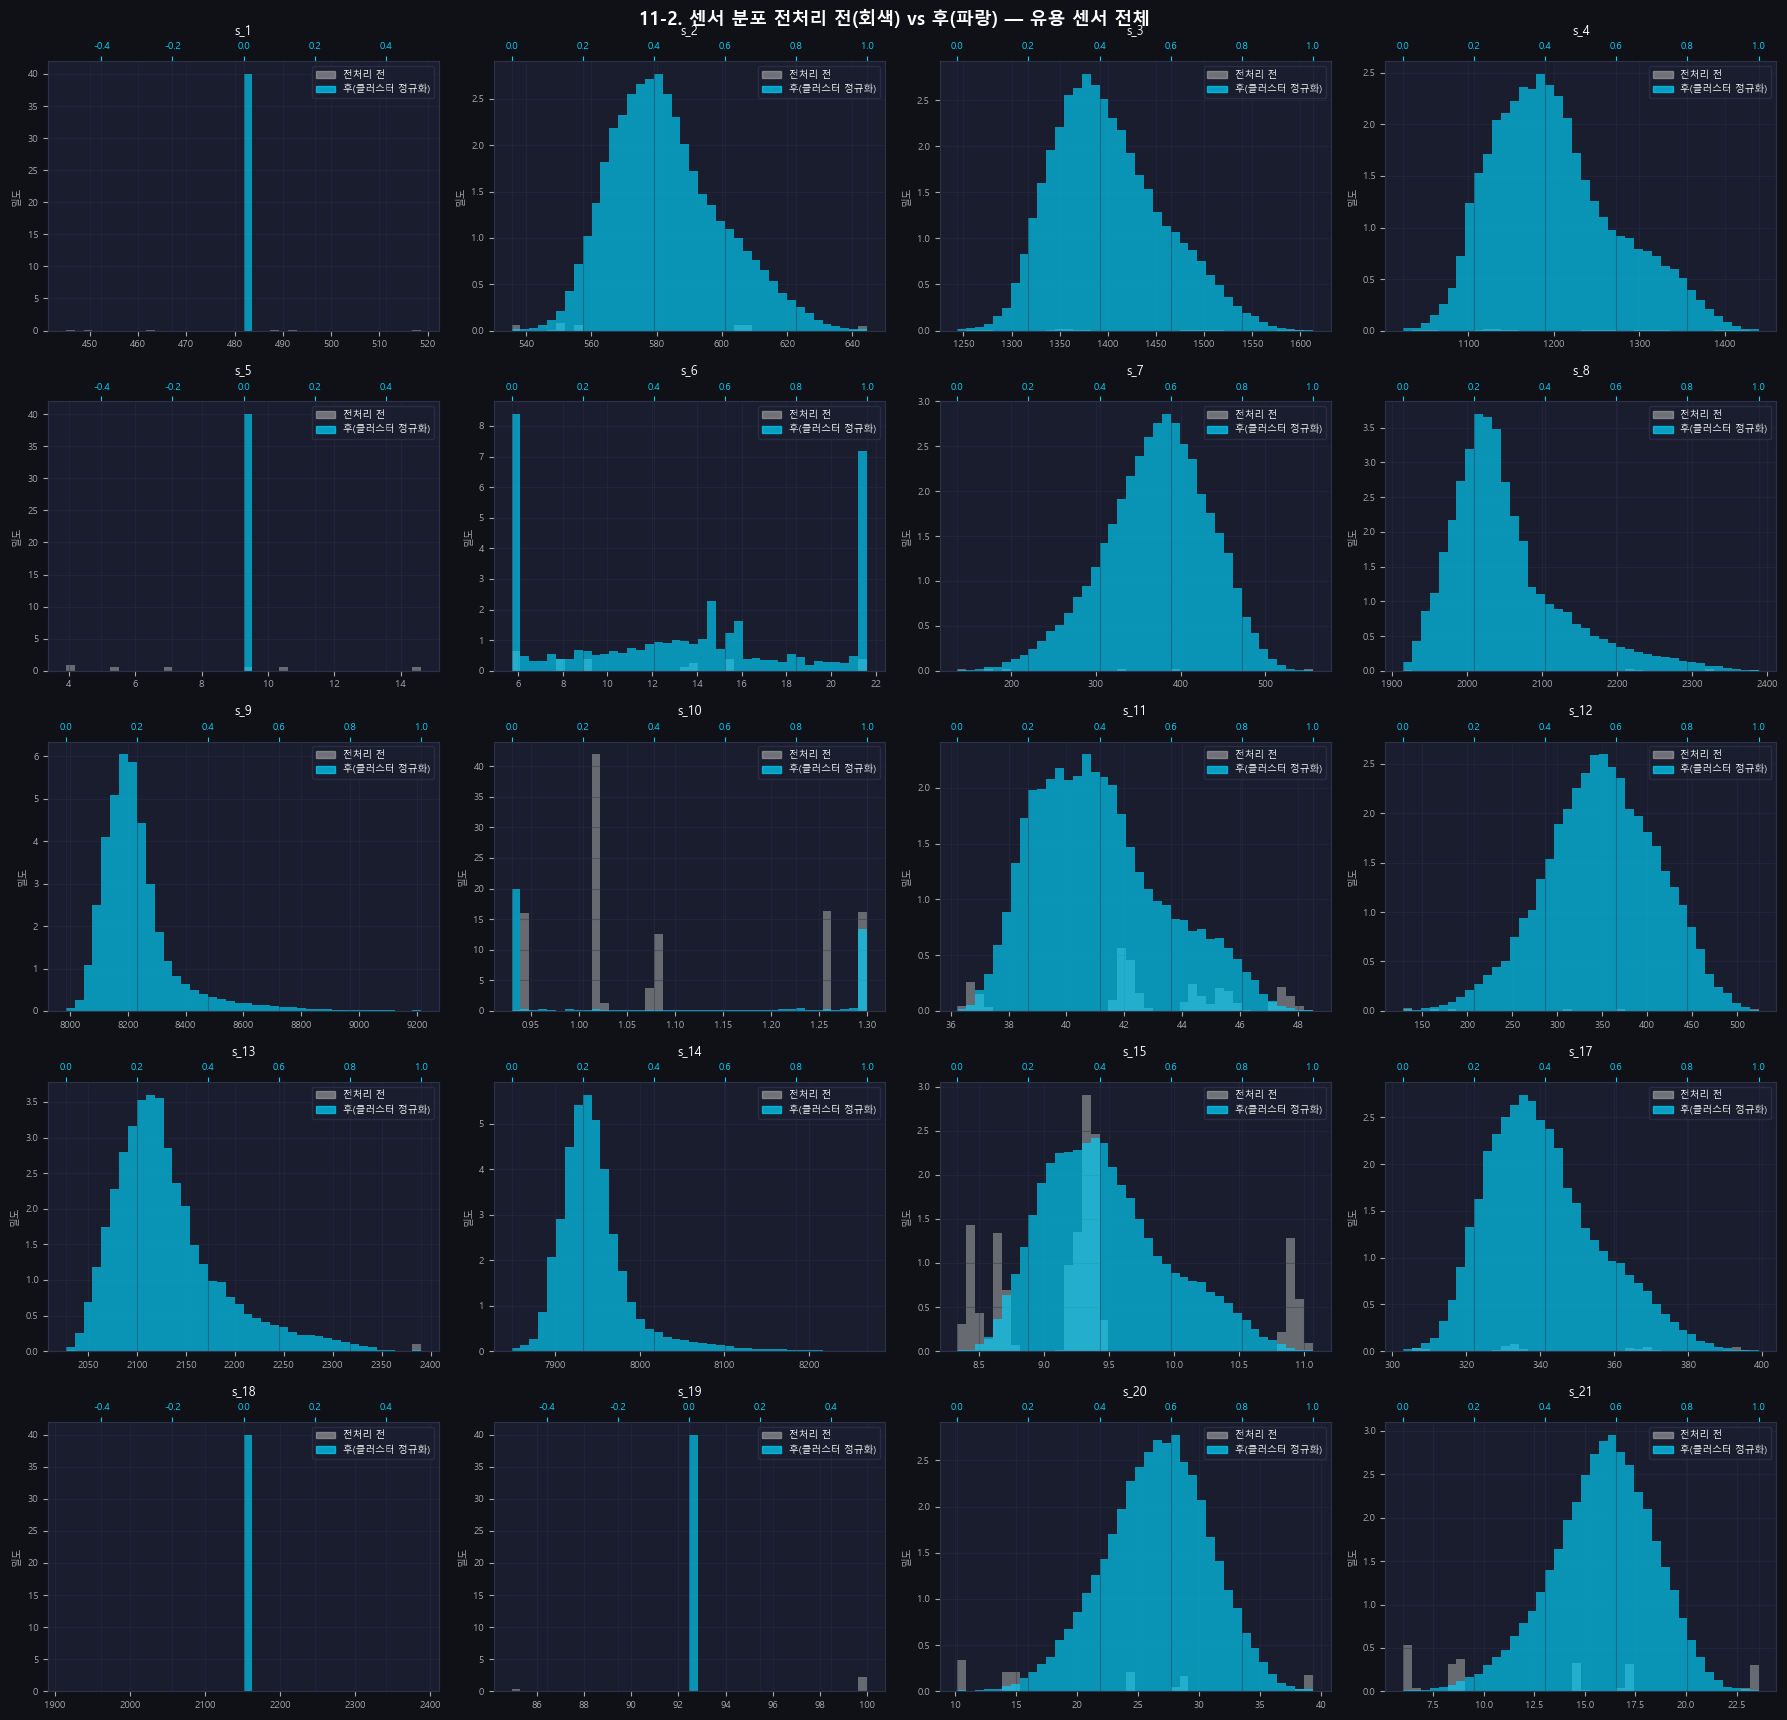

📌 회색=원본 스케일  파랑=클러스터별 MinMax 정규화 후 (0~1 범위)
📌 FD002: 운전 조건 6개 혼재로 인해 전처리 전 분포가 다봉(multimodal)으로 나타남
    → 클러스터별 정규화 후 각 조건이 분리되어 보다 균일한 분포로 변환됨


In [30]:
import matplotlib.patches as mpatches

n_cols = 4
n_rows = (len(USEFUL_SENSORS) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3.5))
fig.suptitle('11-2. 센서 분포 전처리 전(회색) vs 후(파랑) — 유용 센서 전체',
             fontsize=13, fontweight='bold')

for ax, s in zip(axes.flat, USEFUL_SENSORS):
    # 전처리 전: train_raw (원본 스케일)
    before_data = train_raw[s]
    # 전처리 후: subtrain_s4 (클러스터별 정규화 완료)
    after_data  = subtrain_s4[s]

    ax2 = ax.twiny()
    ax.hist(before_data,  bins=40, color=GRAY, alpha=0.55, density=True, edgecolor='none')
    ax2.hist(after_data,  bins=40, color=C[0], alpha=0.65, density=True, edgecolor='none')

    ax.set_title(f'{s}', fontsize=9)
    ax.set_ylabel('밀도', fontsize=7)
    ax.tick_params(labelsize=7)
    ax2.tick_params(labelsize=7, colors=C[0])

    handles = [mpatches.Patch(color=GRAY, alpha=0.6, label='전처리 전'),
               mpatches.Patch(color=C[0], alpha=0.7, label='후(클러스터 정규화)')]
    ax.legend(handles=handles, fontsize=7, loc='upper right')

for ax in axes.flat[len(USEFUL_SENSORS):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

print('📌 회색=원본 스케일  파랑=클러스터별 MinMax 정규화 후 (0~1 범위)')
print('📌 FD002: 운전 조건 6개 혼재로 인해 전처리 전 분포가 다봉(multimodal)으로 나타남')
print('    → 클러스터별 정규화 후 각 조건이 분리되어 보다 균일한 분포로 변환됨')

### 11-3. Train vs Test 분포 비교 (전처리 후, KS 검정)

In [ ]:
print('=== 11-3. Train vs Test 분포 비교 (KS 검정, 전처리 후) ===')
show6 = USEFUL_SENSORS[:6]; ks_rows = []
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('11-3. Train vs Test 분포 비교 (전처리 후)', fontsize=13, fontweight='bold')

for ax, s in zip(axes.flat, show6):
    tr_v = subtrain_s4[s].dropna(); te_v = test_s4[s].dropna()
    try: tr_v.plot.kde(ax=ax, color=C[0], lw=2.5, label='Sub-train')
    except: pass
    try: te_v.plot.kde(ax=ax, color=C[1], lw=2.5, ls='--', label='Test')
    except: pass
    ks_stat, ks_p = ks_2samp(tr_v, te_v)
    verdict = '✅ 유사' if ks_p>0.05 else '⚠️ 차이'
    ks_rows.append({'센서': s, 'KS통계량': round(ks_stat,4), 'p-value': round(ks_p,4), '판정': verdict})
    ax.set_title(f'{s}  KS={ks_stat:.3f}  {verdict}', fontsize=9)
    ax.set_xlabel('정규화 센서값'); ax.set_ylabel('밀도'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
ks_df_show = pd.DataFrame(ks_rows).set_index('센서')
# [추가] 전체 USEFUL_SENSORS에 대해 KS+FDR (시각화는 6개만)
_all_ks = []
for s in USEFUL_SENSORS:
    _ks, _kp = ks_2samp(subtrain_s4[s].dropna(), test_s4[s].dropna())
    _all_ks.append({'센서': s, 'KS': round(_ks,4), 'p': round(_kp,4)})
_ks_full = pd.DataFrame(_all_ks).set_index('센서')
from statsmodels.stats.multitest import multipletests
_rej, _padj, *_ = multipletests(_ks_full['p'].values, alpha=0.05, method='fdr_bh')
_ks_full['p_adj_BH'] = np.round(_padj, 4)
_ks_full['판정_BH']  = ['차이(FDR) ⚠️' if r else '유사(FDR) ✅' for r in _rej]
print('\n[전체 센서 KS + BH-FDR]')
display(_ks_full)
display(ks_df_show)
print('📌 FD002: 운전 조건 혼재 설계로 인해 Train/Test 분포 차이가 클 수 있음')

### 11-4. 클러스터별 RUL 상관계수 비교 [FD002 전용]

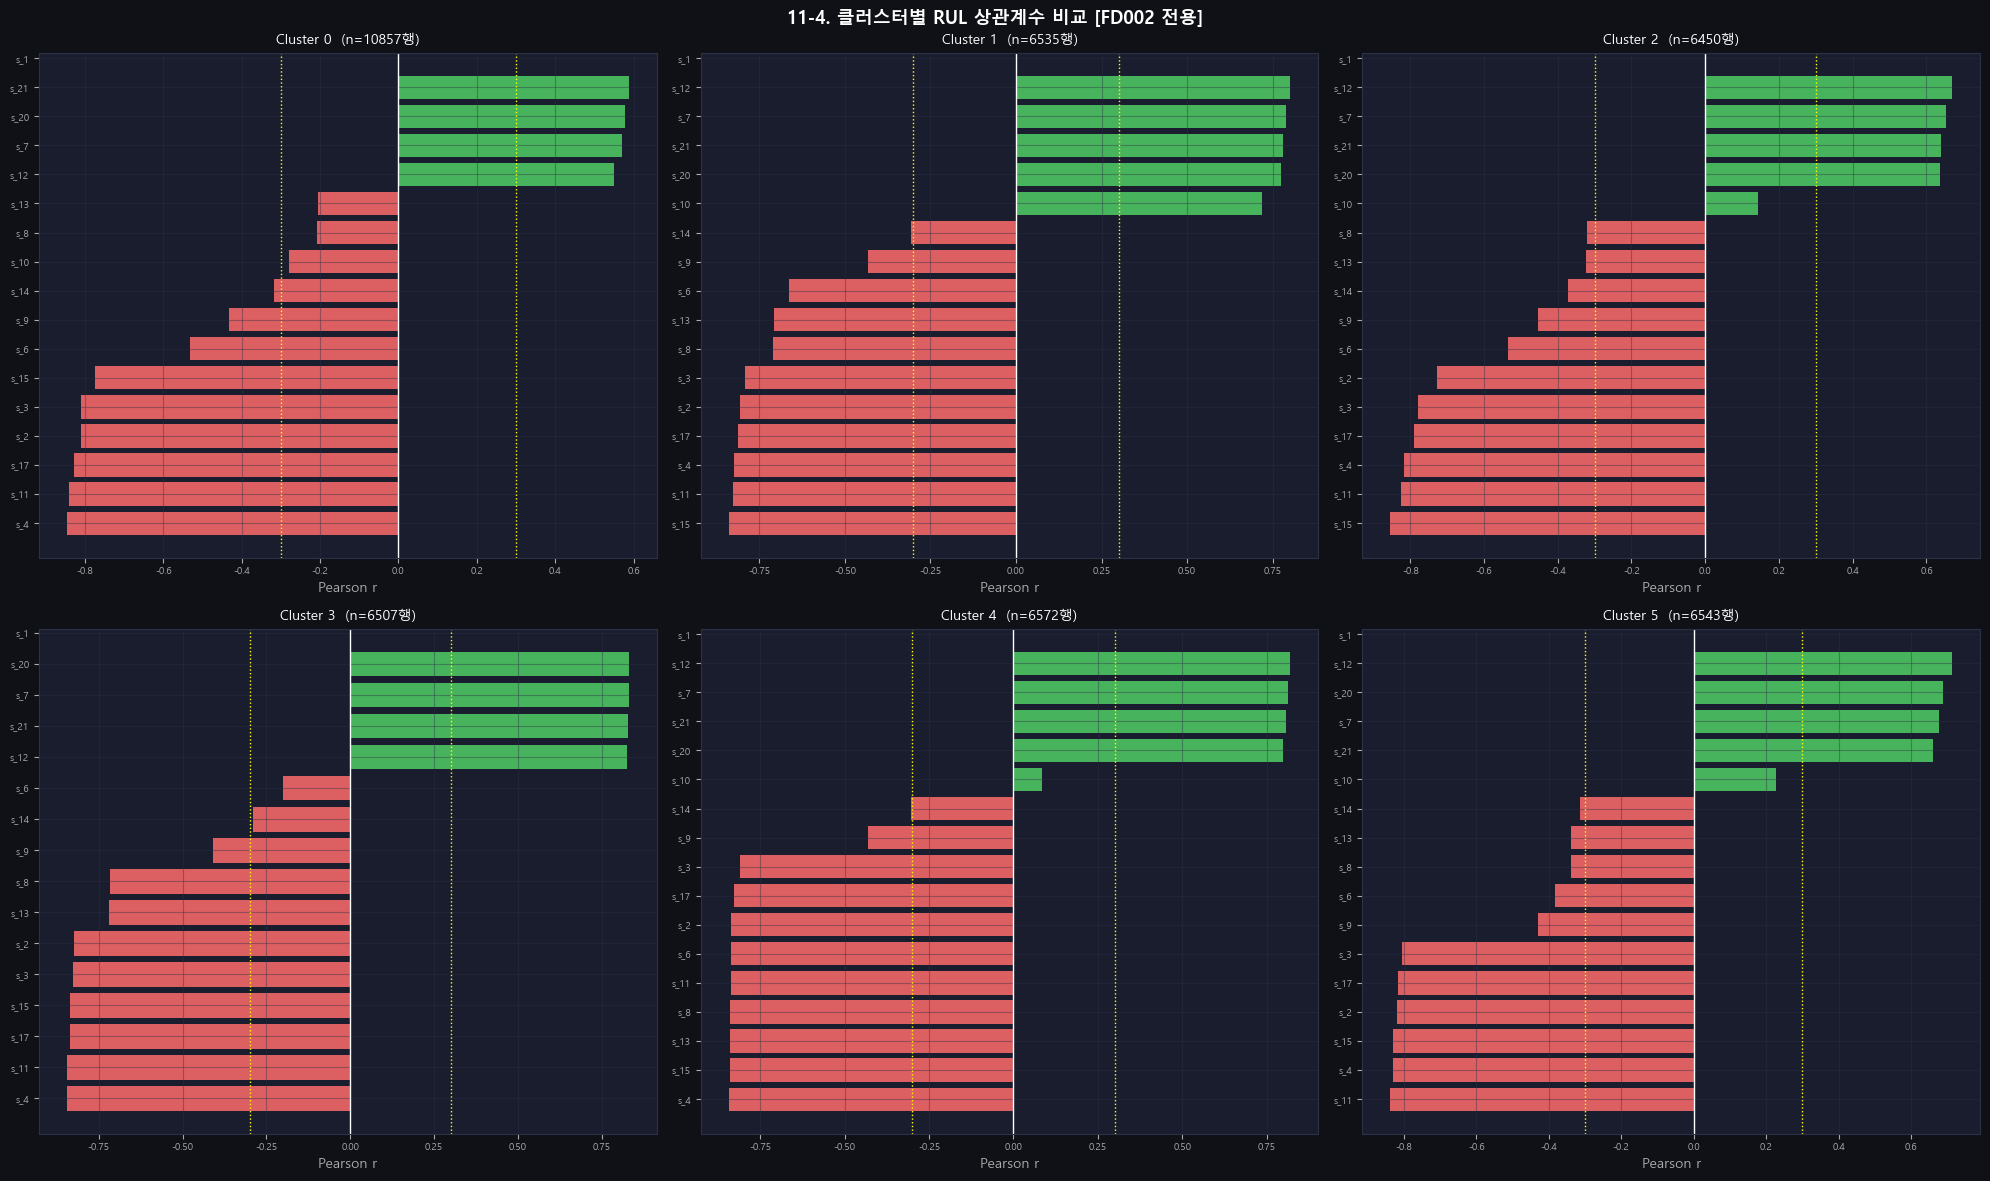


--- 클러스터별 |r|>0.3 고상관 센서 ---
  Cluster 0: ['s_4', 's_11', 's_17', 's_2', 's_3', 's_15', 's_6', 's_9', 's_14', 's_12', 's_7', 's_20', 's_21']
  Cluster 1: ['s_15', 's_11', 's_4', 's_17', 's_2', 's_3', 's_8', 's_13', 's_6', 's_9', 's_14', 's_10', 's_20', 's_21', 's_7', 's_12']
  Cluster 2: ['s_15', 's_11', 's_4', 's_17', 's_3', 's_2', 's_6', 's_9', 's_14', 's_13', 's_8', 's_20', 's_21', 's_7', 's_12']
  Cluster 3: ['s_4', 's_11', 's_17', 's_15', 's_3', 's_2', 's_13', 's_8', 's_9', 's_12', 's_21', 's_7', 's_20']
  Cluster 4: ['s_4', 's_15', 's_13', 's_8', 's_11', 's_6', 's_2', 's_17', 's_3', 's_9', 's_14', 's_20', 's_21', 's_7', 's_12']
  Cluster 5: ['s_11', 's_4', 's_15', 's_2', 's_17', 's_3', 's_9', 's_6', 's_8', 's_13', 's_14', 's_21', 's_7', 's_20', 's_12']


In [34]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('11-4. 클러스터별 RUL 상관계수 비교 [FD002 전용]', fontsize=13, fontweight='bold')

cluster_corr_summary = {}
for ax, c in zip(axes.flat, range(N_CLUSTERS)):
    mask = subtrain_s4['op_cluster'] == c
    sub  = subtrain_s4[mask]
    if 'RUL' not in sub.columns or len(sub) < 10:
        ax.set_visible(False); continue
    corr = sub[USEFUL_SENSORS + ['RUL']].corr()['RUL'][USEFUL_SENSORS].sort_values()
    cluster_corr_summary[c] = corr
    bar_c = [C[1] if v<0 else C[2] for v in corr]
    ax.barh(corr.index, corr.values, color=bar_c, alpha=0.85)
    ax.axvline(0, color='white', lw=1)
    ax.axvline( 0.3, color='yellow', lw=1, ls=':')
    ax.axvline(-0.3, color='yellow', lw=1, ls=':')
    ax.set_title(f'Cluster {c}  (n={mask.sum()}행)', fontsize=10)
    ax.set_xlabel('Pearson r')
    ax.tick_params(labelsize=7)
plt.tight_layout(); plt.show()

print('\n--- 클러스터별 |r|>0.3 고상관 센서 ---')
for c, corr in cluster_corr_summary.items():
    high = corr[corr.abs()>0.3].index.tolist()
    print(f'  Cluster {c}: {high}')

### 11-5. 열화 트렌드 전후 비교 + RUL 상관계수 변화

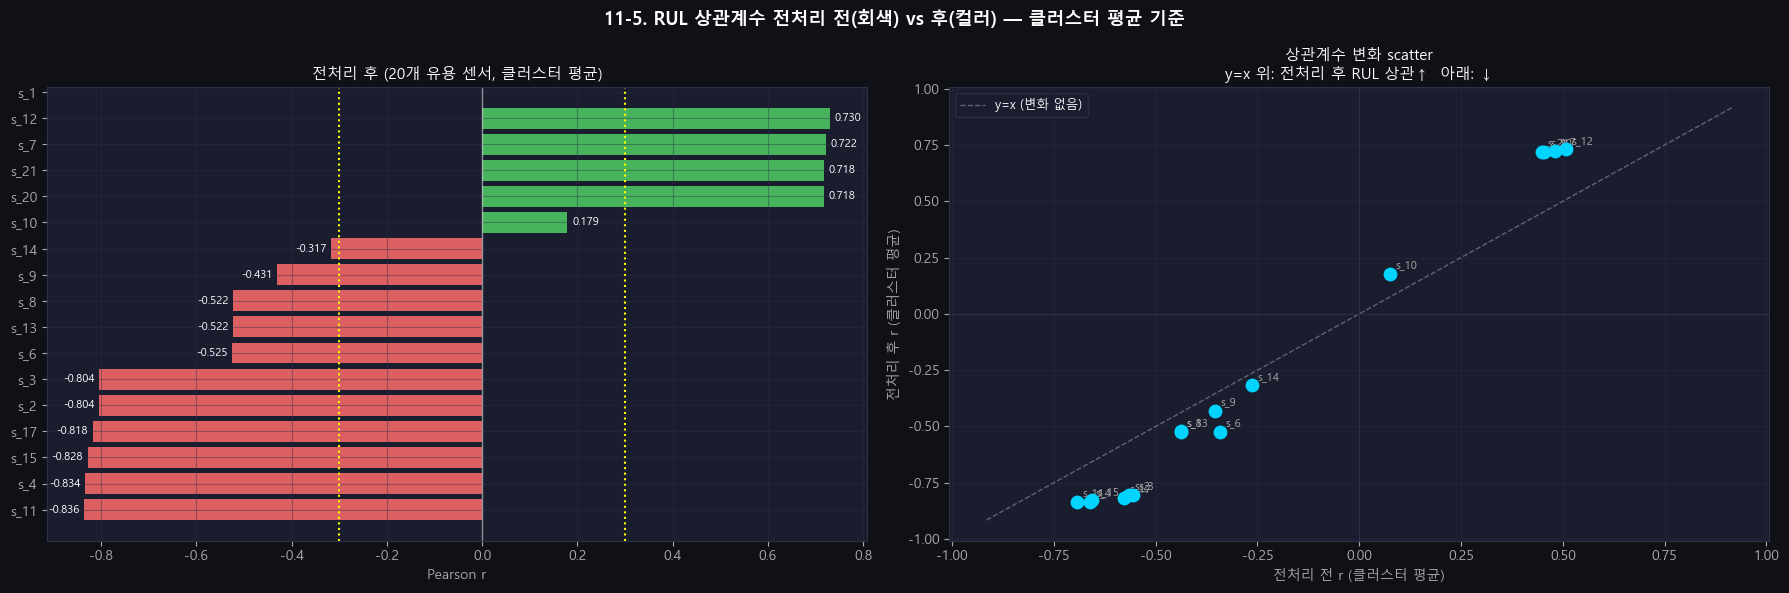


--- RUL 상관계수 전후 변화 요약 (클러스터 평균 기준) ---


,전처리 전 r,전처리 후 r,변화량(Δr),방향
s_21,0.450,0.718,0.268,↑ 개선
s_20,0.455,0.718,0.263,↑ 개선
s_7,0.480,0.722,0.242,↑ 개선
s_12,0.507,0.730,0.223,↑ 개선
s_10,0.075,0.179,0.103,↑ 개선
s_14,-0.263,-0.317,-0.054,↑ 개선
s_9,-0.355,-0.431,-0.076,↑ 개선
s_13,-0.438,-0.522,-0.084,↑ 개선
s_8,-0.437,-0.522,-0.085,↑ 개선
s_11,-0.693,-0.836,-0.142,↑ 개선



상관계수 개선 센서: 16개
상관계수 유지 센서: 4개
상관계수 감소 센서: 0개

📌 전후 모두 클러스터별 r 평균으로 계산 → 조건 혼재 효과 제거된 공정한 비교
📌 감소 센서가 있다면 cluster_dev 피처 추가로 보완 가능


In [35]:
# ── [FD002 수정] 전처리 후도 클러스터별 계산 후 평균으로 비교 ────────────────
# 이유: 전처리 전(rul_corr_before)과 동일한 방식으로 계산해야
#       전후 변화량이 의미 있음

cluster_rul_corrs_after = []
for c in range(N_CLUSTERS):
    mask = subtrain_s4['op_cluster'] == c
    sub  = subtrain_s4[mask]
    if len(sub) > 10 and 'RUL' in sub.columns:
        corr_c = sub[USEFUL_SENSORS + ['RUL']].corr()['RUL'][USEFUL_SENSORS]
        cluster_rul_corrs_after.append(corr_c)

rul_corr_after = pd.concat(cluster_rul_corrs_after, axis=1).mean(axis=1).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('11-5. RUL 상관계수 전처리 전(회색) vs 후(컬러) — 클러스터 평균 기준',
             fontsize=13, fontweight='bold')

# 전처리 후 막대
bc = [C[1] if v < 0 else C[2] for v in rul_corr_after]
bars = axes[0].barh(rul_corr_after.index, rul_corr_after.values, color=bc, alpha=0.85)
axes[0].axvline(0,    color='white', lw=1, alpha=0.5)
axes[0].axvline( 0.3, color='yellow', lw=1.5, ls=':')
axes[0].axvline(-0.3, color='yellow', lw=1.5, ls=':')
axes[0].set_title(f'전처리 후 ({len(USEFUL_SENSORS)}개 유용 센서, 클러스터 평균)')
axes[0].set_xlabel('Pearson r')
for bar, val in zip(bars, rul_corr_after.values):
    axes[0].text(val + (0.01 if val >= 0 else -0.01),
                 bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center',
                 ha='left' if val >= 0 else 'right', fontsize=8)

# 전후 상관계수 변화 scatter
common_s = [s for s in USEFUL_SENSORS if s in rul_corr_before.index]
r_b = rul_corr_before[common_s]
r_a = rul_corr_after[common_s]

axes[1].scatter(r_b, r_a, color=C[0], s=80, zorder=5)
for s in common_s:
    axes[1].annotate(s, (r_b[s], r_a[s]), fontsize=8, color=GRAY,
                     xytext=(4, 4), textcoords='offset points')
lim = max(abs(r_b).max(), abs(r_a).max()) + 0.08
axes[1].plot([-lim, lim], [-lim, lim], color=GRAY, ls='--', lw=1, alpha=0.5,
             label='y=x (변화 없음)')
axes[1].axhline(0, color=GRID, lw=0.8)
axes[1].axvline(0, color=GRID, lw=0.8)
axes[1].set_xlabel('전처리 전 r (클러스터 평균)')
axes[1].set_ylabel('전처리 후 r (클러스터 평균)')
axes[1].set_title('상관계수 변화 scatter\ny=x 위: 전처리 후 RUL 상관↑  아래: ↓')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

# 변화량 요약
change_df = pd.DataFrame({
    '전처리 전 r':  r_b.round(3),
    '전처리 후 r':  r_a.round(3),
    '변화량(Δr)':  (r_a - r_b).round(3),
    '방향': [
        '↑ 개선' if abs(r_a[s]) > abs(r_b[s]) + 0.01
        else '↓ 감소' if abs(r_a[s]) < abs(r_b[s]) - 0.01
        else '→ 유지'
        for s in common_s
    ],
}).sort_values('변화량(Δr)', ascending=False)

print('\n--- RUL 상관계수 전후 변화 요약 (클러스터 평균 기준) ---')
display(change_df)
print(f'\n상관계수 개선 센서: {(change_df["방향"]=="↑ 개선").sum()}개')
print(f'상관계수 유지 센서: {(change_df["방향"]=="→ 유지").sum()}개')
print(f'상관계수 감소 센서: {(change_df["방향"]=="↓ 감소").sum()}개')
print('\n📌 전후 모두 클러스터별 r 평균으로 계산 → 조건 혼재 효과 제거된 공정한 비교')
print('📌 감소 센서가 있다면 cluster_dev 피처 추가로 보완 가능')

### 11-6. ML 파생변수 다중공선성 확인

=== 11-6. ML 파생변수 다중공선성 확인 (sub-train, |r|>0.95) ===
분석 대상: ML_FEATURES 206개
|r|≥0.95 쌍: 174개


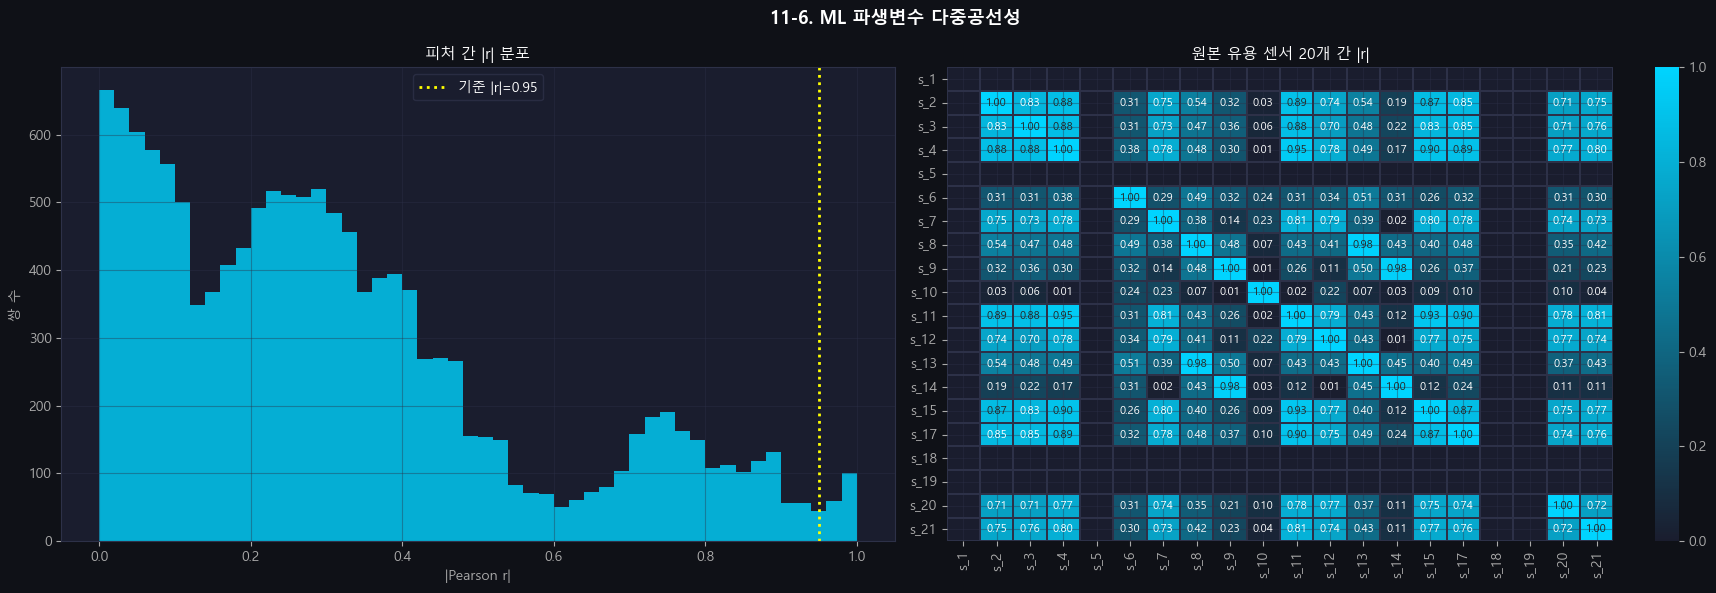


상위 20 고상관 쌍:


,피처A,피처B,|r|
0,s_10_roll5,s_10_ema5,0.999688
1,s_14_roll5,s_14_ema5,0.999678
2,s_13_roll5,s_13_ema5,0.999648
3,s_8_roll5,s_8_ema5,0.999640
4,s_9_roll5,s_9_ema5,0.999610
5,s_11_roll5,s_11_ema5,0.999282
6,s_10_roll3,s_10_ema5,0.999273
7,s_15_roll5,s_15_ema5,0.998953
8,s_4_roll5,s_4_ema5,0.998888
9,s_10_roll3,s_10_roll5,0.998736


In [36]:
print(f'=== 11-6. ML 파생변수 다중공선성 확인 (sub-train, |r|>0.95) ===')
print(f'분석 대상: ML_FEATURES {len(ML_FEATURES)}개')

corr_ml   = subtrain_ml[ML_FEATURES].corr().abs()
upper_ml  = corr_ml.where(np.triu(np.ones(corr_ml.shape), k=1).astype(bool))
HIGH_THR  = 0.95
high_pairs_ml = (upper_ml.stack().reset_index()
                 .rename(columns={'level_0':'피처A','level_1':'피처B',0:'|r|'})
                 .query('`|r|` >= @HIGH_THR')
                 .sort_values('|r|', ascending=False).reset_index(drop=True))

print(f'|r|≥{HIGH_THR} 쌍: {len(high_pairs_ml)}개')

from matplotlib.colors import LinearSegmentedColormap
cmap_mc = LinearSegmentedColormap.from_list('mc', ['#1a1d2e','#00d4ff'], N=256)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle(f'11-6. ML 파생변수 다중공선성', fontsize=13, fontweight='bold')

all_upper_vals = upper_ml.stack().values
axes[0].hist(all_upper_vals, bins=50, color=C[0], alpha=0.8, edgecolor='none')
axes[0].axvline(HIGH_THR, color='yellow', lw=2, ls=':', label=f'기준 |r|={HIGH_THR}')
axes[0].set_title('피처 간 |r| 분포'); axes[0].set_xlabel('|Pearson r|')
axes[0].set_ylabel('쌍 수'); axes[0].legend()

corr_orig = subtrain_ml[USEFUL_SENSORS].corr().abs()
sns.heatmap(corr_orig, ax=axes[1], cmap=cmap_mc, vmin=0, vmax=1,
            annot=True, fmt='.2f', annot_kws={'size': 8},
            linewidths=0.3, linecolor=GRID)
axes[1].set_title(f'원본 유용 센서 {len(USEFUL_SENSORS)}개 간 |r|')
plt.tight_layout(); plt.show()

print(f'\n상위 20 고상관 쌍:')
display(high_pairs_ml.head(20))

---
## 12. CSV 저장 & 최종 요약

In [37]:
OUTPUT_DIR = 'preprocessed_FD002'
os.makedirs(OUTPUT_DIR, exist_ok=True)
dl_dir = os.path.join(OUTPUT_DIR, 'dl')
os.makedirs(dl_dir, exist_ok=True)

# 파일 경로
ml_subtrain_path  = os.path.join(OUTPUT_DIR, 'FD002_ml_subtrain.csv')
ml_valid_path     = os.path.join(OUTPUT_DIR, 'FD002_ml_valid.csv')
ml_test_path      = os.path.join(OUTPUT_DIR, 'FD002_ml_test.csv')
ml_test_eval_path = os.path.join(OUTPUT_DIR, 'FD002_ml_test_eval.csv')
dl_subtrain_path  = os.path.join(dl_dir, 'FD002_dl_subtrain_long.csv')
dl_valid_path     = os.path.join(dl_dir, 'FD002_dl_valid_long.csv')
dl_test_path      = os.path.join(dl_dir, 'FD002_dl_test_long.csv')
rul_path          = os.path.join(OUTPUT_DIR, 'FD002_test_RUL.csv')
scaler_path       = os.path.join(OUTPUT_DIR, 'FD002_scalers_by_cluster.pkl')
ml_feat_path      = os.path.join(OUTPUT_DIR, 'FD002_ml_features.txt')
dl_feat_path      = os.path.join(OUTPUT_DIR, 'FD002_dl_features.txt')
kmeans_path       = os.path.join(OUTPUT_DIR, 'FD002_kmeans.pkl')

# ML CSV 저장
subtrain_ml.to_csv(ml_subtrain_path, index=False)
valid_ml.to_csv(ml_valid_path,       index=False)
test_ml.to_csv(ml_test_path,         index=False)
rul_df.to_csv(rul_path,              index=False)

test_last_ml = (test_ml.sort_values(['unit_nr','time_cycles'])
                .groupby('unit_nr', as_index=False).last().reset_index(drop=True))
test_last_ml['RUL'] = rul_df['RUL'].values
test_last_ml.to_csv(ml_test_eval_path, index=False)

# DL Long Format 저장
dl_subtrain_long.to_csv(dl_subtrain_path, index=False)
dl_valid_long.to_csv(dl_valid_path,       index=False)
dl_test_long.to_csv(dl_test_path,         index=False)

# 모델 파일 저장
joblib.dump(scalers, scaler_path)
joblib.dump(kmeans,  kmeans_path)

with open(ml_feat_path, 'w', encoding='utf-8') as f:
    for col in ['unit_nr','time_cycles','op_cluster'] + ML_FEATURES + ['RUL']: f.write(f'{col}\n')
with open(dl_feat_path, 'w', encoding='utf-8') as f:
    for col in DL_FEATURES: f.write(f'{col}\n')

# 저장 검증
chk_sub = pd.read_csv(dl_subtrain_path)
chk_val = pd.read_csv(dl_valid_path)
chk_te  = pd.read_csv(dl_test_path)

print()
print('=' * 74)
print('  FD002 ML/DL 통합 전처리 파이프라인 완료')
print('=' * 74)
print()
print('■ 공통 파이프라인 (FD002 최적화)')
print('  상수 센서 제거(전체 기준) → 운전조건 클러스터링(KMeans k=6)')
print('  → RUL Cap=125 → 클러스터별 Gaussian(σ=2)')
print('  → 엔진 단위 Validation 분리 → 클러스터별 MinMax 정규화 + OHE')

print()
print('■ ML 분기 — 시계열 파생변수 (엔진×클러스터 단위)')
ml_summary = pd.DataFrame({
    '구분':      ['Sub-train', 'Validation', 'Test(전체)', 'Test(평가용)'],
    'shape':     [str(subtrain_ml.shape), str(valid_ml.shape),
                  str(test_ml.shape),     str(test_last_ml.shape)],
    'ML피처 수': [len(ML_FEATURES)]*4,
    'RUL 범위':  [f'{subtrain_ml["RUL"].min():.0f}~{subtrain_ml["RUL"].max():.0f}',
                  f'{valid_ml["RUL"].min():.0f}~{valid_ml["RUL"].max():.0f}',
                  '별도 RUL csv',
                  f'{test_last_ml["RUL"].min():.0f}~{test_last_ml["RUL"].max():.0f}'],
}).set_index('구분')
display(ml_summary)

print()
print('■ DL 분기 — 슬라이딩 윈도우 Long Format')
dl_summary = pd.DataFrame({
    '구분':       ['Sub-train', 'Validation', 'Test'],
    'shape':      [str(chk_sub.shape), str(chk_val.shape), str(chk_te.shape)],
    '샘플 수':    [X_subtrain_dl.shape[0], X_valid_dl.shape[0], X_test_dl.shape[0]],
    'window_size':[WINDOW_SIZE]*3,
    'DL피처 수':  [len(DL_FEATURES)]*3,
}).set_index('구분')
display(dl_summary)

print()
print('■ 저장 파일 목록')
print(f'   ML  : FD002_ml_subtrain/valid/test/test_eval.csv')
print(f'   DL  : dl/FD002_dl_subtrain/valid/test_long.csv')
print(f'   모델: FD002_kmeans.pkl  FD002_scalers_by_cluster.pkl')
print(f'   분할: FD002_split_units_random42.json')

print()
print('── ML 활용법 ──')
print('  subtrain = pd.read_csv("FD002_ml_subtrain.csv")')
print('  X_train  = subtrain[ML_FEATURES]  →  model.fit(X_train, subtrain["RUL"])')

print()
print('── DL 활용법 (Long Format → 3D 복원) ──')
print('  df  = pd.read_csv("dl/FD002_dl_subtrain_long.csv")')
print('  grp = df.groupby("sample_id")')
print('  X   = np.stack([grp.get_group(i)[DL_FEATURES].values')
print(f'                  for i in range(df["sample_id"].nunique())])  # (N, {WINDOW_SIZE}, {"{len(DL_FEATURES)}"})')
print('  y   = df.groupby("sample_id")["RUL"].last().values')

print()
print('── 새 데이터에 전처리 적용하는 법 ──')
print('  kmeans  = joblib.load("FD002_kmeans.pkl")')
print('  scalers = joblib.load("FD002_scalers_by_cluster.pkl")')
print('  new["op_cluster"] = kmeans.predict(new[OP_COLS])')
print('  for c in range(6):')
print('      mask = new["op_cluster"] == c')
print('      new.loc[mask, USEFUL_SENSORS] = scalers[c].transform(new.loc[mask, USEFUL_SENSORS])')


  FD002 ML/DL 통합 전처리 파이프라인 완료

■ 공통 파이프라인 (FD002 최적화)
  상수 센서 제거(전체 기준) → 운전조건 클러스터링(KMeans k=6)
  → RUL Cap=125 → 클러스터별 Gaussian(σ=2)
  → 엔진 단위 Validation 분리 → 클러스터별 MinMax 정규화 + OHE

■ ML 분기 — 시계열 파생변수 (엔진×클러스터 단위)


,shape,ML피처 수,RUL 범위
구분,,,
Sub-train,"(43464, 210)",206,0~125
Validation,"(10295, 210)",206,0~125
Test(전체),"(33991, 209)",206,별도 RUL csv
Test(평가용),"(259, 210)",206,6~194



■ DL 분기 — 슬라이딩 윈도우 Long Format


,shape,샘플 수,window_size,DL피처 수
구분,,,,
Sub-train,"(1122960, 29)",37432,30,26
Validation,"(263610, 29)",8787,30,26
Test,"(7770, 29)",259,30,26



■ 저장 파일 목록
   ML  : FD002_ml_subtrain/valid/test/test_eval.csv
   DL  : dl/FD002_dl_subtrain/valid/test_long.csv
   모델: FD002_kmeans.pkl  FD002_scalers_by_cluster.pkl
   분할: FD002_split_units_random42.json

── ML 활용법 ──
  subtrain = pd.read_csv("FD002_ml_subtrain.csv")
  X_train  = subtrain[ML_FEATURES]  →  model.fit(X_train, subtrain["RUL"])

── DL 활용법 (Long Format → 3D 복원) ──
  df  = pd.read_csv("dl/FD002_dl_subtrain_long.csv")
  grp = df.groupby("sample_id")
  X   = np.stack([grp.get_group(i)[DL_FEATURES].values
                  for i in range(df["sample_id"].nunique())])  # (N, 30, {len(DL_FEATURES)})
  y   = df.groupby("sample_id")["RUL"].last().values

── 새 데이터에 전처리 적용하는 법 ──
  kmeans  = joblib.load("FD002_kmeans.pkl")
  scalers = joblib.load("FD002_scalers_by_cluster.pkl")
  new["op_cluster"] = kmeans.predict(new[OP_COLS])
  for c in range(6):
      mask = new["op_cluster"] == c
      new.loc[mask, USEFUL_SENSORS] = scalers[c].transform(new.loc[mask, USEFUL_SENSORS])
